# ALL_scores



## Install and clean

In [ ]:
!pip install implicit
!pip install lightfm-next
!pip install catboost

In [ ]:
import json
import pandas as pd
import random
from tqdm import tqdm
from google.colab import drive
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix

SEED = 22
drive.mount('/content/drive')
import numpy as np
pd.options.display.max_rows = 50
pd.options.display.max_columns = 50

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
csv_file_path = '/content/drive/MyDrive/final_yelp_PA_FL.parquet'
df = pd.read_parquet(csv_file_path)
df

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,name,address,city,state,postal_code,latitude,longitude,stars_business,review_count,is_open,attributes,categories,hours,name_user,review_count_user,yelping_since,useful_user,funny_user,cool_user,elite,friends,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos,checkin_count,compliment_count
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Turning Point of North Wales,1460 Bethlehem Pike,North Wales,PA,19454,40.210196,-75.223639,3.0,169,1,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Restaurants, Breakfast & Brunch, Food, Juice B...","{'Friday': '7:30-15:0', 'Monday': '7:30-15:0',...",Melanie,33,2016-01-13 17:20:44,32,3,8,,"DS9QBM_NWJz1E279Zrao-A, XdXgIs4i5JFvtJf0rJlWsA...",0,4.06,0,0,0,0,0,0,0,1,1,0,0,177.0,0.0
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Body Cycle Spinning Studio,"1923 Chestnut St, 2nd Fl",Philadelphia,PA,19119,39.952103,-75.172753,5.0,144,0,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Active Life, Cycling Classes, Trainers, Gyms, ...","{'Friday': '6:0-19:30', 'Monday': '6:30-20:30'...",Erin,10,2011-03-07 19:45:15,6,1,2,,"7uYgWwryg8KH33i1SLJUTQ, 0mGJMNL8o2AY4BT1d4TTDQ...",0,4.30,0,0,0,0,0,0,0,0,0,0,0,497.0,0.0
2,J-4NdnDZ0pUQaUEEwDI9KQ,vrKkXsozqqecF3CW4cGaVQ,rjuWz_AD3WfXJc03AhIO_w,5.0,2,2,2,I thoroughly enjoyed the show. Chill way to s...,2012-12-04 16:46:20,The N Crowd,111 S Independence Mall E,Philadelphia,PA,19106,39.949756,-75.148062,4.5,90,1,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Performing Arts, Arts & Entertainment, Nightli...","{'Friday': '19:15-21:15', 'Monday': '0:0-0:0',...",Mike,120,2010-08-16 19:59:54,48,17,31,,"ZaUT63HFjheiub1y7019Yg, Obkepp5aBTYVX-AL4zwBoQ...",5,4.44,4,3,0,0,0,10,15,4,4,4,0,148.0,0.0
3,DyrAIuKl60j_X8Yrrv-kpg,mNsVyC9tQVYtzLOCbh2Piw,MWmXGQ98KbRo3vsS5nZhMA,5.0,1,0,0,I recently had dinner here with my wife over t...,2014-10-27 02:47:28,Anthony's at Paxon Hollow,850 Paxon Hollow Rd,Broomall,PA,19008,39.958108,-75.371118,3.5,32,1,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Event Planning & Services, Italian, Venues & E...","{'Friday': '12:0-21:0', 'Monday': None, 'Satur...",Michael,12,2014-07-20 22:56:07,43,6,2,,RKULSOrIvvYpDmtuYXEXzA,0,2.53,0,0,0,0,0,0,0,0,0,0,0,15.0,0.0
4,40thYphUgIfvJq17QCfTwA,QzCEzH3R7Z6erOGLr3t55Q,0pMj5xUAecW9o1P35B0AMw,5.0,1,0,1,Great staff always helps and always nice. Alwa...,2017-05-26 13:10:24,Wawa,2544 W Main Street,Norristown,PA,19403,40.141292,-75.389286,3.5,8,1,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Food, Coffee & Tea, Gas Stations, Restaurants,...","{'Friday': '0:0-0:0', 'Monday': '0:0-0:0', 'Sa...",Kylhalil,14,2012-03-05 19:12:11,5,2,2,,"POmz_WtE-nowjX5H7s9NSA, PEYAcshPlYwY-YP-55Re4Q...",0,4.36,0,0,0,0,0,0,0,0,0,0,0,79.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673685,rtt1Ymczj-1Lb26JMsY2lA,M1cMsRL4L7IUr9RILDywEQ,vt_esoDw6HG5ClM12OPkMg,4.0,4,3,4,"5 stars for the Bonte waffle, 3 stars for this...",2009-03-03 20:59:10,Bonté Wafflerie & Café,130 S 17th St,Philadelphia,PA,19102,39.950510,-75.169205,3.5,115,0,"{'AcceptsInsurance': None, 'AgesAllowed': None...","Coffee & Tea, Restaurants, Breakfast & Brunch,...","{'Friday': '6:30-18:0', 'Monday': '6:30-18:0',...",Matt,2227,2006-10-24 22:40:11,5681,1342,2430,"2008,2009,2010,2011,2012,2013,2014,2015,2016,2...","TLElemg3o3mlA4GGpupNiQ, REGjppkq2IkDLRQVmRj_Bg...",277,3.78,59,30,10,13,36,79,116,150,150,128,41,193.0,0.0
673686,5n_oSwXspiiSsZgNwjp48g,bJ5FtCtZX3ZZacz2_2PJjA,SOsjW1JARmtHUFtpFlp8rw,4.0,5,

In [ ]:
if "is_open" not in df.columns:
    raise ValueError("No 'is_open' in df. Merge business meta first or add is_open to parquet.")

before = len(df)
df = df.copy()
df["is_open"] = pd.to_numeric(df["is_open"], errors="coerce").fillna(0).astype(int)
df = df[df["is_open"] == 1].copy()

print(f"is_open=1 filter: {before} -> {len(df)} rows | "
      f"users={df['user_id'].nunique()} | items={df['business_id'].nunique()}")


is_open=1 filter: 673690 -> 539694 rows | users=86675 | items=37899


In [ ]:
import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix

SEED = 42
np.random.seed(SEED)

MIN_USER_INTERACTIONS = 5
MIN_ITEM_INTERACTIONS = 5
K_VAL  = 1
K_TEST = 1
assert MIN_USER_INTERACTIONS >= (K_TEST + K_VAL + 1), "иначе train_inner может стать пустым"

df0 = df.copy()
df0["date"] = pd.to_datetime(df0["date"], errors="coerce")
df0 = (df0
       .dropna(subset=["user_id", "business_id", "date"])
       .sort_values(["user_id", "date"])
)

user_cnt = df0.groupby("user_id")["business_id"].size()
eligible_users = user_cnt[user_cnt >= MIN_USER_INTERACTIONS].index
df_cf = df0[df0["user_id"].isin(eligible_users)].copy()

print("Users after filter:", df_cf["user_id"].nunique())
print("Total interactions:", len(df_cf))


Users after filter: 31794
Total interactions: 382074


In [ ]:
best_cb_vec_params =  {'lowercase': True, 'stop_words': 'english', 'norm': 'l2', 'sublinear_tf': True, 'ngram_range': (1, 1), 'max_df': 1.0, 'max_features': 300000, 'min_df': 5} # сохранить, чтобы дальше не затёрлось
best_itemknn_params = ('tfidf', 10, None, None)  # tuple вида (w, K_sim, K1, B)
best_bpr_params = (128, 0.01, 0.002, 200)  # (f, lr, reg, it)
best_als_params = (128, 0.01, 40, 40.0)  # (f, reg, it, alpha)
best_lfm_cf_params = ('warp', 64, 0.02, 0.0001, 0.0001, 30)  # (loss, c, lr, ia, ua, ep)


## Data split

In [ ]:

test_idx = df_cf.groupby("user_id").tail(K_TEST).index
test0_full  = df_cf.loc[test_idx].copy()
train0_full = df_cf.drop(test_idx).copy()


val_idx = train0_full.groupby("user_id").tail(K_VAL).index
val0_full        = train0_full.loc[val_idx].copy()
train_inner0_full = train0_full.drop(val_idx).copy()

print("train_inner0:", len(train_inner0_full), "val0:", len(val0_full), "test0:", len(test0_full))
print("min interactions per user in train_inner0:",
      int(train_inner0_full.groupby("user_id")["business_id"].size().min()))

train0 = train0_full[["user_id","business_id","date"]].copy()
test0 = test0_full[["user_id","business_id","date"]].copy()
val0 = val0_full[["user_id","business_id","date"]].copy()
train_inner0 = train_inner0_full[["user_id","business_id","date"]].copy()


train_inner0: 318486 val0: 31794 test0: 31794
min interactions per user in train_inner0: 3


In [ ]:
from scipy.sparse import coo_matrix

def build_split_objects_universe(train_df, eval_df, min_item_interactions=5):
    """
    - НЕ дропает cold-start из eval
    - item-space = eligible_items(train) U items(eval)
    - eval_f содержит флаги is_cold_item / is_warm_item_eligible
    """
    train_items_set = set(train_df["business_id"].unique())

    item_cnt = train_df.groupby("business_id")["user_id"].size()
    eligible_items = item_cnt[item_cnt >= min_item_interactions].index
    eligible_set = set(eligible_items)

    train_f = train_df[train_df["business_id"].isin(eligible_items)].copy()

    users = train_f["user_id"].unique()
    user2idx = {u:i for i,u in enumerate(users)}

    idx2biz = pd.Index(eligible_items).union(eval_df["business_id"].unique()).to_numpy()
    is_cold_by_i = np.array([b not in train_items_set for b in idx2biz], dtype=bool)
    n_cold_items = int(is_cold_by_i.sum())

    item2idx = {b:i for i,b in enumerate(idx2biz)}

    train_f["u"] = train_f["user_id"].map(user2idx).astype("int32")
    train_f["i"] = train_f["business_id"].map(item2idx).astype("int32")

    eval_f = eval_df.copy()
    eval_f["u"] = eval_f["user_id"].map(user2idx)
    eval_f["i"] = eval_f["business_id"].map(item2idx)

    before = len(eval_f)
    eval_f = eval_f.dropna(subset=["u","i"]).copy()
    eval_f["u"] = eval_f["u"].astype("int32")
    eval_f["i"] = eval_f["i"].astype("int32")
    dropped_unknown = before - len(eval_f)

    eval_f["is_cold_item"] = ~eval_f["business_id"].isin(train_items_set)
    eval_f["is_warm_item_eligible"] = eval_f["business_id"].isin(eligible_set)

    R = coo_matrix(
        (np.ones(len(train_f), dtype=np.float32),
         (train_f["u"].values, train_f["i"].values)),
        shape=(len(users), len(idx2biz))
    ).tocsr()

    user_train_items = train_f.groupby("u")["i"].apply(lambda x: set(x.tolist())).to_dict()
    all_items = np.arange(len(idx2biz), dtype=np.int32)

    pack = {
        "n_users": len(users),
        "n_items": len(idx2biz),
        "R": R,
        "train_f": train_f,
        "eval_f": eval_f,
        "eval_u": eval_f["u"].values,
        "eval_i": eval_f["i"].values,
        "user_train_items": user_train_items,
        "all_items": all_items,
        "eligible_items": eligible_items,
        "idx2biz": idx2biz,
        "dropped_unknown_eval": dropped_unknown,
        "is_cold_by_i": is_cold_by_i,
        "n_cold_items": n_cold_items,
    }
    return pack

def pack_stats(name, pack):
    ef = pack["eval_f"]
    print(f"{name}: n_users={pack['n_users']} n_items={pack['n_items']} eval={len(ef)} "
          f"| cold={int(ef['is_cold_item'].sum())} warm_eligible={int(ef['is_warm_item_eligible'].sum())} "
          f"| dropped_unknown_eval={pack.get('dropped_unknown_eval',0)}")

val_pack  = build_split_objects_universe(train_inner0, val0, min_item_interactions=MIN_ITEM_INTERACTIONS)
test_pack = build_split_objects_universe(train0,       test0, min_item_interactions=MIN_ITEM_INTERACTIONS)

pack_stats("VAL_CS",  val_pack)
pack_stats("TEST_CS", test_pack)


VAL_CS: n_users=31679 n_items=18765 eval=31679 | cold=1187 warm_eligible=25095 | dropped_unknown_eval=115
TEST_CS: n_users=31744 n_items=19942 eval=31744 | cold=1138 warm_eligible=24653 | dropped_unknown_eval=50


## Text agg

In [ ]:
def agg_item_text(train_full: pd.DataFrame, eligible_items: pd.Index) -> pd.Series:
    x = train_full[train_full["business_id"].isin(eligible_items)][["business_id","text"]].copy()
    x["text"] = x["text"].fillna("").astype(str)
    return x.groupby("business_id")["text"].apply(lambda s: " ".join(t for t in s.values if t))

# - для VAL: только train_inner0_full
# - для TEST: train0_full (train_inner + val)
item_text_val  = agg_item_text(train_inner0_full, val_pack["eligible_items"])
item_text_test = agg_item_text(train0_full,       test_pack["eligible_items"])

print("item_text_val items:",  item_text_val.shape[0])
print("item_text_test items:", item_text_test.shape[0])


item_text_val items: 13235
item_text_test items: 14281


In [ ]:
# Если дальше по ноутбуку у тебя где-то ожидается train_inner0 (как в LMROO пайплайне),
# то теперь в роли "inner-train" можно использовать global train0.
train_inner0 = train0

print(train0.shape, val0.shape, test0.shape)
print(train0["user_id"].nunique(), val0["user_id"].nunique(), test0["user_id"].nunique())


(350280, 3) (31794, 3) (31794, 3)
31794 31794 31794


## Metrics

In [ ]:
import numpy as np

def _ndcg_from_rank(rank: int) -> float:

    return 1.0 / np.log2(rank + 2)

def _ap_from_rank(rank: int) -> float:

    return 1.0 / (rank + 1)

def _extract_items(recs):
    """
    Нормализуем вывод recommend_fn:
    - если вернул np.array/list -> это items
    - если вернул (items, scores) -> берём items
    """
    if recs is None:
        return np.array([], dtype=np.int32)
    if isinstance(recs, tuple) and len(recs) >= 1:
        recs = recs[0]
    return np.asarray(recs, dtype=np.int32)

def evaluate_next_item(eval_u, eval_i, recommend_fn, ks=(5,10,20,50), name="model"):
    """
    Оценка next-item (по одному target на пользователя).
    ВАЖНО: ничего дополнительно из eval не выкидываем (в т.ч. если target item был seen ранее).
    """
    ks = tuple(sorted(ks))
    maxK = ks[-1]
    n = len(eval_u)
    if n == 0:
        print(f"[{name}] empty eval set")
        return {k: (0.0, 0.0, 0.0) for k in ks}

    rec = {k: 0.0 for k in ks}
    ndcg = {k: 0.0 for k in ks}
    mp = {k: 0.0 for k in ks}
    short_lists = 0

    for u, pos in zip(eval_u, eval_i):
        items = _extract_items(recommend_fn(int(u), int(maxK)))

        if len(items) < maxK:
            short_lists += 1


        rpos = None
        for r, it in enumerate(items):
            if int(it) == int(pos):
                rpos = r
                break

        for k in ks:
            if rpos is None or rpos >= k:
                continue
            rec[k] += 1.0
            ndcg[k] += _ndcg_from_rank(rpos)
            mp[k] += _ap_from_rank(rpos)

    out = {k: (rec[k]/n, ndcg[k]/n, mp[k]/n) for k in ks}
    print(f"[{name}] short rec lists: {short_lists}/{n} ({short_lists/n:.3f})")
    return out

import numpy as np

def _get_masks(pack):
    ef = pack["eval_f"]
    return {
        "ALL":  np.ones(len(ef), dtype=bool),
        "WARM": ef["is_warm_item_eligible"].values.astype(bool),
        "COLD": ef["is_cold_item"].values.astype(bool),
    }

def _unique_users(pack, mask):
    ef = pack["eval_f"]
    return np.unique(ef.loc[mask, "u"].values.astype(np.int32))

def catalog_coverage_at_k(pack, recommend_fn, mask, ks=(5,10,20,50)):
    """
    Coverage@K = |union of recommended items| / n_items
    """
    ks = tuple(sorted(ks))
    maxK = ks[-1]
    users = _unique_users(pack, mask)
    n_items = int(pack["n_items"])
    if users.size == 0 or n_items == 0:
        return {k: 0.0 for k in ks}

    unions = {k: set() for k in ks}

    for u in users:
        items = _extract_items(recommend_fn(int(u), int(maxK)))
        items = np.asarray(items, dtype=np.int32)
        for k in ks:
            unions[k].update(items[:k].tolist())

    return {k: (len(unions[k]) / n_items) for k in ks}

def novelty_at_k(pack, recommend_fn, mask, ks=(5,10,20,50), smoothing=1.0):
    """
    Novelty@K = avg_u avg_{i in topK(u)} -log2(p(i)),
    p(i) estimated from train popularity in pack["R"] with smoothing.
    """
    ks = tuple(sorted(ks))
    maxK = ks[-1]
    users = _unique_users(pack, mask)
    if users.size == 0:
        return {k: 0.0 for k in ks}

    pop = np.asarray(pack["R"].sum(axis=0)).ravel().astype(np.float64)
    denom = pop.sum() + smoothing * len(pop)
    p = (pop + smoothing) / denom
    invlogp = -np.log2(p)

    sums = {k: 0.0 for k in ks}
    cnts = {k: 0 for k in ks}

    for u in users:
        items = _extract_items(recommend_fn(int(u), int(maxK)))
        items = np.asarray(items, dtype=np.int32)

        for k in ks:
            topk = items[:k]
            if topk.size == 0:
                continue
            sums[k] += float(invlogp[topk].mean())
            cnts[k] += 1

    return {k: (sums[k] / cnts[k] if cnts[k] > 0 else 0.0) for k in ks}

def cold_share_at_k(pack, recommend_fn, mask, ks=(5,10,20,50)):
    """
    ColdShare@K = avg_u ( #cold in topK(u) / K )
    """
    ks = tuple(sorted(ks))
    maxK = ks[-1]
    users = _unique_users(pack, mask)
    if users.size == 0:
        return {k: 0.0 for k in ks}

    is_cold_by_i = pack["is_cold_by_i"].astype(bool)

    sums = {k: 0.0 for k in ks}
    cnts = {k: 0 for k in ks}

    for u in users:
        items = _extract_items(recommend_fn(int(u), int(maxK)))
        items = np.asarray(items, dtype=np.int32)

        for k in ks:
            topk = items[:k]
            if topk.size == 0:
                continue
            sums[k] += float(is_cold_by_i[topk].mean())
            cnts[k] += 1

    return {k: (sums[k] / cnts[k] if cnts[k] > 0 else 0.0) for k in ks}

def cold_coverage_at_k(pack, recommend_fn, mask, ks=(5,10,20,50)):
    """
    ColdCoverage@K = |union of recommended cold items| / n_cold_items_in_space
    """
    ks = tuple(sorted(ks))
    maxK = ks[-1]
    users = _unique_users(pack, mask)
    n_cold = int(pack.get("n_cold_items", 0))
    if users.size == 0 or n_cold == 0:
        return {k: 0.0 for k in ks}

    is_cold_by_i = pack["is_cold_by_i"].astype(bool)
    unions = {k: set() for k in ks}

    for u in users:
        items = _extract_items(recommend_fn(int(u), int(maxK)))
        items = np.asarray(items, dtype=np.int32)

        cold_items = items[is_cold_by_i[items]]
        for k in ks:
            unions[k].update(cold_items[:k].tolist())

    return {k: (len(unions[k]) / n_cold) for k in ks}

import numpy as np

def _get_masks(pack):
    ef = pack["eval_f"]
    return {
        "ALL":  np.ones(len(ef), dtype=bool),
        "WARM": ef["is_warm_item_eligible"].values.astype(bool),
        "COLD": ef["is_cold_item"].values.astype(bool),
    }

def evaluate_with_aux(pack, recommend_fn, mask, ks=(5,10,20,50), sample_n=None, seed=42):
    """
    За 1 проход по eval-инстансам считает:
      - Recall@K, NDCG@K, MAP@K (next-item, 1 positive на строку)
      - Coverage@K (catalog coverage)
      - Novelty@K (анти-популярность)
      - ColdShare@K (доля cold в топ-K)
      - ColdCoverage@K (покрытие cold-каталога)

    mask: bool-маска по строкам pack["eval_f"]
    sample_n: если задано, берём случайную подвыборку строк (ускорение)
    """
    ef = pack["eval_f"]
    ks = tuple(sorted(ks))
    maxK = ks[-1]

    idx = np.where(mask)[0]
    if idx.size == 0:
        out = {k: (0.0, 0.0, 0.0) for k in ks}
        aux = {
            "Coverage": {k: 0.0 for k in ks},
            "Novelty": {k: 0.0 for k in ks},
            "ColdShare": {k: 0.0 for k in ks},
            "ColdCoverage": {k: 0.0 for k in ks},
        }
        return out, aux

    if (sample_n is not None) and (idx.size > sample_n):
        rng = np.random.default_rng(seed)
        idx = rng.choice(idx, size=int(sample_n), replace=False)


    pop = np.asarray(pack["R"].sum(axis=0)).ravel().astype(np.float64)
    smoothing = 1.0
    denom = pop.sum() + smoothing * len(pop)
    p = (pop + smoothing) / denom
    invlogp = -np.log2(p)

    is_cold_by_i = pack["is_cold_by_i"].astype(bool)
    n_items = int(pack["n_items"])
    n_cold = int(pack.get("n_cold_items", is_cold_by_i.sum()))


    recall_sum = {k: 0.0 for k in ks}
    ndcg_sum   = {k: 0.0 for k in ks}
    map_sum    = {k: 0.0 for k in ks}
    denom_rows = float(idx.size)


    novelty_sum   = {k: 0.0 for k in ks}
    coldshare_sum = {k: 0.0 for k in ks}


    cov_masks     = {k: np.zeros(n_items, dtype=bool) for k in ks}
    coldcov_masks = {k: np.zeros(n_items, dtype=bool) for k in ks}

    for j in idx:
        u = int(ef.iloc[j]["u"])
        true_i = int(ef.iloc[j]["i"])

        rec_items = _extract_items(recommend_fn(u, int(maxK)))
        rec_items = np.asarray(rec_items, dtype=np.int32)
        if rec_items.size == 0:
            continue


        pos = np.where(rec_items == true_i)[0]
        rank = int(pos[0]) if pos.size > 0 else 10**9

        nov_vals  = invlogp[rec_items]
        cold_vals = is_cold_by_i[rec_items].astype(np.float64)

        nov_cum_mean  = np.cumsum(nov_vals)  / np.arange(1, rec_items.size + 1)
        cold_cum_mean = np.cumsum(cold_vals) / np.arange(1, rec_items.size + 1)

        for k in ks:
            kk = min(k, rec_items.size)
            hit = (rank < k)
            if hit:
                recall_sum[k] += 1.0
                ndcg_sum[k]   += 1.0 / np.log2(rank + 2.0)
                map_sum[k]    += 1.0 / (rank + 1.0)

            novelty_sum[k]   += float(nov_cum_mean[kk - 1])
            coldshare_sum[k] += float(cold_cum_mean[kk - 1])

            topk = rec_items[:kk]
            cov_masks[k][topk] = True

            cold_topk = topk[is_cold_by_i[topk]]
            if cold_topk.size > 0:
                coldcov_masks[k][cold_topk] = True

    out = {}
    for k in ks:
        out[k] = (
            recall_sum[k] / denom_rows,
            ndcg_sum[k]   / denom_rows,
            map_sum[k]    / denom_rows
        )

    aux = {
        "Coverage": {},
        "Novelty": {},
        "ColdShare": {},
        "ColdCoverage": {},
    }
    for k in ks:
        aux["Coverage"][k]     = float(cov_masks[k].sum() / n_items) if n_items > 0 else 0.0
        aux["Novelty"][k]      = float(novelty_sum[k] / denom_rows)
        aux["ColdShare"][k]    = float(coldshare_sum[k] / denom_rows)
        aux["ColdCoverage"][k] = float(coldcov_masks[k].sum() / n_cold) if n_cold > 0 else 0.0

    return out, aux


def print_metrics(name, out, ks=(5,10,20,50)):
    print(f"\n=== {name} ===")
    for k in ks:
        r, n, m = out[k]
        print(f"K={k:2d} | Recall@{k}: {r:.4f} | NDCG@{k}: {n:.4f} | MAP@{k}: {m:.4f}")


In [ ]:
import numpy as np

def evaluate_with_aux(pack, recommend_fn, mask, ks=(5,10,20,50), sample_n=None, seed=42):
    """
    За один проход считает:
      - Recall@K, NDCG@K, MAP@K (next-item, 1 позитив на строку)
      - Coverage@K, Novelty@K
      - ColdShare@K, ColdCoverage@K

    mask: булев массив по строкам pack["eval_f"]
    sample_n: если задано, то случайно берём sample_n строк (ускорение)
    """
    ef = pack["eval_f"]
    ks = tuple(sorted(ks))
    maxK = ks[-1]

    idx = np.where(mask)[0]
    if idx.size == 0:
        out = {k: (0.0, 0.0, 0.0) for k in ks}
        aux = { "Coverage": {k: 0.0 for k in ks},
                "Novelty": {k: 0.0 for k in ks},
                "ColdShare": {k: 0.0 for k in ks},
                "ColdCoverage": {k: 0.0 for k in ks} }
        return out, aux

    if (sample_n is not None) and (idx.size > sample_n):
        rng = np.random.default_rng(seed)
        idx = rng.choice(idx, size=int(sample_n), replace=False)


    pop = np.asarray(pack["R"].sum(axis=0)).ravel().astype(np.float64)
    smoothing = 1.0
    denom = pop.sum() + smoothing * len(pop)
    p = (pop + smoothing) / denom
    invlogp = -np.log2(p)  # larger => more novel

    is_cold_by_i = pack["is_cold_by_i"].astype(bool)
    n_items = int(pack["n_items"])
    n_cold = int(pack.get("n_cold_items", is_cold_by_i.sum()))


    recall_sum = {k: 0.0 for k in ks}
    ndcg_sum   = {k: 0.0 for k in ks}
    map_sum    = {k: 0.0 for k in ks}
    denom_rows = float(idx.size)


    novelty_sum   = {k: 0.0 for k in ks}
    coldshare_sum = {k: 0.0 for k in ks}

    cov_masks      = {k: np.zeros(n_items, dtype=bool) for k in ks}
    coldcov_masks  = {k: np.zeros(n_items, dtype=bool) for k in ks}  # marks cold items only

    for j in idx:
        u = int(ef.iloc[j]["u"])
        true_i = int(ef.iloc[j]["i"])

        rec_items = _extract_items(recommend_fn(u, int(maxK)))
        rec_items = np.asarray(rec_items, dtype=np.int32)
        if rec_items.size == 0:
            continue


        pos = np.where(rec_items == true_i)[0]
        rank = int(pos[0]) if pos.size > 0 else 10**9

        nov_vals  = invlogp[rec_items]
        cold_vals = is_cold_by_i[rec_items].astype(np.float64)

        nov_cum_mean  = np.cumsum(nov_vals)  / np.arange(1, rec_items.size + 1)
        cold_cum_mean = np.cumsum(cold_vals) / np.arange(1, rec_items.size + 1)

        for k in ks:
            kk = min(k, rec_items.size)
            # accuracy
            hit = (rank < k)
            if hit:
                recall_sum[k] += 1.0
                ndcg_sum[k]   += 1.0 / np.log2(rank + 2.0)
                map_sum[k]    += 1.0 / (rank + 1.0)

            # aux: novelty/coldshare
            novelty_sum[k]   += float(nov_cum_mean[kk - 1])
            coldshare_sum[k] += float(cold_cum_mean[kk - 1])

            # aux: coverage
            topk = rec_items[:kk]
            cov_masks[k][topk] = True

            # aux: cold coverage
            cold_topk = topk[is_cold_by_i[topk]]
            if cold_topk.size > 0:
                coldcov_masks[k][cold_topk] = True


    out = {}
    for k in ks:
        out[k] = (
            recall_sum[k] / denom_rows,
            ndcg_sum[k]   / denom_rows,
            map_sum[k]    / denom_rows
        )


    aux = {
        "Coverage": {},
        "Novelty": {},
        "ColdShare": {},
        "ColdCoverage": {}
    }
    for k in ks:
        aux["Coverage"][k]     = float(cov_masks[k].sum() / n_items) if n_items > 0 else 0.0
        aux["Novelty"][k]      = float(novelty_sum[k] / denom_rows)
        aux["ColdShare"][k]    = float(coldshare_sum[k] / denom_rows)
        aux["ColdCoverage"][k] = float(coldcov_masks[k].sum() / n_cold) if n_cold > 0 else 0.0

    return out, aux


## Feature engeneering

In [ ]:
# Берём статические поля бизнеса (это не даёт утечки)
need_item_cols = [c for c in ["business_id","categories","attributes","stars_business","review_count","is_open",'text']
                  if c in df_cf.columns]

items_meta = (df_cf[need_item_cols]
              .sort_values(["business_id"])
              .groupby("business_id", as_index=False)
              .first())


In [ ]:
import re, ast

_re_tok = re.compile(r"[^a-z0-9]+", re.IGNORECASE)

def _clean_token(s: str) -> str:
    s = str(s).strip().lower()
    s = s.replace("&", " and ")
    s = _re_tok.sub("_", s).strip("_")
    return s

def _cat_tokens(cat):
    if pd.isna(cat) or cat is None:
        return []
    parts = [p.strip() for p in str(cat).split(",") if p.strip()]
    return [f"cat_{_clean_token(p)}" for p in parts]

def _safe_literal_eval(x):
    if isinstance(x, dict):
        return x
    if pd.isna(x) or x is None:
        return {}
    s = str(x)
    # убираем префиксы u'...' / u"..."
    s = s.replace("u'", "'").replace('u"', '"')
    try:
        return ast.literal_eval(s)
    except Exception:
        return {}

def _norm_scalar(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return None
    if isinstance(v, bool):
        return "true" if v else "false"
    s = str(v).strip()
    s = s.replace("u'", "'").replace('u"', '"')
    # снимем внешние кавычки типа "'loud'"
    if len(s) >= 2 and ((s[0] == s[-1] == "'") or (s[0] == s[-1] == '"')):
        s = s[1:-1].strip()
    return s if s else None

def _attr_tokens(attr):
    d = _safe_literal_eval(attr)
    out = []
    for k, v in (d or {}).items():
        if v is None:
            continue
        key = _clean_token(k)

        # вложенные dict часто лежат строкой -> распарсим ещё раз
        if isinstance(v, str) and v.strip().startswith("{") and v.strip().endswith("}"):
            v2 = _safe_literal_eval(v)
            if isinstance(v2, dict):
                v = v2

        if isinstance(v, dict):
            for kk, vv in v.items():
                vv = _norm_scalar(vv)
                if vv is None:
                    continue
                if str(vv).lower() in ("true", "false"):
                    if str(vv).lower() == "true":
                        out.append(f"attr_{key}_{_clean_token(kk)}")
                else:
                    out.append(f"attr_{key}_{_clean_token(kk)}_{_clean_token(vv)}")
        else:
            vv = _norm_scalar(v)
            if vv is None:
                continue
            if str(vv).lower() in ("true", "false"):
                if str(vv).lower() == "true":
                    out.append(f"attr_{key}")
            else:
                out.append(f"attr_{key}_{_clean_token(vv)}")
    return out

def build_item_docs_for_pack(pack, items_meta, item_text_series):
    """Build per-item documents in *exact* item-index order.

    Critical for cold-start eval: pack["n_items"] includes (eligible_train_items U eval_items).
    Therefore docs must be length == pack["n_items"] and aligned with item index i=0..n_items-1.

    Returns
    -------
    idx2biz : np.ndarray
        business_id for each internal item index i.
    docs : list[str]
        Document string for each item index.
    """
    # Prefer the canonical mapping created in build_split_objects_universe
    if "idx2biz" in pack:
        idx2biz = pack["idx2biz"]
    else:
        # Fallback (should not happen in this notebook)
        idx2biz = (pack["train_f"][["i", "business_id"]]
                   .drop_duplicates("i")
                   .sort_values("i")["business_id"].to_numpy())

    meta = items_meta.set_index("business_id")
    docs = []

    for b in idx2biz:
        row = meta.loc[b] if b in meta.index else None

        cats = _cat_tokens(row["categories"]) if row is not None and "categories" in meta.columns else []
        attrs = _attr_tokens(row["attributes"]) if row is not None and "attributes" in meta.columns else []

        # статические числовые/булевы поля бизнеса -> токены
        extra = []
        if row is not None:
            if "stars_business" in meta.columns and pd.notna(row.get("stars_business", np.nan)):
                sb = int(round(float(row["stars_business"]) * 10))
                extra.append(f"num_starsbiz_{sb}")
            if "review_count" in meta.columns and pd.notna(row.get("review_count", np.nan)):
                rc = int(row["review_count"])
                bin_rc = int(np.clip(np.floor(np.log10(rc + 1) * 10), 0, 50))
                extra.append(f"num_reviewcountbin_{bin_rc}")
            if "is_open" in meta.columns and pd.notna(row.get("is_open", np.nan)):
                extra.append("flag_open" if int(row["is_open"]) == 1 else "flag_closed")

        # тексты отзывов: только из train-пула -> без утечки
        rev = item_text_series.get(b, "")

        docs.append(" ".join(cats + attrs + extra)) # + " " + str(rev)

    # Safety: alignment guarantee
    assert len(docs) == int(pack["n_items"]), f"docs len {len(docs)} != n_items {pack['n_items']}"
    return idx2biz, docs


idx2biz_val,  item_docs_val  = build_item_docs_for_pack(val_pack,  items_meta, item_text_val)
idx2biz_test, item_docs_test = build_item_docs_for_pack(test_pack, items_meta, item_text_test)

print("VAL docs:", len(item_docs_val), "== n_items", val_pack["n_items"])
print("TEST docs:", len(item_docs_test), "== n_items", test_pack["n_items"])


VAL docs: 18765 == n_items 18765
TEST docs: 19942 == n_items 19942


In [ ]:
# Быстрый sanity-check по документам (без риска IndexError)
idx = min(10, len(item_docs_val) - 1)
print("Example idx:", idx)
print(item_docs_val[idx])


Example idx: 10
cat_beauty_and_spas cat_shopping cat_hair_salons cat_barbers attr_bikeparking attr_businessacceptscreditcards attr_businessparking_lot attr_restaurantspricerange2_1 num_starsbiz_35 num_reviewcountbin_11 flag_open


## Matrix TF-IDF

In [ ]:
import numpy as np
from scipy.sparse import diags
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

def train_cb_tfidf(pack, item_docs, vec_params):
    """
    pack: val_pack или test_pack (из build_split_objects)
    item_docs: list[str] длины pack["n_items"] в порядке item index i=0..n_items-1
    vec_params: параметры TfidfVectorizer
    """
    vec = TfidfVectorizer(**vec_params)
    X_items = vec.fit_transform(item_docs).astype(np.float32)  # (n_items, n_terms)


    R = pack["R"].astype(np.float32)  # (n_users, n_items)
    prof = R @ X_items  # (n_users, n_terms)

    cnt = np.asarray(R.getnnz(axis=1)).astype(np.float32)
    cnt[cnt == 0] = 1.0
    prof = diags(1.0 / cnt) @ prof
    prof = normalize(prof, norm="l2", axis=1)

    model = {"vec": vec, "X_items": normalize(X_items, norm="l2", axis=1), "prof": prof}
    return model

import numpy as np

def make_recommender(pack, model, filter_seen=True, maxK=50):
    X_items = model["X_items"]   # sparse (n_items, n_terms), L2-норм
    prof = model["prof"]         # sparse (n_users, n_terms), L2-норм

    user_train_items = pack["user_train_items"]
    cache = {}  # cache[u] = np.int32[top-maxK]  (НЕ scores!)

    def recommend_fn(u: int, K: int):
        u = int(u)
        K = int(K)
        if K <= 0:
            return np.array([], dtype=np.int32)


        if u not in cache:
            # scores длины n_items создаётся временно и НЕ сохраняется
            scores = (prof[u] @ X_items.T).toarray().ravel()

            if filter_seen:
                seen = user_train_items.get(u, None)
                if seen:
                    scores[list(seen)] = -np.inf

            kk = min(int(maxK), scores.shape[0])
            idx = np.argpartition(-scores, kk - 1)[:kk]
            idx = idx[np.argsort(-scores[idx])]
            cache[u] = idx.astype(np.int32)

        idx = cache[u]
        return idx[: min(K, idx.size)]

    return recommend_fn


## Models functions

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from scipy.sparse import identity, hstack
KS = (5, 10, 20, 50, 100)

def evaluate_pack_subsets(pack, recommend_fn, name, ks=KS):
    ef = pack["eval_f"]
    outs = {}

    def run(mask, split):
        u = ef.loc[mask, "u"].values
        i = ef.loc[mask, "i"].values
        print(f"\n[{name}/{split}] n={len(u)}")
        out = evaluate_next_item(u, i, recommend_fn, ks=ks, name=f"{name}/{split}")
        print_metrics(f"{name}/{split}", out, ks=ks)
        return out

    outs["ALL"]  = run(np.ones(len(ef), dtype=bool), "ALL")
    outs["WARM"] = run(ef["is_warm_item_eligible"].values, "WARM")
    outs["COLD"] = run(ef["is_cold_item"].values, "COLD")
    return outs

# ---------- baselines ----------
def make_pop_recommender(pack):
    train_f = pack["train_f"]
    user_train_items = pack["user_train_items"]
    item_pop = train_f.groupby("i")["u"].nunique().sort_values(ascending=False)
    pop_ranked_items = item_pop.index.values.astype(np.int32)
    def recommend(u, K):
        seen = user_train_items.get(int(u), set())
        recs = []
        for it in pop_ranked_items:
            if int(it) not in seen:
                recs.append(int(it))
                if len(recs) == K:
                    break
        return np.asarray(recs, dtype=np.int32)
    return recommend

def make_random_recommender(pack, seed=SEED):
    rng = np.random.default_rng(seed)
    user_train_items = pack["user_train_items"]
    all_items = pack["all_items"]
    n_items = pack["n_items"]
    def recommend(u, K):
        seen = user_train_items.get(int(u), set())
        if len(seen) >= n_items:
            return np.array([], dtype=np.int32)
        candidates = np.setdiff1d(all_items, np.fromiter(seen, dtype=np.int32), assume_unique=False)
        if candidates.size <= K:
            return candidates.astype(np.int32)
        idx = rng.choice(candidates.size, size=K, replace=False)
        return candidates[idx].astype(np.int32)
    return recommend

# ---------- CF models (fit -> recommend_fn) ----------
from implicit.nearest_neighbours import CosineRecommender, tfidf_weight, bm25_weight
from implicit.bpr import BayesianPersonalizedRanking
from implicit.als import AlternatingLeastSquares
from lightfm import LightFM

def fit_itemknn(pack, weighting="bm25", K_sim=100, bm25_K1=1.2, bm25_B=0.75):
    R = pack["R"].tocsr()
    if weighting == "raw":
        Rw = R
    elif weighting == "tfidf":
        Rw = tfidf_weight(R).tocsr()
    elif weighting == "bm25":
        Rw = bm25_weight(R, K1=bm25_K1, B=bm25_B).tocsr()
    else:
        raise ValueError("weighting must be raw/tfidf/bm25")

    model = CosineRecommender(K=K_sim)
    model.fit(Rw.tocsr())

    def recommend(u, K):
        items, _ = model.recommend(userid=int(u), user_items=Rw[int(u)], N=int(K), filter_already_liked_items=True)
        return np.asarray(items, dtype=np.int32)

    return recommend

def fit_bpr(pack, factors=64, learning_rate=0.05, regularization=0.002, iterations=200):
    R = pack["R"].tocsr()
    model = BayesianPersonalizedRanking(
        factors=int(factors),
        learning_rate=float(learning_rate),
        regularization=float(regularization),
        iterations=int(iterations),
        random_state=SEED
    )
    model.fit(R)

    def recommend(u, K):
        items, _ = model.recommend(userid=int(u), user_items=R[int(u)], N=int(K), filter_already_liked_items=True)
        return np.asarray(items, dtype=np.int32)

    return recommend

def fit_als(pack, factors=128, regularization=0.01, iterations=40, alpha=40.0):
    R = pack["R"].tocsr().astype(np.float32)
    R_conf = (R * float(alpha)).tocsr()
    model = AlternatingLeastSquares(
        factors=int(factors),
        regularization=float(regularization),
        iterations=int(iterations),
        random_state=SEED
    )
    model.fit(R_conf)

    def recommend(u, K):
        items, _ = model.recommend(userid=int(u), user_items=R[int(u)], N=int(K), filter_already_liked_items=True)
        return np.asarray(items, dtype=np.int32)

    return recommend

def fit_lightfm_cf(pack, no_components=128, loss="warp", learning_rate=0.05,
                   item_alpha=1e-6, user_alpha=1e-6, epochs=30, num_threads=8):
    R = pack["R"].tocoo()
    model = LightFM(
        no_components=int(no_components),
        loss=loss,
        learning_rate=float(learning_rate),
        item_alpha=float(item_alpha),
        user_alpha=float(user_alpha),
        random_state=SEED
    )
    model.fit(R, epochs=int(epochs), num_threads=int(num_threads), verbose=False)

    user_train_items = pack["user_train_items"]
    all_items = pack["all_items"]
    n_items = pack["n_items"]

    def recommend(u, K):
        seen = user_train_items.get(int(u), set())
        if len(seen) >= n_items:
            return np.array([], dtype=np.int32)
        candidates = np.setdiff1d(all_items, np.fromiter(seen, dtype=np.int32), assume_unique=False)
        if candidates.size == 0:
            return np.array([], dtype=np.int32)
        scores = model.predict(int(u), candidates, num_threads=int(num_threads))
        kk = min(int(K), scores.size)
        topk = np.argpartition(-scores, kk-1)[:kk]
        ranked = candidates[topk][np.argsort(-scores[topk])]
        return ranked.astype(np.int32)

    return recommend

## CB; Hybrid; Fusion

In [ ]:
# ---------- CB TF-IDF (metadata + optional train-only review text) ----------
# берём сохранённые best_cb_vec_params; если не сохранил, используй дефолт
cb_vec_params = globals().get("best_cb_vec_params", {
    "lowercase": True, "stop_words": "english", "norm": "l2", "sublinear_tf": True,
    "ngram_range": (1, 1), "max_df": 1.0, "max_features": 300000, "min_df": 5
})

# IMPORTANT for cold-start:
# categories/attrs tokens can be sparse; too aggressive min_df may wipe most features.
# For cold-start evaluation (where review text is empty for cold items), use softer min_df.
cb_vec_params_cold = dict(cb_vec_params)
cb_vec_params_cold["min_df"] = min(int(cb_vec_params.get("min_df", 5)), 2)

cb_model = train_cb_tfidf(test_pack, item_docs_test, cb_vec_params_cold)
cb_rec = make_recommender(test_pack, cb_model, filter_seen=True)


# ---------- Hybrid LightFM (content features) ----------
# Key fix: item_features must cover ALL items (incl. cold) and should not be dominated by per-item identity.
# We keep identity features but down-weight them; TF-IDF features carry generalizable signal.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from scipy.sparse import identity, hstack
from lightfm import LightFM


def fit_lightfm_hybrid(pack, item_docs, vec_params, no_components=64, loss="warp",
                       learning_rate=0.05, item_alpha=1e-6, user_alpha=1e-6,
                       epochs=30, num_threads=8, identity_weight=0.05):
    vec = TfidfVectorizer(**vec_params)
    X = vec.fit_transform(item_docs).astype(np.float32)
    X = normalize(X, norm="l2", axis=1)

    # identity features help warm items but can hurt cold start if they dominate.
    # down-weight identity part so content features are the main signal.
    if identity_weight is not None and float(identity_weight) > 0:
        I = identity(pack["n_items"], format="csr", dtype=np.float32) * float(identity_weight)
        item_features = hstack([I, X], format="csr")
    else:
        item_features = X.tocsr()

    user_features = identity(pack["n_users"], format="csr", dtype=np.float32)

    R = pack["R"].tocoo()
    model = LightFM(
        no_components=int(no_components),
        loss=loss,
        learning_rate=float(learning_rate),
        item_alpha=float(item_alpha),
        user_alpha=float(user_alpha),
        random_state=SEED
    )
    model.fit(R, user_features=user_features, item_features=item_features,
              epochs=int(epochs), num_threads=int(num_threads), verbose=False)

    user_train_items = pack["user_train_items"]
    all_items = pack["all_items"]
    n_items = pack["n_items"]

    def recommend(u, K):
        seen = user_train_items.get(int(u), set())
        if len(seen) >= n_items:
            return np.array([], dtype=np.int32)
        candidates = np.setdiff1d(all_items, np.fromiter(seen, dtype=np.int32), assume_unique=False)
        if candidates.size == 0:
            return np.array([], dtype=np.int32)
        scores = model.predict(int(u), candidates,
                               user_features=user_features, item_features=item_features,
                               num_threads=int(num_threads))
        kk = min(int(K), scores.size)
        topk = np.argpartition(-scores, kk-1)[:kk]
        ranked = candidates[topk][np.argsort(-scores[topk])]
        return ranked.astype(np.int32)

    parts = {
        "model": model,
        "vec": vec,
        "user_features": user_features,
        "item_features": item_features,
        "recommend": recommend,
    }
    return parts


cb_vec_params_l = globals().get("best_cb_vec_params", {
    "lowercase": True, "stop_words": "english", "norm": "l2", "sublinear_tf": True,
    "ngram_range": (1, 2), "max_df": 1.0, "max_features": 200_000, "min_df": 2
})
cb_vec_params_lfm = dict(cb_vec_params_l)
hyb_parts = fit_lightfm_hybrid(
    test_pack, item_docs_test, cb_vec_params_lfm,
    no_components=64, loss="warp", learning_rate=0.05,
    item_alpha=1e-6, user_alpha=1e-6, epochs=40, num_threads=8,
    identity_weight=0.05
)

hyb_rec = hyb_parts["recommend"]


# ---------- Score-fusion Hybrid (LightFM-hybrid score + CB score) ----------
# This tends to improve cold-start robustness, because CB contributes direct content matching.


def make_score_fusion_recommender(pack, hyb_parts, cb_model, alpha=0.6, num_threads=8, filter_seen=True):
    model = hyb_parts["model"]
    user_features = hyb_parts["user_features"]
    item_features = hyb_parts["item_features"]

    prof = cb_model["prof"]
    X_items = cb_model["X_items"]

    user_train_items = pack["user_train_items"]
    all_items = pack["all_items"]
    n_items = pack["n_items"]

    def _z(x):
        x = x.astype(np.float32)
        m = float(x.mean())
        s = float(x.std())
        return (x - m) / (s + 1e-8)

    def recommend(u, K):
        u = int(u)
        K = int(K)
        if K <= 0:
            return np.array([], dtype=np.int32)

        seen = user_train_items.get(u, set())
        if filter_seen and len(seen) >= n_items:
            return np.array([], dtype=np.int32)

        if filter_seen and seen:
            candidates = np.setdiff1d(all_items, np.fromiter(seen, dtype=np.int32), assume_unique=False)
        else:
            candidates = all_items

        if candidates.size == 0:
            return np.array([], dtype=np.int32)

        # LightFM-hybrid scores
        s_lfm = model.predict(u, candidates,
                              user_features=user_features, item_features=item_features,
                              num_threads=int(num_threads)).astype(np.float32)

        # CB cosine scores (profile vs item vectors) computed only on candidates
        s_cb = (prof[u] @ X_items[candidates].T).toarray().ravel().astype(np.float32)

        # Normalize and fuse
        s = float(alpha) * _z(s_lfm) + (1.0 - float(alpha)) * _z(s_cb)

        kk = min(K, s.size)
        topk = np.argpartition(-s, kk-1)[:kk]
        ranked = candidates[topk][np.argsort(-s[topk])]
        return ranked.astype(np.int32)

    return recommend

hyb_fused_rec = make_score_fusion_recommender(test_pack, hyb_parts, cb_model, alpha=0.6, num_threads=8)


## Fit

In [ ]:
# ======== RUN EVAL (FAST) ========
recommenders = {}
outs = {}
aux = {}
masks = _get_masks(test_pack)

# (опционально) быстрый режим: оценивать на подвыборке строк eval
SAMPLE_N = None   # например 5000 для быстрого прогона; None = полный

# Baselines
recommenders["Popularity"] = make_pop_recommender(test_pack)
recommenders["Random"]     = make_random_recommender(test_pack)

# ItemKNN
w, K_sim, K1, B = best_itemknn_params
knn_rec = fit_itemknn(
    test_pack,
    weighting=w,
    K_sim=int(K_sim),
    bm25_K1=(float(K1) if K1 else 1.2),
    bm25_B=(float(B) if B else 0.75)
)
recommenders["ItemKNN"] = knn_rec

# BPR
f, lr, reg, it = best_bpr_params
bpr_rec = fit_bpr(
    test_pack,
    factors=int(f),
    learning_rate=float(lr),
    regularization=float(reg),
    iterations=int(it)
)
recommenders["BPR"] = bpr_rec

# ALS
f, reg, it, a = best_als_params
als_rec = fit_als(
    test_pack,
    factors=int(f),
    regularization=float(reg),
    iterations=int(it),
    alpha=float(a)
)
recommenders["ALS"] = als_rec

# LightFM CF
loss, c, lr, ia, ua, ep = best_lfm_cf_params
lfm_cf_rec = fit_lightfm_cf(
    test_pack,
    no_components=int(c),
    loss=loss,
    learning_rate=float(lr),
    item_alpha=float(ia),
    user_alpha=float(ua),
    epochs=int(ep),
    num_threads=8
)
recommenders["LightFM(CF)"] = lfm_cf_rec

# CB / Hybrid / Fusion (предполагаем, что вы их уже обучили выше и переменные существуют)
recommenders["CB(TFIDF)"]        = cb_rec
recommenders["LightFM(Hybrid)"]  = hyb_rec
recommenders["Hybrid(Fusion)"]   = hyb_fused_rec

# ======== FAST EVAL: accuracy + aux in ONE PASS ========
for model, rec_fn in recommenders.items():
    outs[model] = {}
    aux[model] = {}
    for split, mask in masks.items():
        out_split, aux_split = evaluate_with_aux(
            test_pack, rec_fn, mask, ks=KS, sample_n=SAMPLE_N, seed=42
        )
        outs[model][split] = out_split
        aux[model][split]  = aux_split


/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.0030736923217773438 seconds
  warnings.warn(


  0%|          | 0/19942 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/40 [00:00<?, ?it/s]

In [ ]:
# ======== SUMMARY TABLE (WITH COVERAGE/NOVELTY/COLD*) ========
pd.set_option('display.max_rows', 200)

def to_rows(split, model, out, aux_for_model_split):
    cov = aux_for_model_split["Coverage"]
    nov = aux_for_model_split["Novelty"]
    csh = aux_for_model_split["ColdShare"]
    ccv = aux_for_model_split["ColdCoverage"]

    return [{
        "split": split,
        "model": model,
        "K": int(k),
        "Recall": float(r),
        "NDCG": float(n),
        "MAP": float(m),
        "Coverage": float(cov[k]),
        "Novelty": float(nov[k]),
        "ColdShare": float(csh[k]),
        "ColdCoverage": float(ccv[k]),
    } for k, (r, n, m) in out.items()]

rows = []
for model, d in outs.items():
    for split in ["ALL", "WARM", "COLD"]:
        rows += to_rows(split, model, d[split], aux[model][split])

res_cs = (
    pd.DataFrame(rows)
      .sort_values(["split", "K", "Recall"], ascending=[True, True, False])
      .reset_index(drop=True)
)

res_cs


,split,model,K,Recall,NDCG,MAP,Coverage,Novelty,ColdShare,ColdCoverage
0,ALL,ALS,5,0.019437,0.011879,0.009427,0.169391,11.534911,0.000000,0.000000
1,ALL,LightFM(CF),5,0.014869,0.009062,0.007183,0.015094,10.014725,0.000000,0.000000
2,ALL,BPR,5,0.010648,0.006446,0.005084,0.263213,12.967369,0.000000,0.000000
3,ALL,LightFM(Hybrid),5,0.006300,0.003955,0.003192,0.537108,12.292205,0.000397,0.034664
4,ALL,Popularity,5,0.005954,0.003768,0.003064,0.000552,9.108951,0.000000,0.000000
5,ALL,Hybrid(Fusion),5,0.005450,0.003461,0.002816,0.579731,12.772761,0.000756,0.070378
6,ALL,ItemKNN,5,0.003560,0.002280,0.001859,0.566794,15.011279,0.000000,0.000000
7,ALL,CB(TFIDF),5,0.002142,0.001437,0.001208,0.550547,13.630944,0.001815,0.177521
8,ALL,Random,5,0.000221,0.000117,0.000085,0.999549,15.545868,0.048009,1.000000
9,ALL,ALS,10,0.034369,0.016650,0.011361,0.220590,11.712346,0.000000,0.000000


In [ ]:
# split	model	K	Recall	NDCG	MAP	Coverage	Novelty	ColdShare	ColdCoverage
# 0	ALL	ALS+CB+CatBoost	5	0.034283	0.022583	0.018756	0.564854	12.271246	0.000680	0.164807
# 1	ALL	ALS+CB+CatBoost	10	0.054061	0.028954	0.021370	0.637941	12.129508	0.000637	0.266094
# 2	ALL	ALS+CB+CatBoost	20	0.082056	0.036002	0.023289	0.723954	12.161037	0.000654	0.416309
# 3	ALL	ALS+CB+CatBoost	50	0.138831	0.047219	0.025071	0.809277	12.293179	0.000522	0.569099
# 4	ALL	ALS+CB+CatBoost	100	0.194721	0.056270	0.025864	0.874951	12.485408	0.000540	0.739914
# 5	COLD	ALS+CB+CatBoost	5	0.000000	0.000000	0.000000	0.111173	12.550417	0.001289	0.008584
# 6	COLD	ALS+CB+CatBoost	10	0.000000	0.000000	0.000000	0.146405	12.380398	0.001418	0.018026
# 7	COLD	ALS+CB+CatBoost	20	0.000644	0.000165	0.000046	0.194102	12.390392	0.001546	0.039485
# 8	COLD	ALS+CB+CatBoost	50	0.000644	0.000165	0.000046	0.273586	12.512285	0.001018	0.060944
# 9	COLD	ALS+CB+CatBoost	100	0.000644	0.000165	0.000046	0.357269	12.696622	0.001121	0.126180
# 10	WARM	ALS+CB+CatBoost	5	0.038532	0.025383	0.021081	0.536544	12.235942	0.000569	0.131330
# 11	WARM	ALS+CB+CatBoost	10	0.060761	0.032542	0.024019	0.606318	12.097766	0.000561	0.224893
# 12	WARM	ALS+CB+CatBoost	20	0.092210	0.040460	0.026175	0.688689	12.131628	0.000585	0.357940
# 13	WARM	ALS+CB+CatBoost	50	0.156007	0.053064	0.028177	0.777883	12.265773	0.000480	0.515880
# 14	WARM	ALS+CB+CatBoost	100	0.218824	0.063237	0.029068	0.852382	12.459460	0.000488	0.696996


In [ ]:
# # ======== RUN EVAL (TEST_CS) ========
# recommenders = {}
# outs = {}
# aux = {}
# masks = _get_masks(test_pack)


# # Baselines
# recommenders["Popularity"] = make_pop_recommender(test_pack)
# outs["Popularity"] = evaluate_pack_subsets(test_pack, recommenders["Popularity"], "Popularity")

# recommenders["Random"] = make_random_recommender(test_pack)
# outs["Random"] = evaluate_pack_subsets(test_pack, recommenders["Random"], "Random")

# # ItemKNN best params
# w, K_sim, K1, B = best_itemknn_params
# knn_rec = fit_itemknn(test_pack, weighting=w, K_sim=K_sim, bm25_K1=(K1 if K1 else 1.2), bm25_B=(B if B else 0.75))
# recommenders["ItemKNN"] = knn_rec
# outs["ItemKNN"] = evaluate_pack_subsets(test_pack, knn_rec, "ItemKNN")

# # BPR best
# f, lr, reg, it = best_bpr_params
# bpr_rec = fit_bpr(test_pack, factors=f, learning_rate=lr, regularization=reg, iterations=it)
# recommenders["BPR"] = bpr_rec
# outs["BPR"] = evaluate_pack_subsets(test_pack, bpr_rec, "BPR")

# # ALS best
# f, reg, it, a = best_als_params
# als_rec = fit_als(test_pack, factors=f, regularization=reg, iterations=it, alpha=a)
# recommenders["ALS"] = als_rec
# outs["ALS"] = evaluate_pack_subsets(test_pack, als_rec, "ALS")

# # LightFM CF best
# loss, c, lr, ia, ua, ep = best_lfm_cf_params
# lfm_cf_rec = fit_lightfm_cf(
#     test_pack, no_components=c, loss=loss, learning_rate=lr,
#     item_alpha=ia, user_alpha=ua, epochs=ep, num_threads=8
# )
# recommenders["LightFM(CF)"] = lfm_cf_rec
# outs["LightFM(CF)"] = evaluate_pack_subsets(test_pack, lfm_cf_rec, "LightFM(CF)")

# # CB + Hybrid (у вас они уже обучены выше и лежат в cb_rec / hyb_rec / hyb_fused_rec)
# recommenders["CB(TFIDF)"] = cb_rec
# outs["CB(TFIDF)"] = evaluate_pack_subsets(test_pack, cb_rec, "CB(TFIDF)")

# recommenders["LightFM(Hybrid)"] = hyb_rec
# outs["LightFM(Hybrid)"] = evaluate_pack_subsets(test_pack, hyb_rec, "LightFM(Hybrid)")

# recommenders["Hybrid(Fusion)"] = hyb_fused_rec
# outs["Hybrid(Fusion)"] = evaluate_pack_subsets(test_pack, hyb_fused_rec, "Hybrid(Fusion)")

# # ======== AUX METRICS (Coverage / Novelty / ColdShare / ColdCoverage) ========
# aux = {}  # aux[model][split] -> dict with metric dicts by K

# for model, rec_fn in recommenders.items():
#     aux[model] = {}
#     for split, mask in masks.items():
#         aux[model][split] = {
#             "Coverage":     catalog_coverage_at_k(test_pack, rec_fn, mask, ks=KS),
#             "Novelty":      novelty_at_k(test_pack, rec_fn, mask, ks=KS),
#             "ColdShare":    cold_share_at_k(test_pack, rec_fn, mask, ks=KS),
#             "ColdCoverage": cold_coverage_at_k(test_pack, rec_fn, mask, ks=KS),
#         }


## Metrics

In [ ]:
# ======== SUMMARY TABLE ========
pd.set_option('display.max_rows', 200)
import pandas as pd

def to_rows(split, model, out, aux_for_model_split):
    cov = aux_for_model_split["Coverage"]
    nov = aux_for_model_split["Novelty"]
    csh = aux_for_model_split["ColdShare"]
    ccv = aux_for_model_split["ColdCoverage"]

    return [{
        "split": split,
        "model": model,
        "K": int(k),
        "Recall": float(r),
        "NDCG": float(n),
        "MAP": float(m),
        "Coverage": float(cov[k]),
        "Novelty": float(nov[k]),
        "ColdShare": float(csh[k]),
        "ColdCoverage": float(ccv[k]),
    } for k, (r, n, m) in out.items()]

rows = []
for model, d in outs.items():
    for split in ["ALL", "WARM", "COLD"]:
        rows += to_rows(split, model, d[split], aux[model][split])

res_cs = (
    pd.DataFrame(rows)
      .sort_values(["split", "K", "Recall"], ascending=[True, True, False])
      .reset_index(drop=True)
)

res_cs


,split,model,K,Recall,NDCG,MAP,Coverage,Novelty,ColdShare,ColdCoverage
0,ALL,ALS,5,0.019437,0.011879,0.009427,0.169391,11.534911,0.000000,0.000000
1,ALL,LightFM(CF),5,0.014869,0.009062,0.007183,0.015094,10.014725,0.000000,0.000000
2,ALL,BPR,5,0.010648,0.006446,0.005084,0.263213,12.967369,0.000000,0.000000
3,ALL,LightFM(Hybrid),5,0.006300,0.003955,0.003192,0.537108,12.292205,0.000397,0.034664
4,ALL,Popularity,5,0.005954,0.003768,0.003064,0.000552,9.108951,0.000000,0.000000
5,ALL,Hybrid(Fusion),5,0.005450,0.003461,0.002816,0.579731,12.772761,0.000756,0.070378
6,ALL,ItemKNN,5,0.003560,0.002280,0.001859,0.566794,15.011279,0.000000,0.000000
7,ALL,CB(TFIDF),5,0.002142,0.001437,0.001208,0.550547,13.630944,0.001815,0.177521
8,ALL,Random,5,0.000221,0.000117,0.000085,0.999549,15.545868,0.048009,1.000000
9,ALL,ALS,10,0.034369,0.016650,0.011361,0.220590,11.712346,0.000000,0.000000


In [ ]:
#

# 2 stage rank

In [ ]:
import numpy as np
import pandas as pd

SEED = 42
rng = np.random.default_rng(SEED)

# Candidate sizes
M_ALS = 500
M_CB  = 1200

# Neg sampling per query (for ranker training)
N_NEG = 50

# Сколько warm-queries брать для обучения ранкера (cold берём все)
N_WARM_QUERIES = 15000

# Размер SVD-эмбеддинга item-фич (CB item features -> dense dims for CatBoost)
SVD_DIM = 32

# Какая метрика на VAL является целевой при подборе (обычно COLD Recall@50/100)
TARGET_K = 50
TARGET_SPLIT = "COLD"  # "COLD" / "ALL" / "WARM"

# Сколько запросов использовать для быстрой оценки в тюнинге (ускорение)
EVAL_SAMPLE_N = 20000  # None = полный прогон (медленно)


In [ ]:
from implicit.als import AlternatingLeastSquares

def fit_als_model(pack, factors, regularization, iterations, alpha, seed=42):
    R = pack["R"].tocsr().astype(np.float32)
    R_conf = (R * float(alpha)).tocsr()

    als = AlternatingLeastSquares(
        factors=int(factors),
        regularization=float(regularization),
        iterations=int(iterations),
        random_state=int(seed),
    )
    als.fit(R_conf)
    return als, R

def als_topM(als, R, u, M):
    items, scores = als.recommend(
        userid=int(u),
        user_items=R[int(u)],
        N=int(M),
        filter_already_liked_items=True,
        recalculate_user=False,
    )
    return np.asarray(items, dtype=np.int32), np.asarray(scores, dtype=np.float64)

def als_score_items(als, u, items):
    uf = als.user_factors[int(u)]      # (f,)
    itf = als.item_factors[items]      # (n,f)
    return (itf @ uf).astype(np.float64)

# VAL / TEST ALS
f, reg, it, a = best_als_params
als_val,  R_val  = fit_als_model(val_pack,  f, reg, it, a, seed=SEED)
als_test, R_test = fit_als_model(test_pack, f, reg, it, a, seed=SEED)


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from scipy import sparse

def _l2_normalize_rows(X):
    norms = np.sqrt(X.multiply(X).sum(axis=1)).A1
    norms[norms == 0] = 1.0
    inv = 1.0 / norms
    return sparse.diags(inv).dot(X)

def build_cb_and_svd(pack, item_docs, vec_params, svd_dim=32, seed=42):
    vec = TfidfVectorizer(**vec_params)
    X_items = vec.fit_transform(item_docs).tocsr()
    X_items = _l2_normalize_rows(X_items)

    # user профили как в CB: U = R * X_items
    R = pack["R"].tocsr().astype(np.float32)
    U = (R @ X_items).tocsr()
    U = _l2_normalize_rows(U)

    # SVD по item-матрице (dense item embeddings)
    svd = TruncatedSVD(n_components=int(svd_dim), random_state=int(seed))
    item_emb = svd.fit_transform(X_items).astype(np.float32)  # (n_items, d)


    user_emb = svd.transform(U).astype(np.float32)           # (n_users, d)

    return vec, X_items, U, svd, item_emb, user_emb

def cb_score_items(U, X_items, u, items):
    v = U[int(u)]
    Xsub = X_items[items]
    return (v @ Xsub.T).toarray().ravel().astype(np.float64)

def cb_topM(U, X_items, u, M):
    v = U[int(u)]
    scores = (v @ X_items.T).toarray().ravel()
    if M >= scores.size:
        idx = np.argsort(-scores)
    else:
        idx_part = np.argpartition(-scores, M)[:M]
        idx = idx_part[np.argsort(-scores[idx_part])]
    return idx.astype(np.int32), scores[idx].astype(np.float64)


vec_params = dict(best_cb_vec_params)
vec_params["min_df"] = 2  # или 1

# VAL artifacts
vec_val, X_items_val, U_val, svd_val, item_emb_val, user_emb_val = build_cb_and_svd(
    val_pack, item_docs_val, vec_params, svd_dim=SVD_DIM, seed=SEED
)

# TEST artifacts
vec_test, X_items_test, U_test, svd_test, item_emb_test, user_emb_test = build_cb_and_svd(
    test_pack, item_docs_test, vec_params, svd_dim=SVD_DIM, seed=SEED
)


In [ ]:
from catboost import CatBoostRanker, Pool

def build_ranker_dataset(
    pack, als, R, X_items, U,
    item_emb, user_emb,
    M_als=500, M_cb=1200, n_neg=50,
    n_warm_queries=15000,
    seed=42
):
    ef = pack["eval_f"].reset_index(drop=True)
    rng = np.random.default_rng(seed)

    cold_idx = ef.index[ef["is_cold_item"] == 1].to_numpy()
    warm_idx = ef.index[ef["is_cold_item"] == 0].to_numpy()
    if warm_idx.size > n_warm_queries:
        warm_idx = rng.choice(warm_idx, size=int(n_warm_queries), replace=False)

    use_idx = np.concatenate([cold_idx, warm_idx])
    rng.shuffle(use_idx)

    is_cold_by_i = pack["is_cold_by_i"].astype(bool)
    pop = np.asarray(pack["R"].sum(axis=0)).ravel().astype(np.float64)
    log_pop = np.log1p(pop).astype(np.float32)

    X_rows, y_rows, gid_rows, w_rows = [], [], [], []

    for q, j in enumerate(use_idx):
        u = int(ef.loc[j, "u"])
        true_i = int(ef.loc[j, "i"])
        is_cold_query = int(ef.loc[j, "is_cold_item"]) == 1

        a_items, _ = als_topM(als, R, u, M_als)
        c_items, _ = cb_topM(U, X_items, u, M_cb)

        cand = np.unique(np.concatenate([a_items, c_items, np.array([true_i], dtype=np.int32)]))

        a_rank = {int(i): r for r, i in enumerate(a_items.tolist())}
        c_rank = {int(i): r for r, i in enumerate(c_items.tolist())}

        neg_pool = cand[cand != true_i]
        if neg_pool.size == 0:
            continue
        if neg_pool.size > n_neg:
            neg = rng.choice(neg_pool, size=int(n_neg), replace=False)
        else:
            neg = neg_pool

        items = np.concatenate([np.array([true_i], dtype=np.int32), neg])

        # Base scores
        als_s = als_score_items(als, u, items).astype(np.float32)
        cb_s  = cb_score_items(U, X_items, u, items).astype(np.float32)

        # Ranks
        als_r = np.array([a_rank.get(int(i), 10**6) for i in items], dtype=np.float32)
        cb_r  = np.array([c_rank.get(int(i), 10**6) for i in items], dtype=np.float32)

        # Item stats
        cold_item = is_cold_by_i[items].astype(np.float32)
        lp = log_pop[items].astype(np.float32)

        # CB item features (dense SVD embedding)
        it_emb = item_emb[items]                 # (n, d)
        u_emb  = np.repeat(user_emb[u][None, :], repeats=items.size, axis=0)  # (n, d)


        feats = np.concatenate(
            [
                als_s[:, None],
                cb_s[:, None],
                als_r[:, None],
                cb_r[:, None],
                cold_item[:, None],
                lp[:, None],
                it_emb,
                u_emb,
            ],
            axis=1
        ).astype(np.float32)

        labels = np.zeros(items.size, dtype=np.float32)
        labels[0] = 1.0

        X_rows.append(feats)
        y_rows.append(labels)
        gid_rows.append(np.full(items.size, q, dtype=np.int32))


        w = 3.0 if is_cold_query else 1.0
        w_rows.append(np.full(items.size, w, dtype=np.float32))

    X = np.vstack(X_rows)
    y = np.concatenate(y_rows)
    gid = np.concatenate(gid_rows)
    w = np.concatenate(w_rows)
    return X, y, gid, w

X_all, y_all, gid_all, w_all = build_ranker_dataset(
    val_pack, als_val, R_val, X_items_val, U_val,
    item_emb_val, user_emb_val,
    M_als=M_ALS, M_cb=M_CB, n_neg=N_NEG,
    n_warm_queries=N_WARM_QUERIES,
    seed=SEED
)


n_groups = int(gid_all.max() + 1)
perm = rng.permutation(n_groups)
cut = int(0.8 * n_groups)
train_groups = set(perm[:cut].tolist())

train_mask = np.array([g in train_groups for g in gid_all], dtype=bool)

X_tr, y_tr, gid_tr, w_tr = X_all[train_mask], y_all[train_mask], gid_all[train_mask], w_all[train_mask]
X_va, y_va, gid_va, w_va = X_all[~train_mask], y_all[~train_mask], gid_all[~train_mask], w_all[~train_mask]

train_pool = Pool(X_tr, y_tr, group_id=gid_tr, weight=w_tr)
valid_pool = Pool(X_va, y_va, group_id=gid_va, weight=w_va)

print("Ranker train pairs:", X_tr.shape, "valid pairs:", X_va.shape)


Ranker train pairs: (660399, 70) valid pairs: (165138, 70)


In [ ]:
def make_catboost_rerank_recommender(
    pack, als, R, X_items, U,
    item_emb, user_emb,
    ranker,
    M_als=500, M_cb=1200
):
    is_cold_by_i = pack["is_cold_by_i"].astype(bool)
    pop = np.asarray(pack["R"].sum(axis=0)).ravel().astype(np.float64)
    log_pop = np.log1p(pop).astype(np.float32)

    def rec(u, K):
        a_items, _ = als_topM(als, R, u, M_als)
        c_items, _ = cb_topM(U, X_items, u, M_cb)
        cand = np.unique(np.concatenate([a_items, c_items]))
        if cand.size == 0:
            return np.array([], dtype=np.int32), np.array([], dtype=np.float64)

        a_rank = {int(i): r for r, i in enumerate(a_items.tolist())}
        c_rank = {int(i): r for r, i in enumerate(c_items.tolist())}

        als_s = als_score_items(als, u, cand).astype(np.float32)
        cb_s  = cb_score_items(U, X_items, u, cand).astype(np.float32)

        als_r = np.array([a_rank.get(int(i), 10**6) for i in cand], dtype=np.float32)
        cb_r  = np.array([c_rank.get(int(i), 10**6) for i in cand], dtype=np.float32)

        cold_item = is_cold_by_i[cand].astype(np.float32)
        lp = log_pop[cand].astype(np.float32)

        it_emb = item_emb[cand]
        u_emb  = np.repeat(user_emb[int(u)][None, :], repeats=cand.size, axis=0)

        feats = np.concatenate(
            [
                als_s[:, None],
                cb_s[:, None],
                als_r[:, None],
                cb_r[:, None],
                cold_item[:, None],
                lp[:, None],
                it_emb,
                u_emb,
            ],
            axis=1
        ).astype(np.float32)

        scores = ranker.predict(feats).astype(np.float64)
        order = np.argsort(-scores)
        top = cand[order[:K]]
        return top.astype(np.int32), scores[order[:K]]

    return rec

def score_on_val(pack, rec_fn, split, target_k, ks, sample_n=None):
    masks = _get_masks(pack)
    mask = masks[split]
    out, aux = evaluate_with_aux(pack, rec_fn, mask, ks=ks, sample_n=sample_n, seed=SEED)
    r = out[target_k][0]
    return float(r), out, aux

# небольшой grid (расширяйте при необходимости)
grid = []
for depth in [6, 8]:
    for lr in [0.05, 0.08]:
        for l2 in [3.0, 8.0]:
            for iters in [1200]:
                grid.append({"depth": depth, "learning_rate": lr, "l2_leaf_reg": l2, "iterations": iters})

results = []
best = {"score": -1, "params": None, "model": None, "best_iteration": None}

for params in grid:
    ranker = CatBoostRanker(
        loss_function="YetiRank",
        iterations=int(params["iterations"]),
        depth=int(params["depth"]),
        learning_rate=float(params["learning_rate"]),
        l2_leaf_reg=float(params["l2_leaf_reg"]),
        random_seed=SEED,
        verbose=False,
        # ранняя остановка по валид-пулу
        od_type="Iter",
        od_wait=80
    )
    ranker.fit(train_pool, eval_set=valid_pool, use_best_model=True)

    rec_val = make_catboost_rerank_recommender(
        val_pack, als_val, R_val, X_items_val, U_val,
        item_emb_val, user_emb_val,
        ranker, M_als=M_ALS, M_cb=M_CB
    )

    score, _, _ = score_on_val(val_pack, rec_val, TARGET_SPLIT, TARGET_K, ks=KS, sample_n=EVAL_SAMPLE_N)

    row = dict(params)
    row["target_split"] = TARGET_SPLIT
    row["target_k"] = TARGET_K
    row["Recall_target"] = score
    row["best_iteration"] = int(ranker.get_best_iteration() or params["iterations"])
    results.append(row)

    if score > best["score"]:
        best["score"] = score
        best["params"] = params
        best["model"] = ranker
        best["best_iteration"] = row["best_iteration"]

pd.DataFrame(results).sort_values("Recall_target", ascending=False).reset_index(drop=True).head(10), best


Pairwise losses don't support object weights.
Pairwise losses don't support object weights.
Pairwise losses don't support object weights.
Pairwise losses don't support object weights.
Pairwise losses don't support object weights.
Pairwise losses don't support object weights.
Pairwise losses don't support object weights.
Pairwise losses don't support object weights.
Pairwise losses don't support object weights.
Pairwise losses don't support object weights.
Pairwise losses don't support object weights.
Pairwise losses don't support object weights.
Pairwise losses don't support object weights.
Pairwise losses don't support object weights.
Pairwise losses don't support object weights.
Pairwise losses don't support object weights.


(   depth  learning_rate  l2_leaf_reg  iterations target_split  target_k  \
 0      6           0.05          3.0        1200         COLD        50   
 1      6           0.05          8.0        1200         COLD        50   
 2      6           0.08          3.0        1200         COLD        50   
 3      6           0.08          8.0        1200         COLD        50   
 4      8           0.05          3.0        1200         COLD        50   
 5      8           0.05          8.0        1200         COLD        50   
 6      8           0.08          3.0        1200         COLD        50   
 7      8           0.08          8.0        1200         COLD        50   
 
    Recall_target  best_iteration  
 0            0.0             742  
 1            0.0             663  
 2            0.0             489  
 3            0.0             645  
 4            0.0             613  
 5            0.0             555  
 6            0.0             505  
 7            0.0         

In [ ]:
best_params = best["params"]
best_iters  = int(best["best_iteration"])

full_pool = Pool(X_all, y_all, group_id=gid_all, weight=w_all)

ranker_final = CatBoostRanker(
    loss_function="YetiRank",
    iterations=best_iters,
    depth=int(best_params["depth"]),
    learning_rate=float(best_params["learning_rate"]),
    l2_leaf_reg=float(best_params["l2_leaf_reg"]),
    random_seed=SEED,
    verbose=200
)
ranker_final.fit(full_pool)

rec_val_final = make_catboost_rerank_recommender(
    val_pack, als_val, R_val, X_items_val, U_val,
    item_emb_val, user_emb_val,
    ranker_final, M_als=M_ALS, M_cb=M_CB
)

# Единый протокол метрик (ALL/WARM/COLD) на VAL
masks_val = _get_masks(val_pack)
rows = []
for split, mask in masks_val.items():
    out, aux = evaluate_with_aux(val_pack, rec_val_final, mask, ks=KS, sample_n=None, seed=SEED)
    for k, (r, n, m) in out.items():
        rows.append({
            "split": split, "model": "ALS+CB+CatBoost", "K": int(k),
            "Recall": float(r), "NDCG": float(n), "MAP": float(m),
            "Coverage": float(aux["Coverage"][k]),
            "Novelty": float(aux["Novelty"][k]),
            "ColdShare": float(aux["ColdShare"][k]),
            "ColdCoverage": float(aux["ColdCoverage"][k]),
        })

pd.DataFrame(rows).sort_values(["split","K"]).reset_index(drop=True)


Pairwise losses don't support object weights.


0:	total: 2.65s	remaining: 32m 47s
200:	total: 5m 18s	remaining: 14m 17s
400:	total: 10m 26s	remaining: 8m 52s
600:	total: 15m 31s	remaining: 3m 38s
741:	total: 19m 3s	remaining: 0us


,split,model,K,Recall,NDCG,MAP,Coverage,Novelty,ColdShare,ColdCoverage
0,ALL,ALS+CB+CatBoost,5,0.034029,0.022109,0.018210,0.603570,12.141833,0.000000,0.000000
1,ALL,ALS+CB+CatBoost,10,0.054263,0.028629,0.020887,0.638849,12.013959,0.000000,0.000000
2,ALL,ALS+CB+CatBoost,20,0.084567,0.036274,0.022976,0.660432,12.016079,0.000000,0.000000
3,ALL,ALS+CB+CatBoost,50,0.144765,0.048176,0.024870,0.680362,12.174454,0.000004,0.005550
4,ALL,ALS+CB+CatBoost,100,0.205373,0.057990,0.025729,0.725233,12.361688,0.000058,0.126735
5,COLD,ALS+CB+CatBoost,5,0.000000,0.000000,0.000000,0.152518,12.442360,0.000000,0.000000
6,COLD,ALS+CB+CatBoost,10,0.000000,0.000000,0.000000,0.210338,12.304353,0.000000,0.000000
7,COLD,ALS+CB+CatBoost,20,0.000000,0.000000,0.000000,0.269864,12.286590,0.000000,0.000000
8,COLD,ALS+CB+CatBoost,50,0.000000,0.000000,0.000000,0.371383,12.414376,0.000000,0.000000
9,COLD,ALS+CB+CatBoost,100,0.000000,0.000000,0.000000,0.475673,12.580316,0.000084,0.009251


In [ ]:
rec_test_final = make_catboost_rerank_recommender(
    test_pack, als_test, R_test, X_items_test, U_test,
    item_emb_test, user_emb_test,
    ranker_final, M_als=M_ALS, M_cb=M_CB
)

masks_test = _get_masks(test_pack)
rows = []
for split, mask in masks_test.items():
    out, aux = evaluate_with_aux(test_pack, rec_test_final, mask, ks=KS, sample_n=None, seed=SEED)
    for k, (r, n, m) in out.items():
        rows.append({
            "split": split, "model": "ALS+CB+CatBoost", "K": int(k),
            "Recall": float(r), "NDCG": float(n), "MAP": float(m),
            "Coverage": float(aux["Coverage"][k]),
            "Novelty": float(aux["Novelty"][k]),
            "ColdShare": float(aux["ColdShare"][k]),
            "ColdCoverage": float(aux["ColdCoverage"][k]),
        })

pd.DataFrame(rows).sort_values(["split","K"]).reset_index(drop=True)


In [ ]:
1==1

True

In [ ]:
pd.set_option('display.max_rows', 200)
pd.DataFrame(rows).sort_values(["split","K"]).reset_index(drop=True)

,split,model,K,Recall,NDCG,MAP,Coverage,Novelty,ColdShare,ColdCoverage
0,ALL,ALS+CB+CatBoost,5,0.027816,0.017642,0.014319,0.583041,12.231438,0.000000,0.000000
1,ALL,ALS+CB+CatBoost,10,0.045237,0.023248,0.016617,0.624912,12.091363,0.000000,0.000000
2,ALL,ALS+CB+CatBoost,20,0.071888,0.029921,0.018414,0.655150,12.070344,0.000000,0.000000
3,ALL,ALS+CB+CatBoost,50,0.129410,0.041266,0.020207,0.681075,12.203599,0.000000,0.000000
4,ALL,ALS+CB+CatBoost,100,0.188949,0.050896,0.021048,0.706499,12.380161,0.000008,0.026261
5,COLD,ALS+CB+CatBoost,5,0.000000,0.000000,0.000000,0.142212,12.515335,0.000000,0.000000
6,COLD,ALS+CB+CatBoost,10,0.000000,0.000000,0.000000,0.195116,12.334543,0.000000,0.000000
7,COLD,ALS+CB+CatBoost,20,0.000000,0.000000,0.000000,0.251529,12.288222,0.000000,0.000000
8,COLD,ALS+CB+CatBoost,50,0.000000,0.000000,0.000000,0.345652,12.395486,0.000000,0.000000
9,COLD,ALS+CB+CatBoost,100,0.000879,0.000134,0.000009,0.437318,12.559697,0.000026,0.003151


In [ ]:
1==1

True

Ниже — подробное пояснение того, что именно делают ячейки, которые я прислал, зачем каждая нужна, что на каких данных обучается, и какие сигналы (фичи) реально используются. Буду идти строго по порядку ячеек.

Общая идея: ALS + CB кандидаты → CatBoost ранжирует
Зачем вообще второй этап (CatBoost)

ALS/CF отлично ранжирует warm объекты (которые встречались в train), но не умеет cold.

CB (TF-IDF по категориям/атрибутам) умеет выдавать cold кандидатов, но ранжирует “следующий конкретный бизнес” слабее CF.

Мы делаем двухстадийную схему:

Candidate generation: берём небольшой список кандидатов от ALS и от CB и объединяем.

Reranking: учим CatBoost выбирать правильный следующий item среди кандидатов, используя сигналы ALS/CB + контентные item-фичи (как в CB).

Это позволяет:

не скорить весь каталог (30k items) для каждого пользователя,

и не терять cold items (они приходят через CB).

Что такое val_pack и test_pack в этой схеме

val_pack — ваш внутренний “validation pack”:

val_pack["R"] построена по истории (примерно до
𝑛
−
2
n−2),

val_pack["eval_f"] содержит цели (предсказать
𝑛
−
1
n−1).

На нём: подбираем гиперпараметры.

test_pack — финальный “test pack”:

test_pack["R"] построена по истории (примерно до
𝑛
−
1
n−1),

test_pack["eval_f"] содержит цели (предсказать
𝑛
n).

На нём: только финальная оценка.

Ячейка 0 — Конфиг
M_ALS = 500
M_CB  = 1200
N_NEG = 50
N_WARM_QUERIES = 15000
SVD_DIM = 32
TARGET_K = 50
TARGET_SPLIT = "COLD"
EVAL_SAMPLE_N = 20000

Что это означает

M_ALS — сколько кандидатов берём у ALS на 1-й стадии.

M_CB — сколько кандидатов берём у CB.

CB нужен для cold → обычно M_CB берут больше.

N_NEG — сколько негативов на один запрос для обучения ранкера.

Для каждого (u, true_item) берём 1 positive и 50 negatives.

N_WARM_QUERIES — сколько warm-запросов взять для обучения ранкера (cold берём все).

Потому что warm eval у вас очень большой, а cold маленький, и датасет для ранкера нельзя делать на всех 60k+ warm запросах, иначе будет долго.

SVD_DIM — размер плотного эмбеддинга item-фич (из TF-IDF) для CatBoost.

Это способ дать ранкеру контентную информацию без огромного количества sparse признаков.

TARGET_SPLIT / TARGET_K — на чём тюним гиперпараметры ранкера:

например, максимизируем COLD Recall@50 на VAL.

EVAL_SAMPLE_N — ускорение при тюнинге: оценивать не на всех eval, а на сэмпле (например 20k). Для финальных таблиц ставят None.

Ячейка 1 — ALS модель “объектом”

Здесь мы обучаем ALS как объект implicit, чтобы:

получать ALS_topM(u) — список кандидатов и их als-score,

получать als_score(u, item) для любого кандидата.

Функции:

fit_als_model(pack, ...) — учит ALS на pack["R"].

als_topM(als, R, u, M) — выдаёт top-M кандидатов.

als_score_items(als, u, items) — быстро считает score для конкретных items.

Почему это нужно

CatBoost на втором этапе должен иметь фичу “насколько ALS верит в item”, поэтому нам нужен именно score для произвольного item, а не только готовый топ-K.

Ячейка 2 — CB “как в CB” + SVD

Тут мы строим ровно то, что вы используете в контентной модели:

TfidfVectorizer обучается на item_docs

item_docs у вас уже сформированы так, что:

для cold items используются только категории/атрибуты (без review text),

для warm может быть больше (если у вас так сделано).

строится X_items — sparse TF-IDF матрица items (n_items × vocab)

строится U = R @ X_items — профили пользователей (n_users × vocab), как в CB

Затем добавляется:
4) TruncatedSVD над X_items → получаем item_emb (n_items × d)
5) user_emb = svd.transform(U) → получаем user_emb (n_users × d)

Почему нужен SVD

CatBoost не любит огромные sparse TF-IDF признаки (можно, но это тяжело и часто медленно).
SVD даёт компактную “семантическую” проекцию TF-IDF в 32 числа на item, которые:

сохраняют контентный сигнал,

дешёвые для ранкера,

одинаково доступны и для warm, и для cold.

Что значит “как в CB фичи items”

Это именно контент, который вы используете в CB:

категории/атрибуты/мета токены (и возможно текст там, где разрешено),

только мы даём его ранкеру не напрямую TF-IDF, а через item_emb.

Ячейка 3 — Построение обучающего датасета для CatBoost Ranker (на VAL)

Это ключевая ячейка.

Что такое “query” для ранкера

Один eval-случай (строка val_pack["eval_f"]) — это query:

пользователь u

правильный следующий item true_i

Как строится один query

Генерируем кандидатов:

a_items = ALS_topM(u, M_ALS)

c_items = CB_topM(u, M_CB)

cand = union(a_items, c_items) ∪ {true_i} (важно: гарантируем наличие positive)

Выбираем обучающие пары:

1 positive: true_i

N_NEG negatives: случайные items из cand \ {true_i}

Считаем фичи для каждого (u, item) из этой мини-выборки.

Какие фичи идут в CatBoost

На каждый кандидат item:

Скоринговые:

als_score(u,item) — от ALS факторизации

cb_score(u,item) — косинус/скалярное произведение профиля пользователя и item TF-IDF

Ранговые:

als_rank — позиция item в ALS_topM (если item не в ALS_topM → 1e6)

cb_rank — позиция item в CB_topM

Cold/популярность:

is_cold_item — бинарный флаг по pack["is_cold_by_i"]

log_pop — log1p(popularity_in_train) из R (часто помогает как калибровка)

Контентные (как в CB):

item_emb[item] — SVD эмбеддинг item

user_emb[u] — SVD эмбеддинг пользователя

Итого это компактный numeric feature vector.

Почему мы берём все cold queries + часть warm

Потому что:

cold queries мало (1552–1821), их важно учесть все,

warm queries очень много, их можно сэмплировать, чтобы не убить время/память,

ранкер при этом видит и warm, и cold режимы.

Почему split делается “по group_id”

Чтобы избежать утечки:

нельзя, чтобы один и тот же query (u, true_i) попал частично в train и valid.

поэтому делим данные по id запроса (group_id), а не по строкам.

Ячейка 4 — Тюнинг гиперпараметров CatBoost на VAL

Здесь мы делаем маленький grid по:

depth

learning_rate

l2_leaf_reg

Для каждого набора:

обучаем CatBoostRanker на train_pool, early stopping на valid_pool

строим recommend_fn, который:

берёт кандидатов union(ALS_topM, CB_topM)

считает фичи для всех кандидатов

делает ranker.predict(feats) и выбирает top-K

оцениваем через ваш же evaluate_with_aux:

берём маску COLD (или что вы выбрали)

считаем Recall@TARGET_K (например 50)

выбираем лучший набор параметров.

Почему есть EVAL_SAMPLE_N: чтобы тюнинг не шёл часами.

Ячейка 5 — Финальная модель ранкера на VAL (полная оценка)

После выбора гиперпараметров:

переобучаем ранкер на всём X_all (train+valid) — это стандартная практика

оцениваем по единому протоколу метрик:

ALL / WARM / COLD

Recall/NDCG/MAP + ваши Coverage/Novelty/ColdShare/ColdCoverage

Эта таблица — ваш результат “на VAL”.

Ячейка 6 — Финальная оценка на TEST (единый протокол)

Здесь:

ALS, CB, SVD для TEST уже построены на test_pack

ranker не переобучаем (иначе будет утечка)

делаем rerank кандидатов и считаем метрики на test_pack["eval_f"] так же, как раньше

Что именно “обучается”, а что “подбирается”
Обучается (fit)

ALS на pack["R"] (отдельно для val_pack и test_pack)

TF-IDF + SVD на item_docs_pack (отдельно для val_pack и test_pack)

CatBoostRanker только на VAL (на выборке query→candidates)

Подбирается (tuning)

гиперпараметры CatBoost (depth/lr/l2) — только по VAL метрике (например COLD Recall@50)

(опционально отдельно) min_df и SVD_DIM — тоже только по VAL

Тестируется

всё оценивается финально на TEST тем же протоколом метрик.

Что это даёт вам относительно вашего текущего результата

CF-модели: хороши на WARM, нули на COLD — как у вас.

CB: даёт non-zero на COLD, но слабый Recall.

CatBoost должен научиться:

где ALS-score релевантен (warm),

где надо опираться на CB/контент (cold),

калибровать всё через популярность и ранги,
и в идеале поднять COLD Recall без сильного провала WARM.

Если вы хотите, я могу адаптировать описание под ваш фактический набор столбцов/объектов в pack (например точные названия eval_f колонок, если у вас не u/i/is_cold_item), но логика останется той же.

Ниже — ответы по пунктам, с привязкой к тому, что было в присланных ячейках (ALS кандидаты + CB кандидаты → CatBoost rerank + единый eval).

1) Может ли генератор кандидатов не дать релевантный объект? Что если его нет среди кандидатов

Да, это ключевая проблема двухстадийных схем: если истинный следующий item
𝑖
\*
i
\*
 не попал в кандидаты, то второй этап (CatBoost) физически не может его “придумать”, потому что он ранжирует только предоставленный список.

Что происходит в обучении

В обучающем датасете я специально делал:

cand = union(ALS_topM, CB_topM) ∪ {true_i}

То есть в обучении мы насильно добавляем true_i в кандидаты, чтобы:

всегда был positive,

CatBoost мог учиться различать “true vs negatives”.

Что происходит на инференсе (VAL/TEST eval)

В инференсе мы обычно делаем просто:

cand = union(ALS_topM, CB_topM)
и не добавляем true_i (мы же его не знаем).

Если true_i не попал в union, то:

для этого запроса вклад в Recall@K будет 0 при любом ранкере,

итоговый Recall ограничен сверху candidate-recall:

𝑅
𝑒
𝑐
𝑎
𝑙
𝑙
@
𝐾
≤
𝑃
(
𝑖
\*
∈
𝐶
𝑎
𝑛
𝑑
(
𝑢
)
)
Recall@K≤P(i
\*
∈Cand(u))
Что с этим делать (практически)

Измерить candidate-recall на VAL: доля запросов, где true_i входит в union кандидатов.
Если он низкий на COLD — увеличивайте M_CB (обычно это основной рычаг).

Делайте асимметрию M: M_CB >> M_ALS, потому что cold в основном приходит через CB.

Если всё равно плохо, добавляют fallback:

“квота q cold из CB в top-K” (гарантирует ColdShare, но может портить WARM),

или отдельный “CB-only” режим для cold-queries (если вы умеете заранее определить cold-query, что у вас есть через метки).

2) Зачем тут SVD: объяснение на примере
Проблема без SVD

TF-IDF по категориям/атрибутам — это очень разреженный вектор:

размерность = размер словаря (тысячи/десятки тысяч токенов),

подавать это напрямую в CatBoost как признаки — возможно, но:

тяжело по памяти/скорости,

высокий риск переобучения,

плохо переносится на слабые/редкие токены.

Что даёт SVD

SVD (TruncatedSVD) делает низкоразмерные плотные эмбеддинги:

item_emb[i] ∈ R^d, где d=32 (например),

эти 32 числа — “темы/латентные факторы контента”.

CatBoost получает вместо огромного sparse TF-IDF:

компактные числовые признаки, которые легче учить.

Мини-пример (интуитивно)

Представьте токены:

item A: cat_sushi, cat_japanese, attr_price=medium

item B: cat_sushi, cat_japanese, attr_price=cheap

item C: cat_auto, cat_repair, attr_parking=true

TF-IDF будет иметь разные координаты по каждому токену.
SVD “сожмёт” эти координаты так, что:

A и B окажутся близко в embedding-пространстве (похожая “тема”: японская еда),

C будет далеко (другая тема: авто-сервис).

Для cold items это важно: даже если токены редкие/шумные, SVD часто позволяет извлечь общий смысл (“кластер”) и облегчает ранкеру работу.

3) Всё ли будет работать, и почему может быть долго (без зацикливания)
Зацикливания (бесконечных циклов) в присланном коде нет

Всё там — конечные циклы:

по запросам (eval rows / subset),

по кандидатам (≤ M_ALS + M_CB),

по grid гиперпараметров.

То есть “залипнуть” в бесконечность не должно.

Главный риск — время, не “циклы”

Самое дорогое место в присланном варианте — функция cb_topM, если она реализована как:

для каждого пользователя считать scores = U[u] @ X_items.T по всем 30k items.

Это операция порядка
𝑂
(
𝑛
_
𝑖
𝑡
𝑒
𝑚
𝑠
)
O(n_items) на один запрос.
Если вы прогоняете:

тюнинг ранкера + оценку на 20k eval запросов,

и внутри каждого запроса ещё делаете cb_topM,
то это может стать часами.

Как сделать, чтобы работало быстрее и предсказуемо

Рекомендации (в порядке эффективности):

В тюнинге ставьте EVAL_SAMPLE_N = 5000–10000, а не 20000.

Снизить объём обучающего датасета ранкера:

N_WARM_QUERIES = 5000–10000

N_NEG = 20–30 (часто достаточно)

Снизить кандидаты:

M_ALS=300–500

M_CB=600–1000 (а потом поднять только если candidate-recall низкий)

В идеале: не вычислять cb_topM через полный перебор items при каждом вызове.
Если у вас в ноутбуке уже есть быстрый cb_rec(u, M) (который вы использовали в eval), лучше использовать его для кандидатов, а cb_score_items(...) — только для скоринга этих кандидатов.

Мини-проверки “что всё корректно” (логические)

Перед долгими прогонами стоит проверить:

совпадает ли нумерация items: кандидаты от ALS и от CB должны быть в одном item-space 0..n_items-1 для данного pack.

item_docs_val длиной ровно val_pack["n_items"] (аналогично test).

pack["eval_f"] содержит колонки u, i, is_cold_item, is_warm_item_eligible (у вас они есть).

pack["is_cold_by_i"] есть и длиной n_items.

Если всё это соответствует вашему пайплайну — логически код состыкуется.

4) Что тюним, что берём уже найденным, и на каких выборках
Что берём “как есть” из вашего пайплайна

ALS hyperparams: best_als_params
Они уже должны быть подобраны на VAL_CS (на задаче “предсказать n−1”).

TF-IDF параметры: best_cb_vec_params
Аналогично — из предыдущего тюнинга (тоже на VAL).

Опционально вы отдельно тюните min_df=1/2 на VAL — это остаётся внешним выбором, но всё равно на VAL, не на TEST.

Что тюним в новых ячейках

CatBoost Ranker hyperparams (на VAL):

depth, learning_rate, l2_leaf_reg, iterations (через early stopping фактически подбирается best_iteration).

Также, по-хорошему, кандидаты и негативы — это тоже гиперпараметры:

M_ALS, M_CB, N_NEG
Но обычно их фиксируют “разумными” и не делают большой grid.

На каких выборках это делается (строго)

Обучение ранкера и подбор гиперпараметров — только на VAL_CS:

ALS/CB артефакты строятся на val_pack["R"]

training pairs строятся из val_pack["eval_f"]

внутренний split делается по group_id (по запросам) внутри VAL (80/20)

Финальная оценка — на TEST_CS:

ALS/CB артефакты пересчитываются на test_pack["R"] (это корректно, так и должно быть)

CatBoost не переобучается на TEST

метрики считаются на test_pack["eval_f"] тем же протоколом ALL/WARM/COLD.

Итоговая схема в одном абзаце

Старые гиперпараметры (ALS, TF-IDF) вы уже нашли на VAL.

Новые гиперпараметры (CatBoost) вы подбираете на VAL (query-split).

Затем фиксируете всё найденное, пересчитываете CF/CB артефакты на TEST и делаете финальный eval на TEST тем же протоколом.

Если вы хотите, я могу дать ещё одну маленькую ячейку “candidate recall диагностика” (на VAL для COLD/WARM), чтобы вы заранее понимали, что ваш потолок по Recall не ограничен кандидаторами. Это обычно спасает часы вычислений.

In [ ]:
# # ======== RUN EVAL (TEST_CS) ========
# outs = {}
# recommenders = {}
# outs = {}
# masks = _get_masks(test_pack)

# outs["Popularity"] = evaluate_pack_subsets(test_pack, make_pop_recommender(test_pack), "Popularity")
# outs["Random"]     = evaluate_pack_subsets(test_pack, make_random_recommender(test_pack), "Random")

# # ItemKNN best params
# w, K_sim, K1, B = best_itemknn_params
# knn_rec = fit_itemknn(test_pack, weighting=w, K_sim=K_sim, bm25_K1=(K1 if K1 else 1.2), bm25_B=(B if B else 0.75))
# outs["ItemKNN"] = evaluate_pack_subsets(test_pack, knn_rec, "ItemKNN")

# # BPR best
# f, lr, reg, it = best_bpr_params
# bpr_rec = fit_bpr(test_pack, factors=f, learning_rate=lr, regularization=reg, iterations=it)
# outs["BPR"] = evaluate_pack_subsets(test_pack, bpr_rec, "BPR")

# # ALS best
# f, reg, it, a = best_als_params
# als_rec = fit_als(test_pack, factors=f, regularization=reg, iterations=it, alpha=a)
# outs["ALS"] = evaluate_pack_subsets(test_pack, als_rec, "ALS")

# # LightFM CF best
# loss, c, lr, ia, ua, ep = best_lfm_cf_params
# lfm_cf_rec = fit_lightfm_cf(test_pack, no_components=c, loss=loss, learning_rate=lr,
#                             item_alpha=ia, user_alpha=ua, epochs=ep, num_threads=8)
# outs["LightFM(CF)"] = evaluate_pack_subsets(test_pack, lfm_cf_rec, "LightFM(CF)")

# # CB + Hybrid (fixed)
# outs["CB(TFIDF)"] = evaluate_pack_subsets(test_pack, cb_rec, "CB(TFIDF)")
# outs["LightFM(Hybrid)"] = evaluate_pack_subsets(test_pack, hyb_rec, "LightFM(Hybrid)")
# outs["Hybrid(Fusion)"] = evaluate_pack_subsets(test_pack, hyb_fused_rec, "Hybrid(Fusion)")

# # ======== SUMMARY TABLE ========
# import pandas as pd

# def to_rows(split, model, out):
#     return [{"split": split, "model": model, "K": int(k), "Recall": float(r), "NDCG": float(n), "MAP": float(m)}
#             for k,(r,n,m) in out.items()]

# rows = []
# for model, d in outs.items():
#     for split in ["ALL","WARM","COLD"]:
#         rows += to_rows(split, model, d[split])

# res_cs = pd.DataFrame(rows).sort_values(["split","K","Recall"], ascending=[True, True, False]).reset_index(drop=True)
# res_cs



[Popularity/ALL] n=69977
[Popularity/ALL] short rec lists: 0/69977 (0.000)

=== Popularity/ALL ===
K= 5 | Recall@5: 0.0076 | NDCG@5: 0.0049 | MAP@5: 0.0040
K=10 | Recall@10: 0.0127 | NDCG@10: 0.0065 | MAP@10: 0.0047
K=20 | Recall@20: 0.0222 | NDCG@20: 0.0089 | MAP@20: 0.0054
K=50 | Recall@50: 0.0406 | NDCG@50: 0.0126 | MAP@50: 0.0059
K=100 | Recall@100: 0.0634 | NDCG@100: 0.0162 | MAP@100: 0.0062

[Popularity/WARM] n=62260
[Popularity/WARM] short rec lists: 0/62260 (0.000)

=== Popularity/WARM ===
K= 5 | Recall@5: 0.0085 | NDCG@5: 0.0055 | MAP@5: 0.0045
K=10 | Recall@10: 0.0143 | NDCG@10: 0.0074 | MAP@10: 0.0053
K=20 | Recall@20: 0.0250 | NDCG@20: 0.0100 | MAP@20: 0.0060
K=50 | Recall@50: 0.0456 | NDCG@50: 0.0141 | MAP@50: 0.0067
K=100 | Recall@100: 0.0713 | NDCG@100: 0.0183 | MAP@100: 0.0070

[Popularity/COLD] n=1552
[Popularity/COLD] short rec lists: 0/1552 (0.000)

=== Popularity/COLD ===
K= 5 | Recall@5: 0.0000 | NDCG@5: 0.0000 | MAP@5: 0.0000
K=10 | Recall@10: 0.0000 | NDCG@10: 0

/usr/local/lib/python3.12/dist-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.003700733184814453 seconds
  warnings.warn(


  0%|          | 0/69977 [00:00<?, ?it/s]


[ItemKNN/ALL] n=69977
[ItemKNN/ALL] short rec lists: 61542/69977 (0.879)

=== ItemKNN/ALL ===
K= 5 | Recall@5: 0.0001 | NDCG@5: 0.0001 | MAP@5: 0.0001
K=10 | Recall@10: 0.0020 | NDCG@10: 0.0006 | MAP@10: 0.0002
K=20 | Recall@20: 0.0118 | NDCG@20: 0.0029 | MAP@20: 0.0008
K=50 | Recall@50: 0.0224 | NDCG@50: 0.0049 | MAP@50: 0.0011
K=100 | Recall@100: 0.0274 | NDCG@100: 0.0057 | MAP@100: 0.0011

[ItemKNN/WARM] n=62260
[ItemKNN/WARM] short rec lists: 54755/62260 (0.879)

=== ItemKNN/WARM ===
K= 5 | Recall@5: 0.0001 | NDCG@5: 0.0001 | MAP@5: 0.0001
K=10 | Recall@10: 0.0022 | NDCG@10: 0.0007 | MAP@10: 0.0003
K=20 | Recall@20: 0.0132 | NDCG@20: 0.0032 | MAP@20: 0.0008
K=50 | Recall@50: 0.0250 | NDCG@50: 0.0055 | MAP@50: 0.0012
K=100 | Recall@100: 0.0307 | NDCG@100: 0.0064 | MAP@100: 0.0013

[ItemKNN/COLD] n=1552
[ItemKNN/COLD] short rec lists: 1361/1552 (0.877)

=== ItemKNN/COLD ===
K= 5 | Recall@5: 0.0000 | NDCG@5: 0.0000 | MAP@5: 0.0000
K=10 | Recall@10: 0.0000 | NDCG@10: 0.0000 | MAP@10: 

  0%|          | 0/200 [00:00<?, ?it/s]


[BPR/ALL] n=69977
[BPR/ALL] short rec lists: 0/69977 (0.000)

=== BPR/ALL ===
K= 5 | Recall@5: 0.0088 | NDCG@5: 0.0055 | MAP@5: 0.0044
K=10 | Recall@10: 0.0161 | NDCG@10: 0.0078 | MAP@10: 0.0053
K=20 | Recall@20: 0.0275 | NDCG@20: 0.0106 | MAP@20: 0.0061
K=50 | Recall@50: 0.0535 | NDCG@50: 0.0157 | MAP@50: 0.0069
K=100 | Recall@100: 0.0855 | NDCG@100: 0.0209 | MAP@100: 0.0073

[BPR/WARM] n=62260
[BPR/WARM] short rec lists: 0/62260 (0.000)

=== BPR/WARM ===
K= 5 | Recall@5: 0.0099 | NDCG@5: 0.0061 | MAP@5: 0.0049
K=10 | Recall@10: 0.0181 | NDCG@10: 0.0087 | MAP@10: 0.0060
K=20 | Recall@20: 0.0309 | NDCG@20: 0.0119 | MAP@20: 0.0068
K=50 | Recall@50: 0.0601 | NDCG@50: 0.0177 | MAP@50: 0.0077
K=100 | Recall@100: 0.0961 | NDCG@100: 0.0235 | MAP@100: 0.0082

[BPR/COLD] n=1552
[BPR/COLD] short rec lists: 0/1552 (0.000)

=== BPR/COLD ===
K= 5 | Recall@5: 0.0000 | NDCG@5: 0.0000 | MAP@5: 0.0000
K=10 | Recall@10: 0.0000 | NDCG@10: 0.0000 | MAP@10: 0.0000
K=20 | Recall@20: 0.0000 | NDCG@20: 0.00

/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/40 [00:00<?, ?it/s]


[ALS/ALL] n=69977
[ALS/ALL] short rec lists: 0/69977 (0.000)

=== ALS/ALL ===
K= 5 | Recall@5: 0.0245 | NDCG@5: 0.0154 | MAP@5: 0.0124
K=10 | Recall@10: 0.0404 | NDCG@10: 0.0205 | MAP@10: 0.0145
K=20 | Recall@20: 0.0662 | NDCG@20: 0.0270 | MAP@20: 0.0163
K=50 | Recall@50: 0.1161 | NDCG@50: 0.0368 | MAP@50: 0.0178
K=100 | Recall@100: 0.1675 | NDCG@100: 0.0452 | MAP@100: 0.0186

[ALS/WARM] n=62260
[ALS/WARM] short rec lists: 0/62260 (0.000)

=== ALS/WARM ===
K= 5 | Recall@5: 0.0275 | NDCG@5: 0.0173 | MAP@5: 0.0140
K=10 | Recall@10: 0.0454 | NDCG@10: 0.0231 | MAP@10: 0.0163
K=20 | Recall@20: 0.0744 | NDCG@20: 0.0304 | MAP@20: 0.0183
K=50 | Recall@50: 0.1305 | NDCG@50: 0.0414 | MAP@50: 0.0201
K=100 | Recall@100: 0.1883 | NDCG@100: 0.0508 | MAP@100: 0.0209

[ALS/COLD] n=1552
[ALS/COLD] short rec lists: 0/1552 (0.000)

=== ALS/COLD ===
K= 5 | Recall@5: 0.0000 | NDCG@5: 0.0000 | MAP@5: 0.0000
K=10 | Recall@10: 0.0000 | NDCG@10: 0.0000 | MAP@10: 0.0000
K=20 | Recall@20: 0.0000 | NDCG@20: 0.00

,split,model,K,Recall,NDCG,MAP
0,ALL,ALS,5,0.024451,0.015383,0.012422
1,ALL,LightFM(CF),5,0.021593,0.013397,0.010727
2,ALL,BPR,5,0.008831,0.005455,0.004358
3,ALL,Popularity,5,0.007602,0.004899,0.004032
4,ALL,LightFM(Hybrid),5,0.006931,0.004280,0.003414
...,...,...,...,...,...,...
130,WARM,LightFM(Hybrid),100,0.071121,0.017489,0.006213
131,WARM,Hybrid(Fusion),100,0.058721,0.014173,0.004851
132,WARM,ItemKNN,100,0.030710,0.006425,0.001265
133,WARM,CB(TFIDF),100,0.015628,0.004757,0.002222


In [ ]:
pd.set_option('display.max_rows', 200)

In [ ]:
split	model	K	Recall	NDCG	MAP	Coverage	Novelty	ColdShare	ColdCoverage
0	ALL	ALS+CB+CatBoost	5	0.027816	0.017642	0.014319	0.583041	12.231438	0.000000	0.000000
1	ALL	ALS+CB+CatBoost	10	0.045237	0.023248	0.016617	0.624912	12.091363	0.000000	0.000000
2	ALL	ALS+CB+CatBoost	20	0.071888	0.029921	0.018414	0.655150	12.070344	0.000000	0.000000
3	ALL	ALS+CB+CatBoost	50	0.129410	0.041266	0.020207	0.681075	12.203599	0.000000	0.000000
4	ALL	ALS+CB+CatBoost	100	0.188949	0.050896	0.021048	0.706499	12.380161	0.000008	0.026261
5	COLD	ALS+CB+CatBoost	5	0.000000	0.000000	0.000000	0.142212	12.515335	0.000000	0.000000
6	COLD	ALS+CB+CatBoost	10	0.000000	0.000000	0.000000	0.195116	12.334543	0.000000	0.000000
7	COLD	ALS+CB+CatBoost	20	0.000000	0.000000	0.000000	0.251529	12.288222	0.000000	0.000000
8	COLD	ALS+CB+CatBoost	50	0.000000	0.000000	0.000000	0.345652	12.395486	0.000000	0.000000
9	COLD	ALS+CB+CatBoost	100	0.000879	0.000134	0.000009	0.437318	12.559697	0.000026	0.003151
10	WARM	ALS+CB+CatBoost	5	0.035817	0.022717	0.018437	0.539765	12.160323	0.000000	0.000000
11	WARM	ALS+CB+CatBoost	10	0.058248	0.029935	0.021396	0.582590	12.028384	0.000000	0.000000
12	WARM	ALS+CB+CatBoost	20	0.092565	0.038527	0.023711	0.616337	12.012059	0.000000	0.000000
13	WARM	ALS+CB+CatBoost	50	0.166633	0.053136	0.026020	0.650988	12.150541	0.000000	0.000000
14	WARM	ALS+CB+CatBoost	100	0.243216	0.065523	0.027100	0.680574	12.331444	0.000007	0.016807


In [ ]:
res_cs

,split,model,K,Recall,NDCG,MAP
0,ALL,ALS,5,0.024451,0.015383,0.012422
1,ALL,LightFM(CF),5,0.021593,0.013397,0.010727
2,ALL,BPR,5,0.008831,0.005455,0.004358
3,ALL,Popularity,5,0.007602,0.004899,0.004032
4,ALL,LightFM(Hybrid),5,0.006931,0.004280,0.003414
5,ALL,Hybrid(Fusion),5,0.005588,0.003342,0.002614
6,ALL,CB(TFIDF),5,0.002401,0.001624,0.001368
7,ALL,Random,5,0.000129,0.000072,0.000054
8,ALL,ItemKNN,5,0.000100,0.000066,0.000055
9,ALL,ALS,10,0.040413,0.020528,0.014536


## Duplicate evaluation cell (disabled)
The evaluation logic is implemented in the previous cell.


In [ ]:
import io
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. ВСТАВЬТЕ СЮДА ВАШУ ТАБЛИЦУ КАК ЕСТЬ
# ============================================================

raw_data = r"""
split	model	K	Recall	NDCG	MAP	Coverage	Novelty	ColdShare	ColdCoverage
0	ALL	ALS	5	0.019437	0.011879	0.009427	0.169391	11.534911	0.000000	0.000000
1	ALL	LightFM(CF)	5	0.014869	0.009062	0.007183	0.015094	10.014725	0.000000	0.000000
2	ALL	BPR	5	0.010648	0.006446	0.005084	0.263213	12.967369	0.000000	0.000000
3	ALL	LightFM(Hybrid)	5	0.006300	0.003955	0.003192	0.537108	12.292205	0.000397	0.034664
4	ALL	Popularity	5	0.005954	0.003768	0.003064	0.000552	9.108951	0.000000	0.000000
5	ALL	Hybrid(Fusion)	5	0.005450	0.003461	0.002816	0.579731	12.772761	0.000756	0.070378
6	ALL	ItemKNN	5	0.003560	0.002280	0.001859	0.566794	15.011279	0.000000	0.000000
7	ALL	CB(TFIDF)	5	0.002142	0.001437	0.001208	0.550547	13.630944	0.001815	0.177521
8	ALL	Random	5	0.000221	0.000117	0.000085	0.999549	15.545868	0.048009	1.000000
9	ALL	ALS	10	0.034369	0.016650	0.011361	0.220590	11.712346	0.000000	0.000000
10	ALL	LightFM(CF)	10	0.026430	0.012781	0.008707	0.023217	10.236734	0.000000	0.000000
11	ALL	BPR	10	0.018775	0.009051	0.006146	0.327700	13.077820	0.000000	0.000000
12	ALL	LightFM(Hybrid)	10	0.012223	0.005865	0.003976	0.654348	12.422916	0.000510	0.069328
13	ALL	Popularity	10	0.011498	0.005582	0.003825	0.000903	9.295942	0.000000	0.000000
14	ALL	Hybrid(Fusion)	10	0.009703	0.004809	0.003357	0.684234	12.837634	0.001046	0.163866
15	ALL	ItemKNN	10	0.007686	0.003597	0.002393	0.650135	15.002063	0.000000	0.000000
16	ALL	CB(TFIDF)	10	0.004127	0.002080	0.001473	0.674506	13.668038	0.002230	0.335084
17	ALL	Random	10	0.000504	0.000207	0.000121	1.000000	15.543905	0.047628	1.000000
18	ALL	ALS	20	0.057176	0.022368	0.012906	0.282018	11.912021	0.000000	0.000000
19	ALL	LightFM(CF)	20	0.043536	0.017068	0.009864	0.037459	10.487517	0.000000	0.000000
20	ALL	BPR	20	0.032479	0.012506	0.007090	0.396400	13.208584	0.000000	0.000000
21	ALL	LightFM(Hybrid)	20	0.020539	0.007950	0.004540	0.744409	12.560511	0.000655	0.127101
22	ALL	Popularity	20	0.018996	0.007463	0.004333	0.001655	9.524995	0.000000	0.000000
23	ALL	Hybrid(Fusion)	20	0.016854	0.006602	0.003841	0.777655	12.909449	0.001216	0.265756
24	ALL	ItemKNN	20	0.016192	0.005696	0.002942	0.688848	14.888933	0.000000	0.000000
25	ALL	CB(TFIDF)	20	0.006710	0.002734	0.001654	0.783974	13.706862	0.002438	0.500000
26	ALL	Random	20	0.000819	0.000285	0.000141	1.000000	15.542381	0.047680	1.000000
27	ALL	ALS	50	0.106445	0.032072	0.014435	0.395547	12.204591	0.000000	0.000000
28	ALL	LightFM(CF)	50	0.081307	0.024491	0.011027	0.068699	10.857467	0.000000	0.000000
29	ALL	BPR	50	0.062059	0.018307	0.007992	0.510430	13.413607	0.000000	0.000000
30	ALL	ItemKNN	50	0.047222	0.011762	0.003876	0.716077	14.537719	0.000000	0.000000
31	ALL	LightFM(Hybrid)	50	0.042181	0.012200	0.005204	0.838582	12.761764	0.000941	0.255252
32	ALL	Popularity	50	0.035849	0.010770	0.004849	0.003510	9.938428	0.000000	0.000000
33	ALL	Hybrid(Fusion)	50	0.035188	0.010195	0.004399	0.878347	13.014888	0.001417	0.482143
34	ALL	CB(TFIDF)	50	0.014207	0.004204	0.001882	0.896149	13.756838	0.002741	0.723739
35	ALL	Random	50	0.001859	0.000488	0.000172	1.000000	15.542773	0.047709	1.000000
36	ALL	ALS	100	0.158896	0.040543	0.015170	0.515294	12.447638	0.000000	0.000000
37	ALL	LightFM(CF)	100	0.124748	0.031495	0.011631	0.108866	11.178912	0.000000	0.000000
38	ALL	BPR	100	0.098822	0.024244	0.008507	0.598786	13.594808	0.000000	0.000000
39	ALL	LightFM(Hybrid)	100	0.067761	0.016327	0.005561	0.893240	12.922174	0.001212	0.382353
40	ALL	ItemKNN	100	0.064768	0.014639	0.004139	0.716127	14.379587	0.000000	0.000000
41	ALL	Hybrid(Fusion)	100	0.057365	0.013770	0.004708	0.931551	13.102346	0.001649	0.658613
42	ALL	Popularity	100	0.056137	0.014045	0.005133	0.006770	10.272141	0.000000	0.000000
43	ALL	CB(TFIDF)	100	0.014207	0.004204	0.001882	0.896149	13.756838	0.002741	0.723739
44	ALL	Random	100	0.004095	0.000847	0.000203	1.000000	15.543704	0.047718	1.000000
45	COLD	Popularity	5	0.000000	0.000000	0.000000	0.000351	9.107894	0.000000	0.000000
46	COLD	Random	5	0.000000	0.000000	0.000000	0.248471	15.515859	0.046573	0.238445
47	COLD	ItemKNN	5	0.000000	0.000000	0.000000	0.172851	15.141962	0.000000	0.000000
48	COLD	BPR	5	0.000000	0.000000	0.000000	0.106659	13.227051	0.000000	0.000000
49	COLD	ALS	5	0.000000	0.000000	0.000000	0.079631	11.724836	0.000000	0.000000
50	COLD	LightFM(CF)	5	0.000000	0.000000	0.000000	0.008926	10.164493	0.000000	0.000000
51	COLD	CB(TFIDF)	5	0.000000	0.000000	0.000000	0.129425	13.920625	0.003163	0.017857
52	COLD	LightFM(Hybrid)	5	0.000000	0.000000	0.000000	0.147628	12.670480	0.000527	0.002101
53	COLD	Hybrid(Fusion)	5	0.000000	0.000000	0.000000	0.165129	13.176638	0.001054	0.005252
54	COLD	CB(TFIDF)	10	0.000879	0.000313	0.000146	0.206850	13.945934	0.003954	0.046218
55	COLD	Popularity	10	0.000000	0.000000	0.000000	0.000752	9.294555	0.000000	0.000000
56	COLD	Random	10	0.000000	0.000000	0.000000	0.431200	15.540289	0.046749	0.411765
57	COLD	ItemKNN	10	0.000000	0.000000	0.000000	0.281216	15.114948	0.000000	0.000000
58	COLD	BPR	10	0.000000	0.000000	0.000000	0.164076	13.329533	0.000000	0.000000
59	COLD	ALS	10	0.000000	0.000000	0.000000	0.119095	11.891947	0.000000	0.000000
60	COLD	LightFM(CF)	10	0.000000	0.000000	0.000000	0.014241	10.395734	0.000000	0.000000
61	COLD	LightFM(Hybrid)	10	0.000000	0.000000	0.000000	0.241149	12.789497	0.000615	0.006303
62	COLD	Hybrid(Fusion)	10	0.000000	0.000000	0.000000	0.254538	13.220358	0.001406	0.013655
63	COLD	CB(TFIDF)	20	0.002636	0.000751	0.000264	0.308595	13.974488	0.003998	0.088235
64	COLD	Popularity	20	0.000000	0.000000	0.000000	0.001404	9.522530	0.000000	0.000000
65	COLD	Random	20	0.000000	0.000000	0.000000	0.677415	15.544480	0.046705	0.652311
66	COLD	ItemKNN	20	0.000000	0.000000	0.000000	0.418363	15.008799	0.000000	0.000000
67	COLD	BPR	20	0.000000	0.000000	0.000000	0.237840	13.449409	0.000000	0.000000
68	COLD	ALS	20	0.000000	0.000000	0.000000	0.173152	12.074574	0.000000	0.000000
69	COLD	LightFM(CF)	20	0.000000	0.000000	0.000000	0.023669	10.633771	0.000000	0.000000
70	COLD	LightFM(Hybrid)	20	0.000000	0.000000	0.000000	0.366362	12.923469	0.000747	0.016807
71	COLD	Hybrid(Fusion)	20	0.000000	0.000000	0.000000	0.369923	13.284111	0.001845	0.036765
72	COLD	CB(TFIDF)	50	0.005272	0.001301	0.000363	0.478688	14.013143	0.004956	0.209034
73	COLD	Hybrid(Fusion)	50	0.003515	0.000684	0.000104	0.548440	13.368571	0.002496	0.119748
74	COLD	Random	50	0.002636	0.000537	0.000092	0.940477	15.549293	0.047522	0.944328
75	COLD	LightFM(Hybrid)	50	0.000879	0.000156	0.000018	0.566192	13.109987	0.001107	0.049370
76	COLD	Popularity	50	0.000000	0.000000	0.000000	0.003159	9.936346	0.000000	0.000000
77	COLD	ItemKNN	50	0.000000	0.000000	0.000000	0.573313	14.705560	0.000000	0.000000
78	COLD	BPR	50	0.000000	0.000000	0.000000	0.360044	13.636981	0.000000	0.000000
79	COLD	ALS	50	0.000000	0.000000	0.000000	0.273042	12.364829	0.000000	0.000000
80	COLD	LightFM(CF)	50	0.000000	0.000000	0.000000	0.045883	10.987483	0.000000	0.000000
81	COLD	Hybrid(Fusion)	100	0.006151	0.001119	0.000145	0.683984	13.443913	0.002847	0.213235
82	COLD	CB(TFIDF)	100	0.005272	0.001301	0.000363	0.478688	14.013143	0.004956	0.209034
83	COLD	Random	100	0.004394	0.000817	0.000115	0.996339	15.551627	0.047909	0.995798
84	COLD	LightFM(Hybrid)	100	0.003515	0.000576	0.000053	0.704894	13.254026	0.001670	0.111345
85	COLD	Popularity	100	0.000000	0.000000	0.000000	0.006118	10.270121	0.000000	0.000000
86	COLD	ItemKNN	100	0.000000	0.000000	0.000000	0.620700	14.570750	0.000000	0.000000
87	COLD	BPR	100	0.000000	0.000000	0.000000	0.466854	13.801733	0.000000	0.000000
88	COLD	ALS	100	0.000000	0.000000	0.000000	0.382359	12.601169	0.000000	0.000000
89	COLD	LightFM(CF)	100	0.000000	0.000000	0.000000	0.076973	11.298235	0.000000	0.000000
90	WARM	ALS	5	0.025027	0.015296	0.012138	0.160465	11.485539	0.000000	0.000000
91	WARM	LightFM(CF)	5	0.019146	0.011669	0.009249	0.014693	9.966822	0.000000	0.000000
92	WARM	BPR	5	0.013710	0.008300	0.006547	0.252733	12.908101	0.000000	0.000000
93	WARM	LightFM(Hybrid)	5	0.008072	0.005076	0.004100	0.492980	12.196041	0.000316	0.023109
94	WARM	Popularity	5	0.007666	0.004852	0.003945	0.000552	9.109328	0.000000	0.000000
95	WARM	Hybrid(Fusion)	5	0.006936	0.004390	0.003565	0.525775	12.674838	0.000641	0.050420
96	WARM	ItemKNN	5	0.004584	0.002936	0.002394	0.550145	14.981350	0.000000	0.000000
97	WARM	CB(TFIDF)	5	0.002677	0.001769	0.001474	0.485458	13.559139	0.001444	0.122899
98	WARM	Random	5	0.000122	0.000081	0.000068	0.998295	15.530098	0.047678	0.997899
99	WARM	ALS	10	0.044254	0.021439	0.014629	0.209608	11.665341	0.000000	0.000000
100	WARM	LightFM(CF)	10	0.034032	0.016457	0.011211	0.022214	10.189284	0.000000	0.000000
101	WARM	BPR	10	0.024176	0.011654	0.007914	0.316367	13.019426	0.000000	0.000000
102	WARM	LightFM(Hybrid)	10	0.015657	0.007522	0.005106	0.614632	12.327831	0.000458	0.053571
103	WARM	Popularity	10	0.014806	0.007188	0.004925	0.000903	9.296397	0.000000	0.000000
104	WARM	Hybrid(Fusion)	10	0.012372	0.006114	0.004257	0.635393	12.740710	0.000848	0.121849
105	WARM	ItemKNN	10	0.009897	0.004632	0.003081	0.639655	14.974108	0.000000	0.000000
106	WARM	CB(TFIDF)	10	0.005152	0.002570	0.001804	0.610821	13.599806	0.001764	0.250000
107	WARM	Random	10	0.000446	0.000189	0.000114	1.000000	15.540660	0.047824	1.000000
108	WARM	ALS	20	0.073622	0.028801	0.016618	0.272891	11.866514	0.000000	0.000000
109	WARM	LightFM(CF)	20	0.056058	0.021978	0.012701	0.036406	10.443302	0.000000	0.000000
110	WARM	BPR	20	0.041820	0.016103	0.009129	0.385819	13.152637	0.000000	0.000000
111	WARM	LightFM(Hybrid)	20	0.026285	0.010185	0.005825	0.714472	12.468364	0.000572	0.103992
112	WARM	Popularity	20	0.024459	0.009609	0.005580	0.001655	9.525673	0.000000	0.000000
113	WARM	Hybrid(Fusion)	20	0.021539	0.008411	0.004877	0.735583	12.815546	0.000980	0.210084
114	WARM	ItemKNN	20	0.020849	0.007334	0.003789	0.682279	14.858591	0.000000	0.000000
115	WARM	CB(TFIDF)	20	0.008315	0.003372	0.002025	0.728112	13.641228	0.001917	0.390756
116	WARM	Random	20	0.000771	0.000271	0.000136	1.000000	15.542221	0.047874	1.000000
117	WARM	ALS	50	0.137062	0.041297	0.018587	0.382058	12.160705	0.000000	0.000000
118	WARM	LightFM(CF)	50	0.104693	0.031536	0.014198	0.066493	10.817594	0.000000	0.000000
119	WARM	BPR	50	0.079909	0.023572	0.010291	0.498746	13.361944	0.000000	0.000000
120	WARM	ItemKNN	50	0.060804	0.015145	0.004991	0.715826	14.493842	0.000000	0.000000
121	WARM	LightFM(Hybrid)	50	0.053787	0.015587	0.006669	0.821181	12.675506	0.000819	0.221639
122	WARM	Popularity	50	0.046161	0.013868	0.006244	0.003510	9.938966	0.000000	0.000000
123	WARM	Hybrid(Fusion)	50	0.044376	0.012887	0.005573	0.847307	12.926564	0.001149	0.398109
124	WARM	CB(TFIDF)	50	0.017199	0.005110	0.002295	0.853826	13.695052	0.002190	0.616597
125	WARM	Random	50	0.001947	0.000502	0.000172	1.000000	15.543011	0.047683	1.000000
126	WARM	ALS	100	0.204600	0.052204	0.019533	0.499950	12.406252	0.000000	0.000000
127	WARM	LightFM(CF)	100	0.160630	0.040554	0.014976	0.105707	11.142908	0.000000	0.000000
128	WARM	BPR	100	0.127246	0.031217	0.010954	0.588858	13.547518	0.000000	0.000000
129	WARM	LightFM(Hybrid)	100	0.086034	0.020790	0.007119	0.881657	12.840801	0.001036	0.352941
130	WARM	ItemKNN	100	0.083398	0.018850	0.005329	0.716127	14.329206	0.000000	0.000000
131	WARM	Popularity	100	0.072283	0.018084	0.006610	0.006770	10.272657	0.000000	0.000000
132	WARM	Hybrid(Fusion)	100	0.072162	0.017365	0.005959	0.909638	13.018719	0.001335	0.561975
133	WARM	CB(TFIDF)	100	0.017199	0.005110	0.002295	0.853826	13.695052	0.002190	0.616597
134	WARM	Random	100	0.004827	0.000965	0.000212	1.000000	15.543024	0.047730	1.000000
"""

# ============================================================
# 2. ЗАГРУЗКА ДАННЫХ
# ============================================================

df = pd.read_csv(io.StringIO(raw_data), sep=r"\s+", engine="python")

# Иногда первая колонка — просто индекс из файла
if "split" not in df.columns:
    raise ValueError("Не удалось прочитать таблицу. Проверь разделители.")

# Если первая колонка случайно стала отдельным индексом, удалим её по имени '0' не нужно,
# но в вашей таблице первый столбец - это просто индекс строк, он уже отдельно.
# После read_csv он попадёт в колонку без названия только если формат отличается.
# Здесь всё должно загрузиться корректно.

# Убедимся, что типы правильные
numeric_cols = ["K", "Recall", "NDCG", "MAP", "Coverage", "Novelty", "ColdShare", "ColdCoverage"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Если первая колонка индекса всё же прочиталась как отдельная безымянная колонка:
unnamed_cols = [c for c in df.columns if str(c).lower().startswith("unnamed")]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)

# Часто при таком формате первая колонка с номерами строк становится колонкой "0" или похожей.
# Удалим любые чисто индексные колонки, если они есть.
possible_index_cols = [c for c in df.columns if c not in ["split", "model", "K", "Recall", "NDCG", "MAP", "Coverage", "Novelty", "ColdShare", "ColdCoverage"]]
for c in possible_index_cols:
    # удаляем только если это монотонный индекс
    s = pd.to_numeric(df[c], errors="coerce")
    if s.notna().all():
        df = df.drop(columns=[c])

print("Размер таблицы:", df.shape)
print(df.head())

# ============================================================
# 3. НАСТРОЙКИ ВИЗУАЛИЗАЦИИ
# ============================================================

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

save_figures = True
out_dir = "yelp_metric_plots"

if save_figures:
    import os
    os.makedirs(out_dir, exist_ok=True)

# Порядок моделей для аккуратного отображения
model_order = [
    "ALS",
    "LightFM(CF)",
    "BPR",
    "ItemKNN",
    "LightFM(Hybrid)",
    "Hybrid(Fusion)",
    "CB(TFIDF)",
    "Popularity",
    "Random",
]

# Цвета
tab20 = plt.get_cmap("tab20").colors
model_colors = {m: tab20[i % len(tab20)] for i, m in enumerate(model_order)}

# ============================================================
# 4. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ============================================================

def save_show(fig, name):
    if save_figures:
        fig.savefig(f"{out_dir}/{name}.png", dpi=220, bbox_inches="tight")
    plt.show()

def subset(split_name):
    return df[df["split"] == split_name].copy()

def plot_metric_vs_k(split_name, metric, models=None):
    d = subset(split_name)
    if models is not None:
        d = d[d["model"].isin(models)]

    fig, ax = plt.subplots(figsize=(12, 6))
    for model in model_order:
        dm = d[d["model"] == model].sort_values("K")
        if dm.empty:
            continue
        ax.plot(dm["K"], dm[metric], marker="o", linewidth=2, label=model, color=model_colors.get(model, None))

    ax.set_title(f"{metric} vs K ({split_name})")
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.legend(ncol=3, fontsize=9)
    save_show(fig, f"{split_name.lower()}_{metric.lower()}_vs_k")

def plot_grouped_bars(split_name, metric, k_value):
    d = subset(split_name)
    d = d[d["K"] == k_value].copy()
    d["model"] = pd.Categorical(d["model"], categories=model_order, ordered=True)
    d = d.sort_values("model")

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(d["model"], d[metric], color=[model_colors[m] for m in d["model"]])
    ax.set_title(f"{metric} by model at K={k_value} ({split_name})")
    ax.set_xlabel("Model")
    ax.set_ylabel(metric)
    plt.xticks(rotation=45, ha="right")

    # подписи над столбцами
    for i, v in enumerate(d[metric].values):
        ax.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=8, rotation=90)

    save_show(fig, f"{split_name.lower()}_{metric.lower()}_bar_k{k_value}")

def plot_heatmap(split_name, metric):
    d = subset(split_name)
    pivot = d.pivot(index="model", columns="K", values=metric)
    pivot = pivot.reindex(model_order).dropna(how="all")

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(pivot.values, aspect="auto")

    ax.set_title(f"Heatmap: {metric} ({split_name})")
    ax.set_xlabel("K")
    ax.set_ylabel("Model")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    # подписи внутри клеток
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8, color="white" if val > np.nanmean(pivot.values) else "black")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    save_show(fig, f"{split_name.lower()}_{metric.lower()}_heatmap")

def plot_tradeoff(split_name, x_metric, y_metric, k_value, annotate=True):
    d = subset(split_name)
    d = d[d["K"] == k_value].copy()
    d["model"] = pd.Categorical(d["model"], categories=model_order, ordered=True)
    d = d.sort_values("model")

    fig, ax = plt.subplots(figsize=(10, 7))
    for _, row in d.iterrows():
        ax.scatter(row[x_metric], row[y_metric], s=140, color=model_colors.get(row["model"], None), alpha=0.9)
        if annotate:
            ax.annotate(row["model"], (row[x_metric], row[y_metric]), xytext=(5, 5), textcoords="offset points", fontsize=9)

    ax.set_title(f"Trade-off: {y_metric} vs {x_metric} at K={k_value} ({split_name})")
    ax.set_xlabel(x_metric)
    ax.set_ylabel(y_metric)
    save_show(fig, f"{split_name.lower()}_{y_metric.lower()}_vs_{x_metric.lower()}_k{k_value}")

def plot_bubble_tradeoff(split_name, x_metric, y_metric, size_metric, k_value):
    d = subset(split_name)
    d = d[d["K"] == k_value].copy()

    sizes = d[size_metric].values.astype(float)
    # нормализация размеров пузырей
    sizes = 200 + 1800 * (sizes - sizes.min()) / (sizes.max() - sizes.min() + 1e-12)

    fig, ax = plt.subplots(figsize=(10, 7))
    for i, (_, row) in enumerate(d.iterrows()):
        ax.scatter(
            row[x_metric],
            row[y_metric],
            s=sizes[i],
            alpha=0.6,
            color=model_colors.get(row["model"], None),
            edgecolors="black",
            linewidths=0.7,
        )
        ax.annotate(row["model"], (row[x_metric], row[y_metric]), xytext=(5, 5), textcoords="offset points", fontsize=9)

    ax.set_title(f"Bubble trade-off at K={k_value} ({split_name})\nX={x_metric}, Y={y_metric}, bubble={size_metric}")
    ax.set_xlabel(x_metric)
    ax.set_ylabel(y_metric)
    save_show(fig, f"{split_name.lower()}_bubble_{y_metric.lower()}_{x_metric.lower()}_{size_metric.lower()}_k{k_value}")

def top_models_table(split_name, metric, k_value, top_n=5):
    d = subset(split_name)
    d = d[d["K"] == k_value].sort_values(metric, ascending=False).head(top_n)
    print(f"\n=== TOP-{top_n} models by {metric} | split={split_name}, K={k_value} ===")
    print(d[["model", "K", "Recall", "NDCG", "MAP", "Coverage", "Novelty", "ColdCoverage"]].to_string(index=False))

def dominance_summary(split_name, k_value):
    d = subset(split_name)
    d = d[d["K"] == k_value].copy()

    metrics_to_rank = ["Recall", "NDCG", "MAP", "Coverage", "Novelty", "ColdCoverage"]
    summary = []

    for m in metrics_to_rank:
        best = d.loc[d[m].idxmax(), ["model", m]]
        summary.append({"metric": m, "best_model": best["model"], "value": best[m]})

    summary_df = pd.DataFrame(summary)
    print(f"\n=== Best models by metric | split={split_name}, K={k_value} ===")
    print(summary_df.to_string(index=False))

def radar_like_normalized(split_name, k_value, models):
    """
    Не радар в чистом виде, а нормализованный bar-profile:
    часто читается лучше, чем radar chart.
    """
    d = subset(split_name)
    d = d[(d["K"] == k_value) & (d["model"].isin(models))].copy()

    metrics = ["Recall", "NDCG", "MAP", "Coverage", "Novelty", "ColdCoverage"]
    tmp = d[["model"] + metrics].set_index("model")

    # min-max normalization по моделям в выбранном split и K
    base = subset(split_name)
    base = base[base["K"] == k_value]
    base = base[["model"] + metrics].set_index("model")

    norm = (tmp - base.min()) / (base.max() - base.min() + 1e-12)

    x = np.arange(len(metrics))
    width = 0.8 / len(models)

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, model in enumerate(models):
        if model not in norm.index:
            continue
        ax.bar(x + i * width, norm.loc[model, metrics], width=width, label=model, color=model_colors.get(model, None))

    ax.set_xticks(x + width * (len(models) - 1) / 2)
    ax.set_xticklabels(metrics, rotation=20)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Normalized metric profile ({split_name}, K={k_value})")
    ax.set_ylabel("Min-max normalized score")
    ax.legend()
    save_show(fig, f"{split_name.lower()}_normalized_profile_k{k_value}")

def compare_warm_cold(metric, k_value):
    d = df[df["split"].isin(["WARM", "COLD"]) & (df["K"] == k_value)].copy()
    pivot = d.pivot(index="model", columns="split", values=metric)
    pivot = pivot.reindex(model_order).dropna(how="all")

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(pivot.index))
    width = 0.35

    warm_vals = pivot["WARM"].fillna(0).values if "WARM" in pivot.columns else np.zeros(len(pivot))
    cold_vals = pivot["COLD"].fillna(0).values if "COLD" in pivot.columns else np.zeros(len(pivot))

    ax.bar(x - width/2, warm_vals, width=width, label="WARM")
    ax.bar(x + width/2, cold_vals, width=width, label="COLD")

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha="right")
    ax.set_title(f"WARM vs COLD: {metric} at K={k_value}")
    ax.set_ylabel(metric)
    ax.legend()
    save_show(fig, f"warm_vs_cold_{metric.lower()}_k{k_value}")

def plot_cold_coverage_vs_recall(k_value):
    d = subset("COLD")
    d = d[d["K"] == k_value].copy()

    fig, ax = plt.subplots(figsize=(10, 7))
    for _, row in d.iterrows():
        ax.scatter(row["ColdCoverage"], row["Recall"], s=140, alpha=0.85, color=model_colors.get(row["model"], None))
        ax.annotate(row["model"], (row["ColdCoverage"], row["Recall"]), xytext=(5, 5), textcoords="offset points", fontsize=9)

    ax.set_title(f"COLD split: Recall vs ColdCoverage at K={k_value}")
    ax.set_xlabel("ColdCoverage")
    ax.set_ylabel("Recall")
    save_show(fig, f"cold_recall_vs_coldcoverage_k{k_value}")

# ============================================================
# 5. ТЕКСТОВЫЕ СВОДКИ ДЛЯ ОТЧЁТА
# ============================================================

print("\n================ BASIC SUMMARY ================\n")
print("Splits:", sorted(df["split"].unique()))
print("Models:", sorted(df["model"].unique()))
print("K values:", sorted(df["K"].unique()))

for split_name in ["ALL", "WARM", "COLD"]:
    for metric in ["Recall", "NDCG", "MAP"]:
        best_rows = subset(split_name).sort_values(metric, ascending=False).head(3)
        print(f"\nTop-3 for {split_name} by {metric}:")
        print(best_rows[["model", "K", metric]].to_string(index=False))

# ============================================================
# 6. ОСНОВНЫЕ ГРАФИКИ ДЛЯ ДИПЛОМА
# ============================================================

# ---- A. Как растут quality-метрики с увеличением K
for metric in ["Recall", "NDCG", "MAP"]:
    plot_metric_vs_k("ALL", metric)

# ---- B. Как ведут себя diversity/coverage-метрики
for metric in ["Coverage", "Novelty", "ColdCoverage"]:
    plot_metric_vs_k("ALL", metric)

# ---- C. Столбики для фиксированного K
for k in [10, 20, 50, 100]:
    plot_grouped_bars("ALL", "Recall", k)
    plot_grouped_bars("ALL", "NDCG", k)

# ---- D. Heatmap для компактного сравнения
for metric in ["Recall", "NDCG", "Coverage", "Novelty", "ColdCoverage"]:
    plot_heatmap("ALL", metric)

# ---- E. Trade-off quality/diversity
for k in [20, 100]:
    plot_tradeoff("ALL", "Coverage", "Recall", k)
    plot_tradeoff("ALL", "Novelty", "Recall", k)
    plot_tradeoff("ALL", "Coverage", "NDCG", k)

# ---- F. Bubble trade-off
plot_bubble_tradeoff("ALL", "Coverage", "Recall", "Novelty", 100)
plot_bubble_tradeoff("ALL", "Coverage", "NDCG", "ColdCoverage", 100)

# ============================================================
# 7. WARM / COLD АНАЛИЗ
# ============================================================

# ---- G. Recall vs K отдельно для warm/cold
plot_metric_vs_k("WARM", "Recall")
plot_metric_vs_k("COLD", "Recall")

# ---- H. NDCG vs K отдельно для warm/cold
plot_metric_vs_k("WARM", "NDCG")
plot_metric_vs_k("COLD", "NDCG")

# ---- I. Cold coverage / cold recall
for k in [10, 20, 50, 100]:
    compare_warm_cold("Recall", k)
    compare_warm_cold("NDCG", k)

plot_cold_coverage_vs_recall(20)
plot_cold_coverage_vs_recall(50)
plot_cold_coverage_vs_recall(100)

# ============================================================
# 8. НОРМАЛИЗОВАННЫЕ ПРОФИЛИ ЛУЧШИХ МОДЕЛЕЙ
# ============================================================

radar_like_normalized(
    split_name="ALL",
    k_value=100,
    models=["ALS", "LightFM(CF)", "BPR", "LightFM(Hybrid)", "Hybrid(Fusion)", "CB(TFIDF)"]
)

radar_like_normalized(
    split_name="COLD",
    k_value=100,
    models=["CB(TFIDF)", "LightFM(Hybrid)", "Hybrid(Fusion)", "Random"]
)

# ============================================================
# 9. ТАБЛИЦЫ-ЛИДЕРЫ ДЛЯ ВСТАВКИ В ТЕКСТ
# ============================================================

for split_name in ["ALL", "WARM", "COLD"]:
    for k in [10, 20, 50, 100]:
        top_models_table(split_name, "Recall", k, top_n=5)
        dominance_summary(split_name, k)

print("\nГотово. Все графики сохранены в папку:", out_dir if save_figures else "(сохранение отключено)")

Output hidden; open in https://colab.research.google.com to view.

/tmp/ipykernel_1150/4223434027.py:304: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_k20 = df[df["K"] == 20].pivot_table(
/tmp/ipykernel_1150/4223434027.py:312: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_all_all = df[df["split"] == "ALL"].pivot_table(


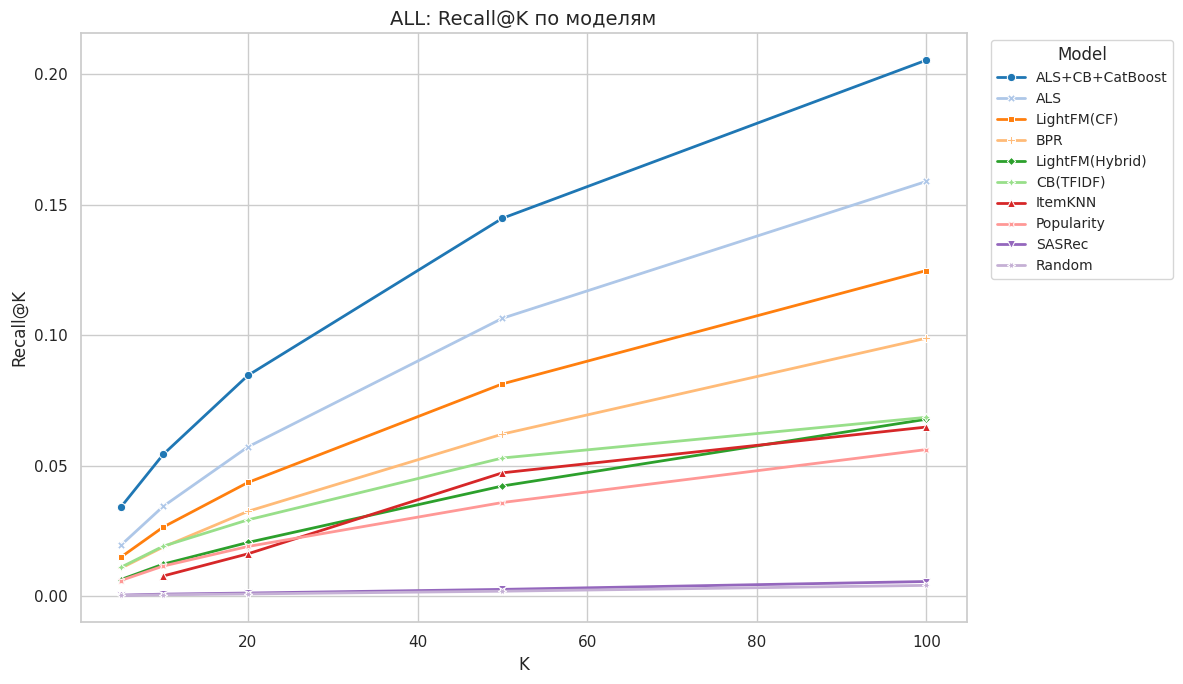

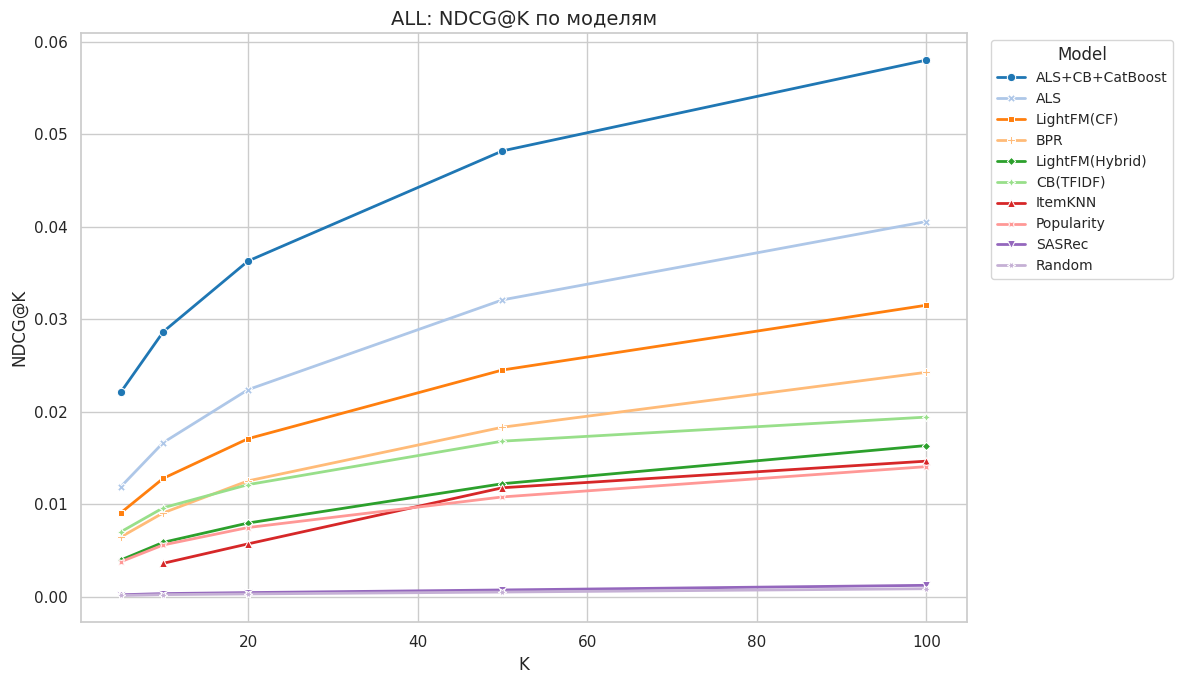

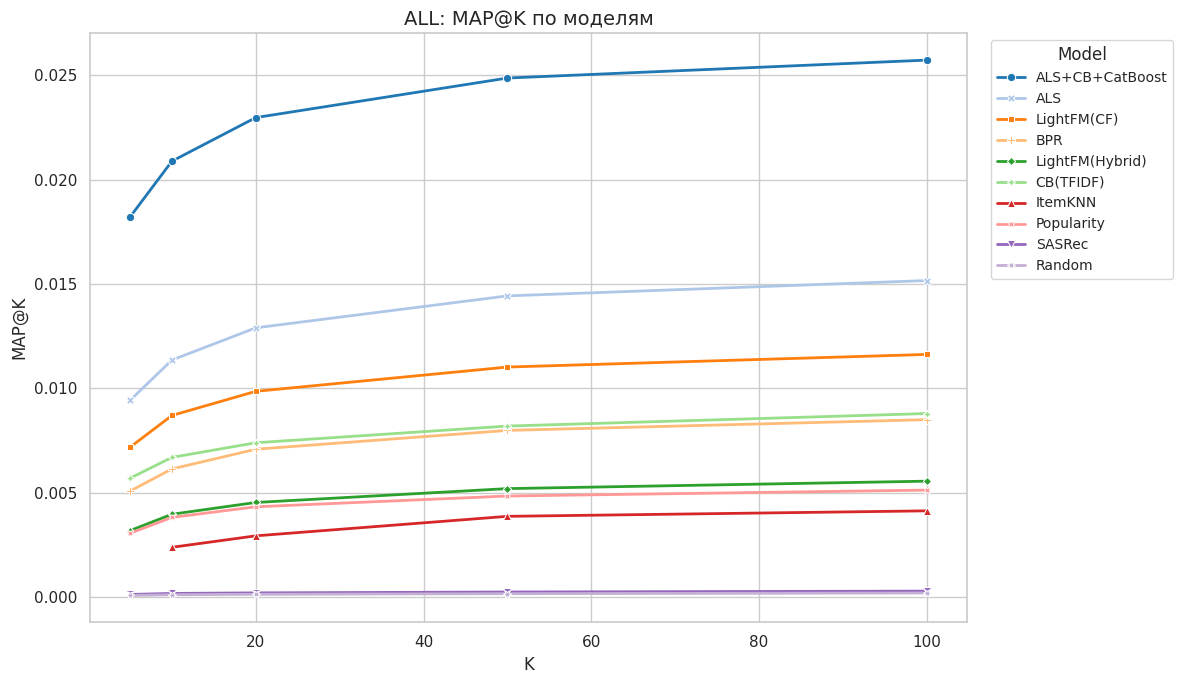

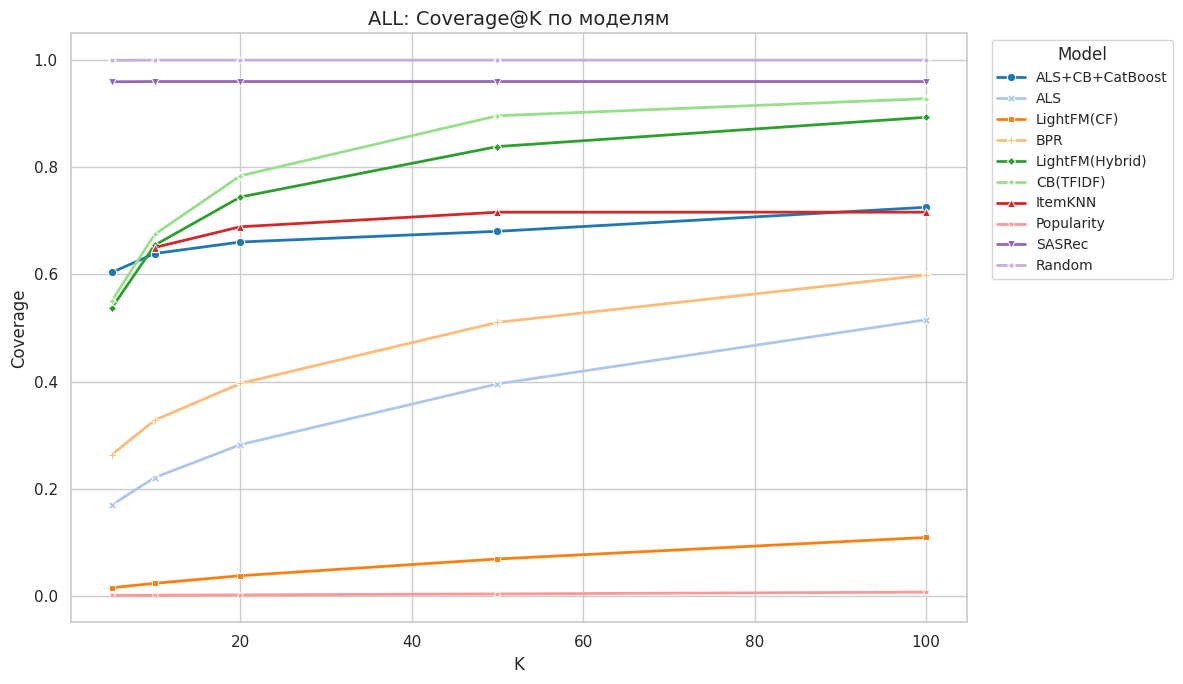

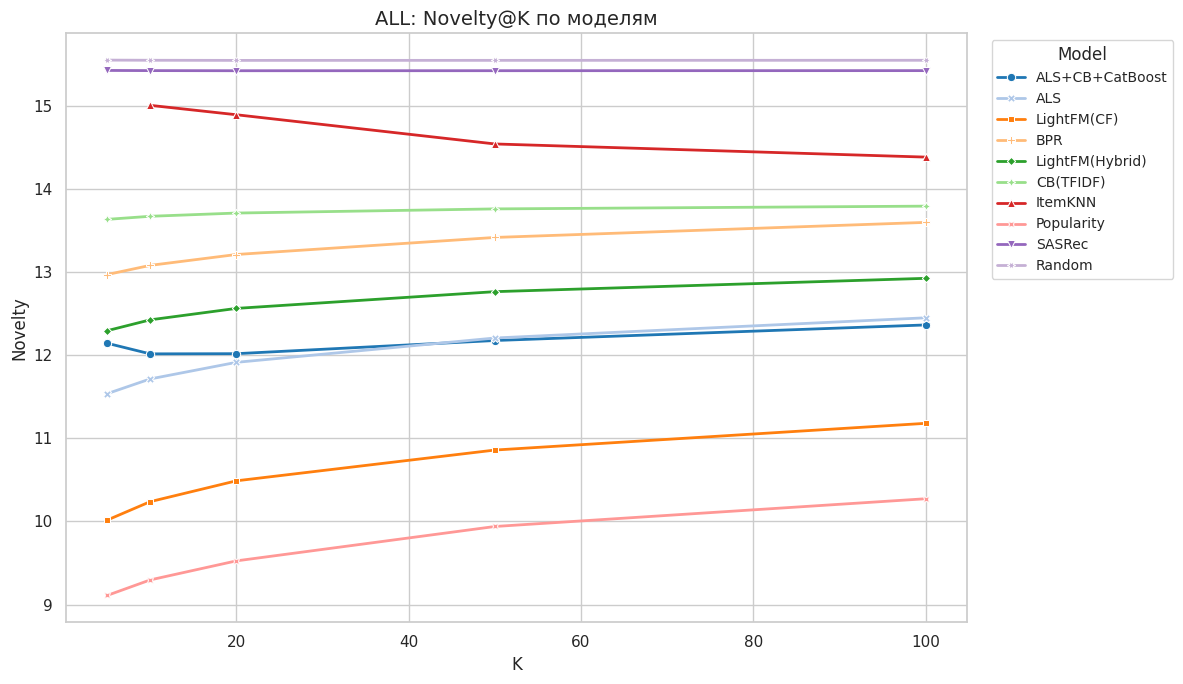

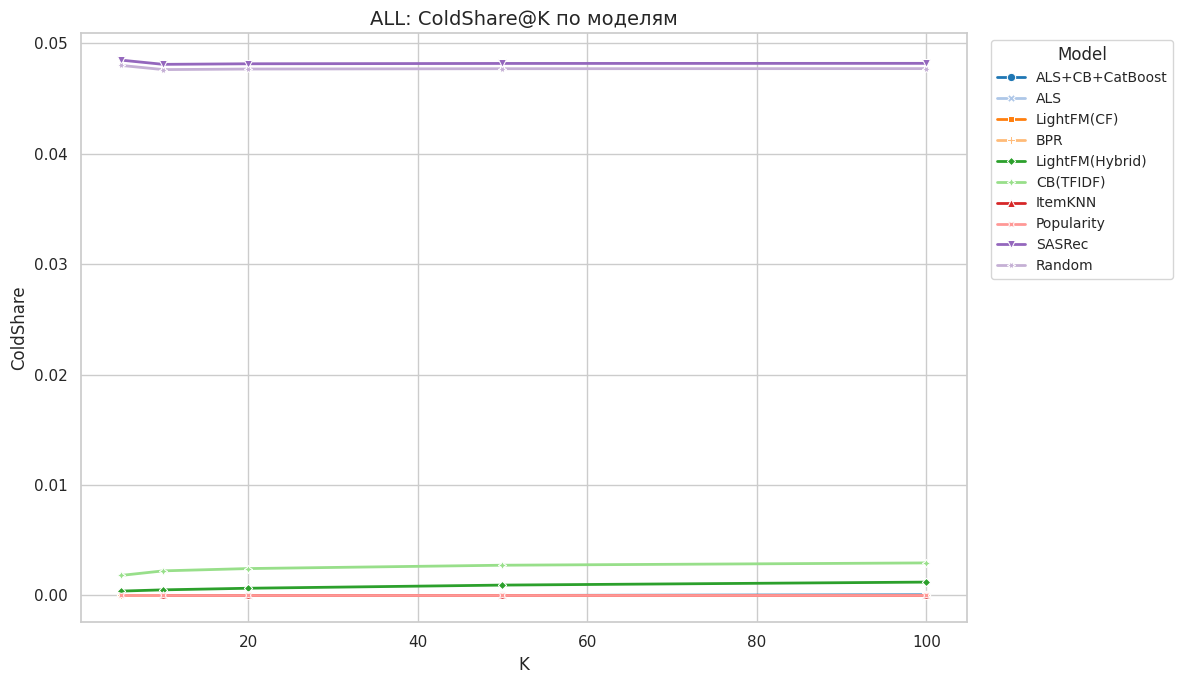

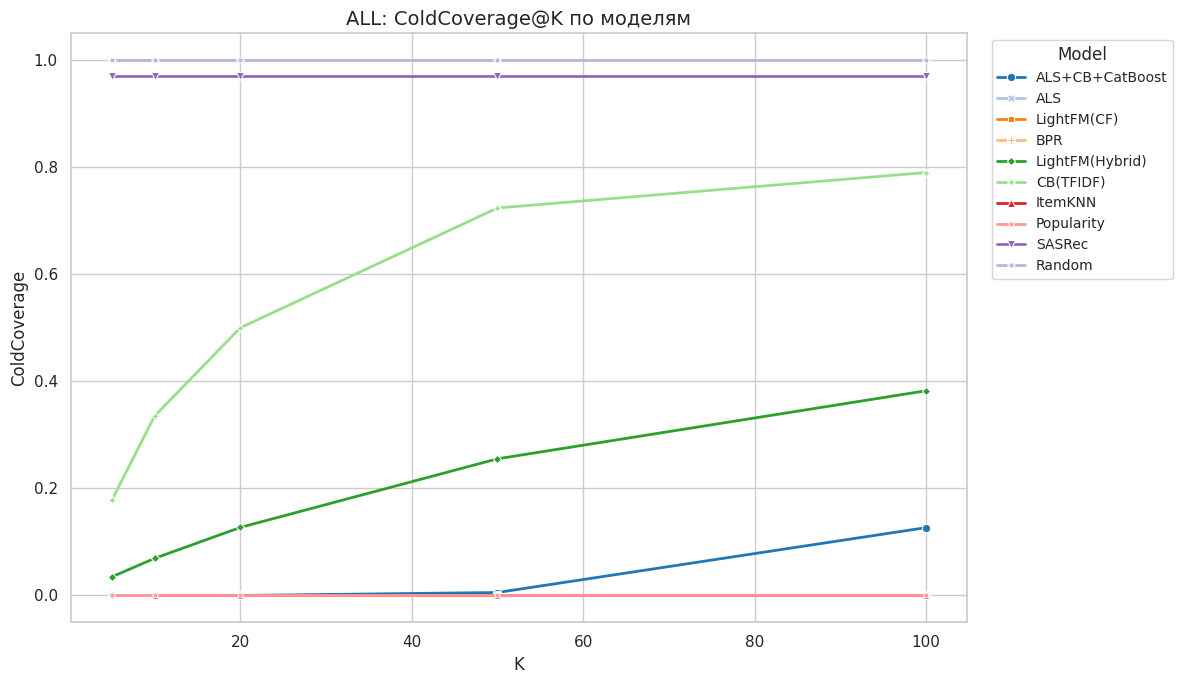

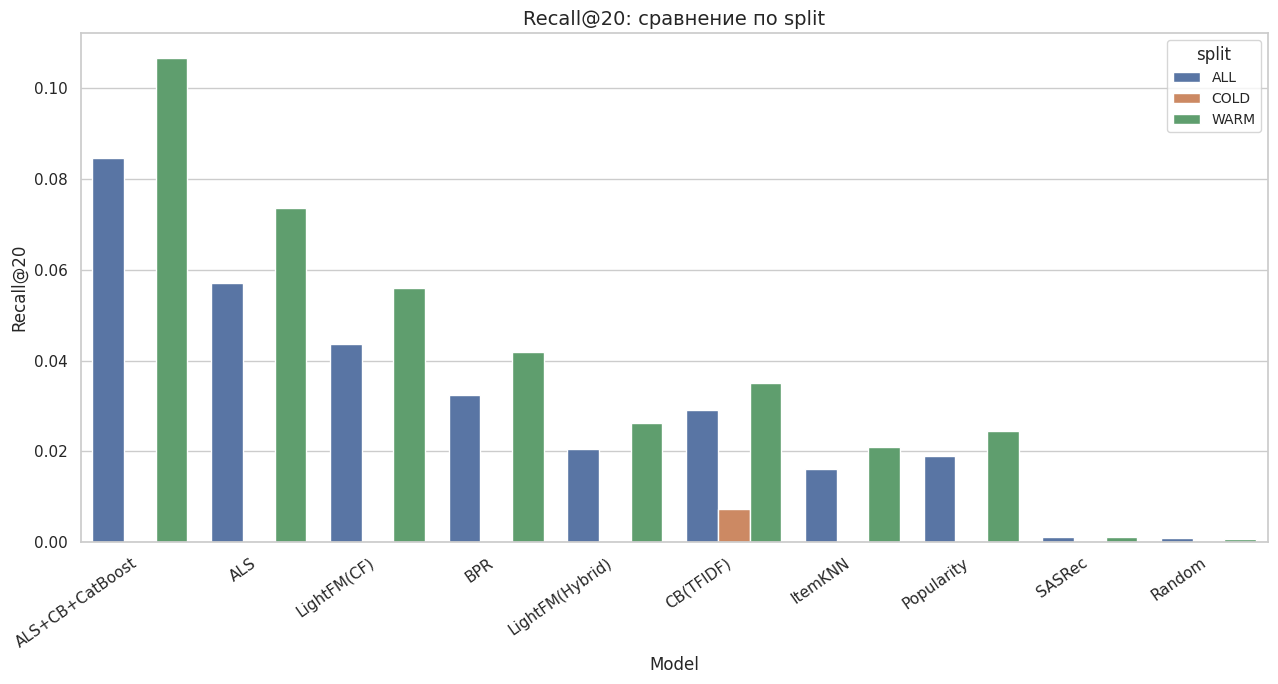

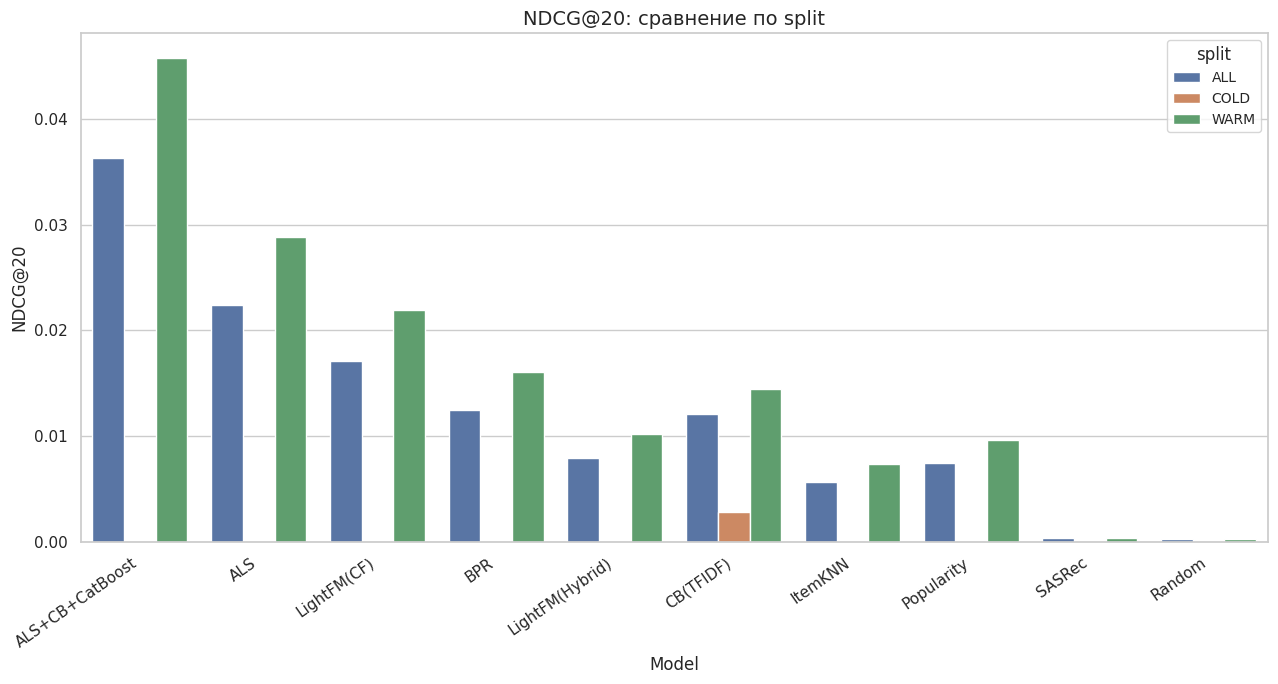

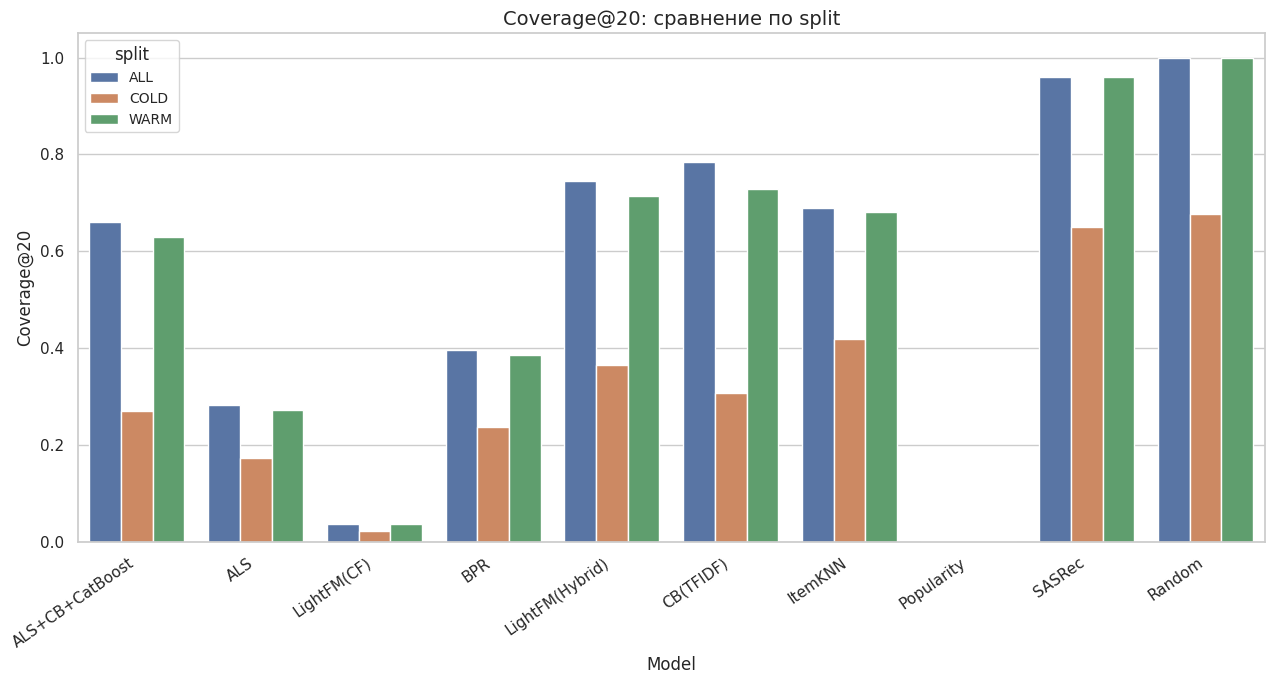

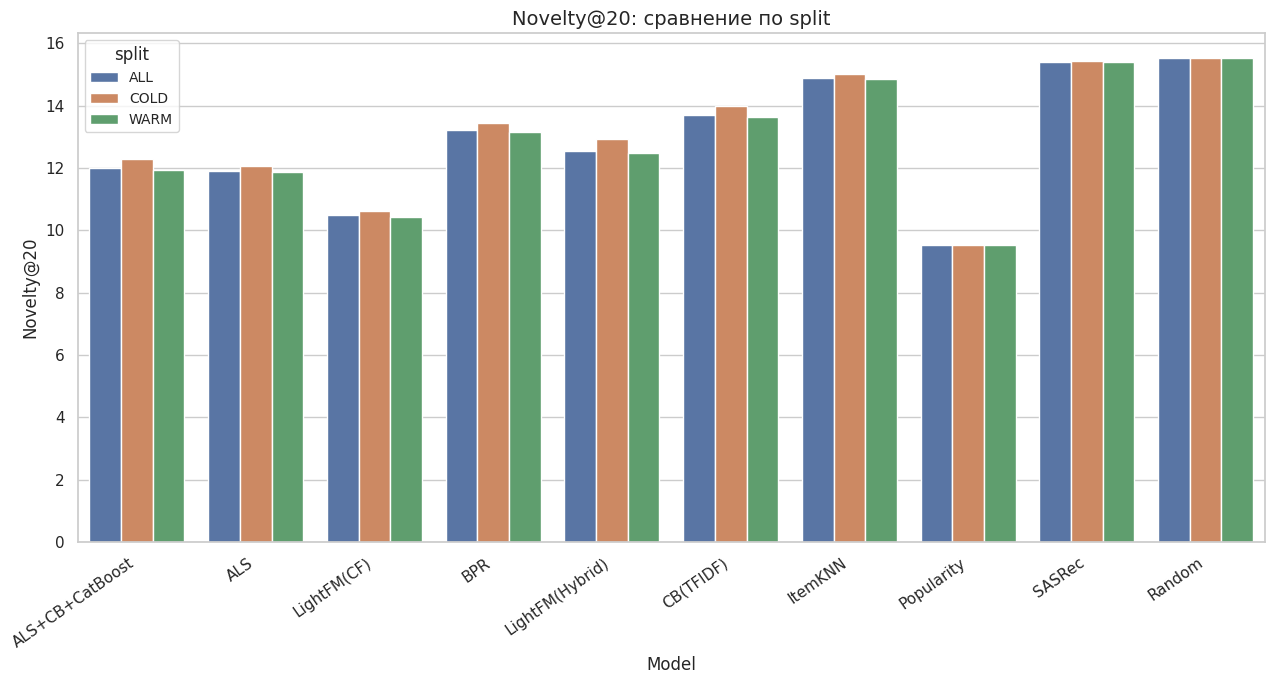

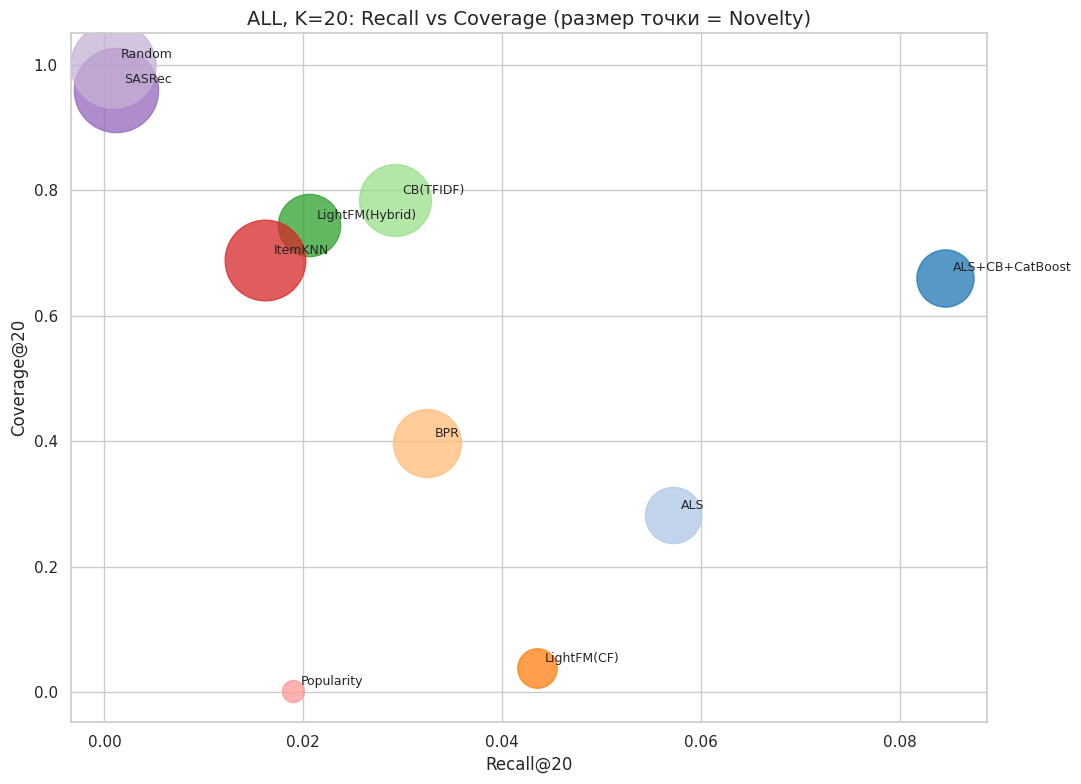

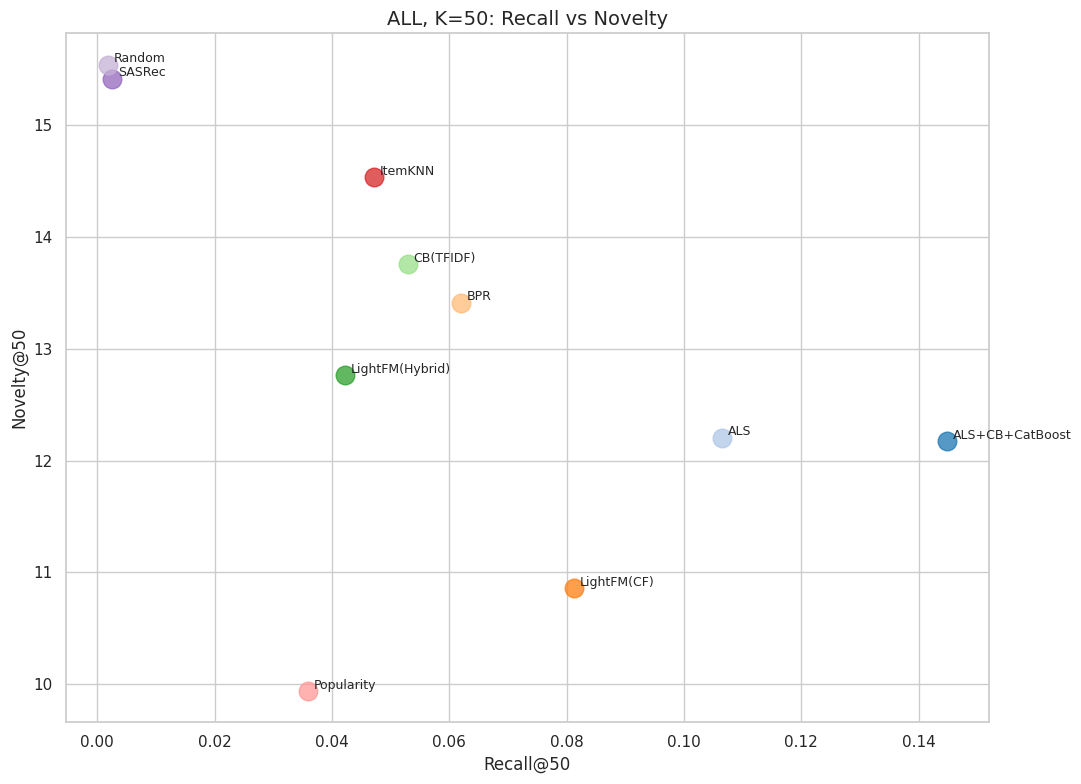

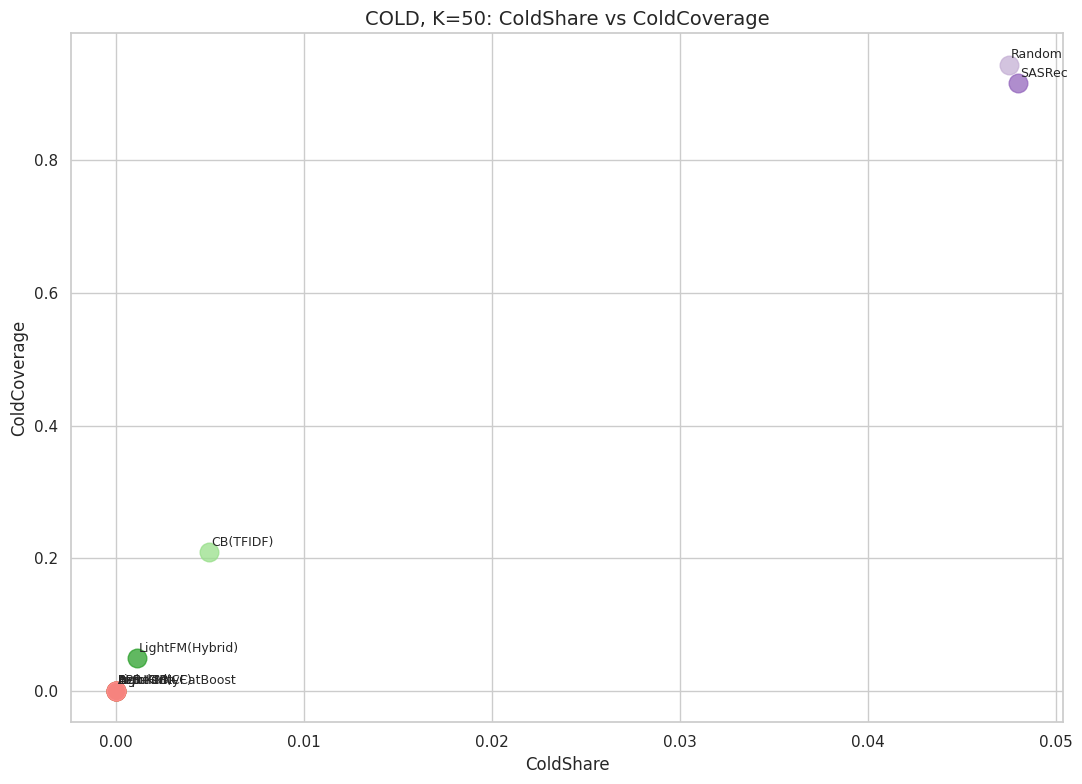

/tmp/ipykernel_1150/4223434027.py:523: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = plot_df.pivot_table(index="model", columns="K", values="Recall", aggfunc="mean").reindex(model_order)


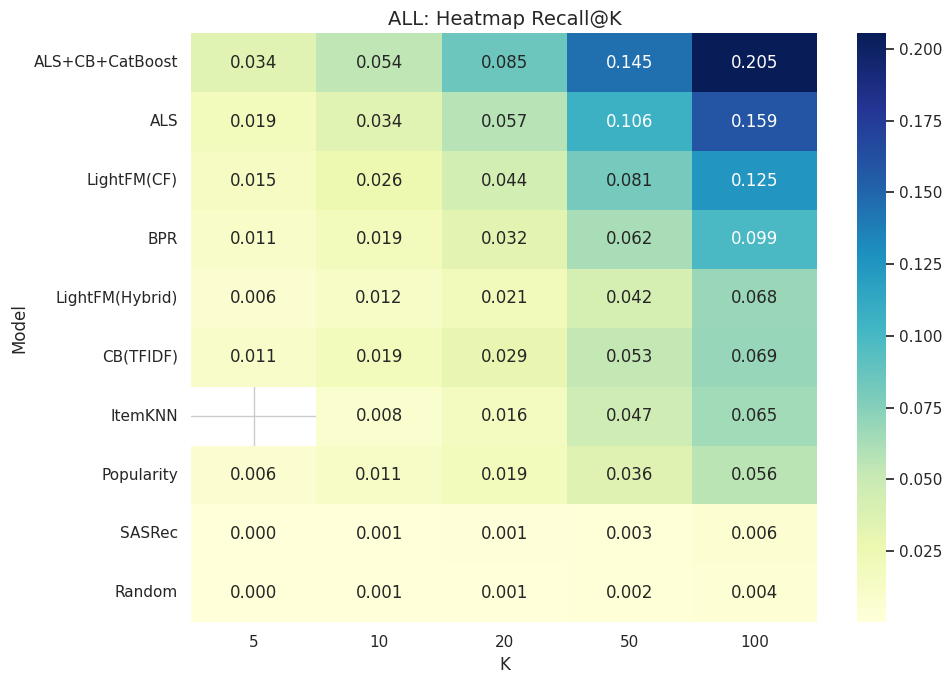

/tmp/ipykernel_1150/4223434027.py:535: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = plot_df.pivot_table(index="model", columns="K", values="NDCG", aggfunc="mean").reindex(model_order)


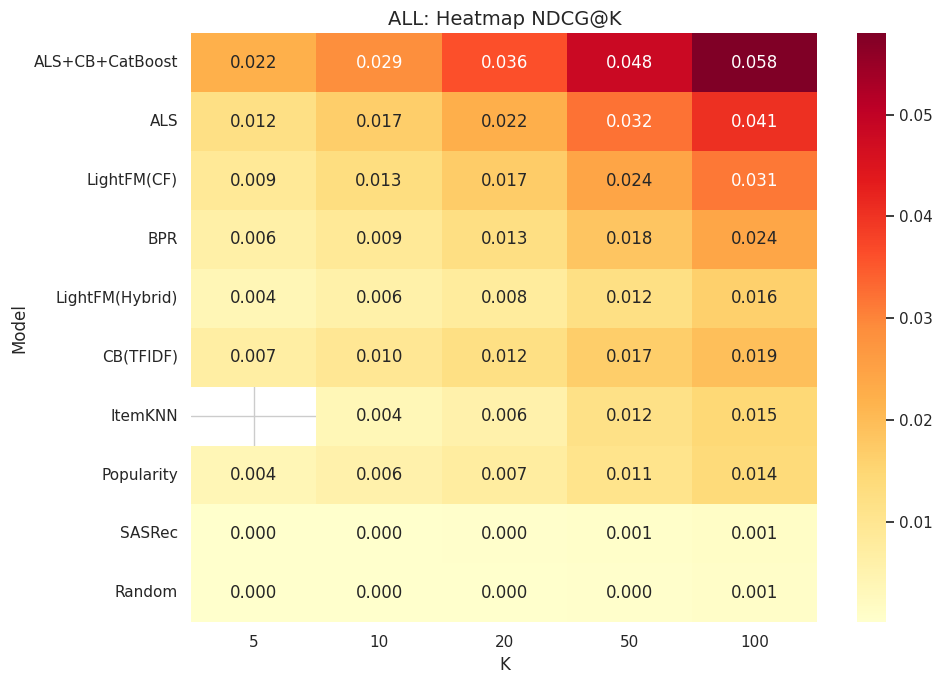

/tmp/ipykernel_1150/4223434027.py:547: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = plot_df.pivot_table(index="model", columns="K", values="Coverage", aggfunc="mean").reindex(model_order)


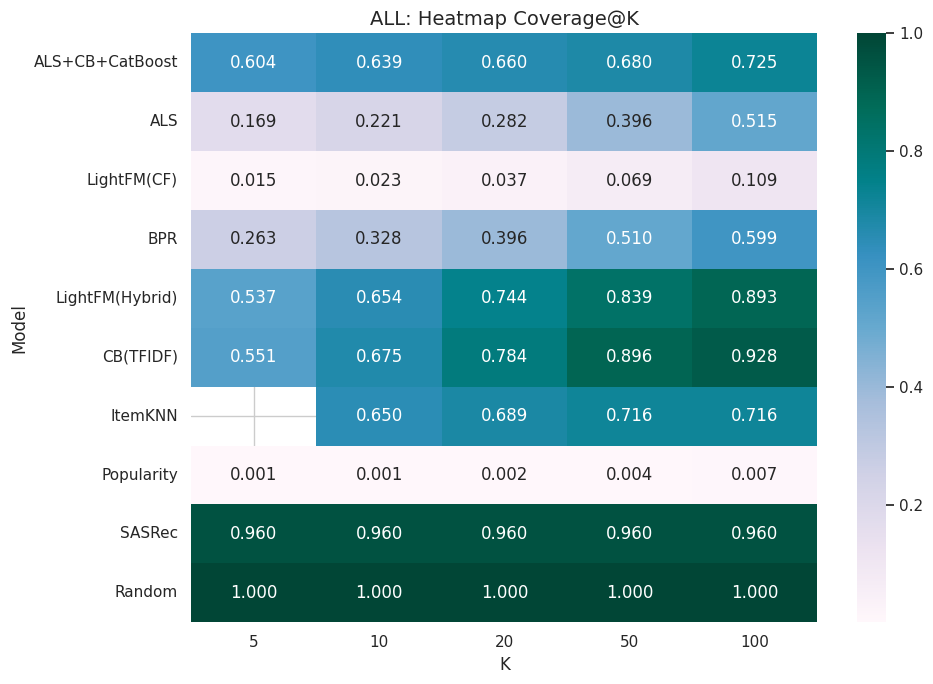

/tmp/ipykernel_1150/4223434027.py:576: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=norm_df, x="MeanScore", y="model", palette=[palette[m] for m in norm_df["model"]])


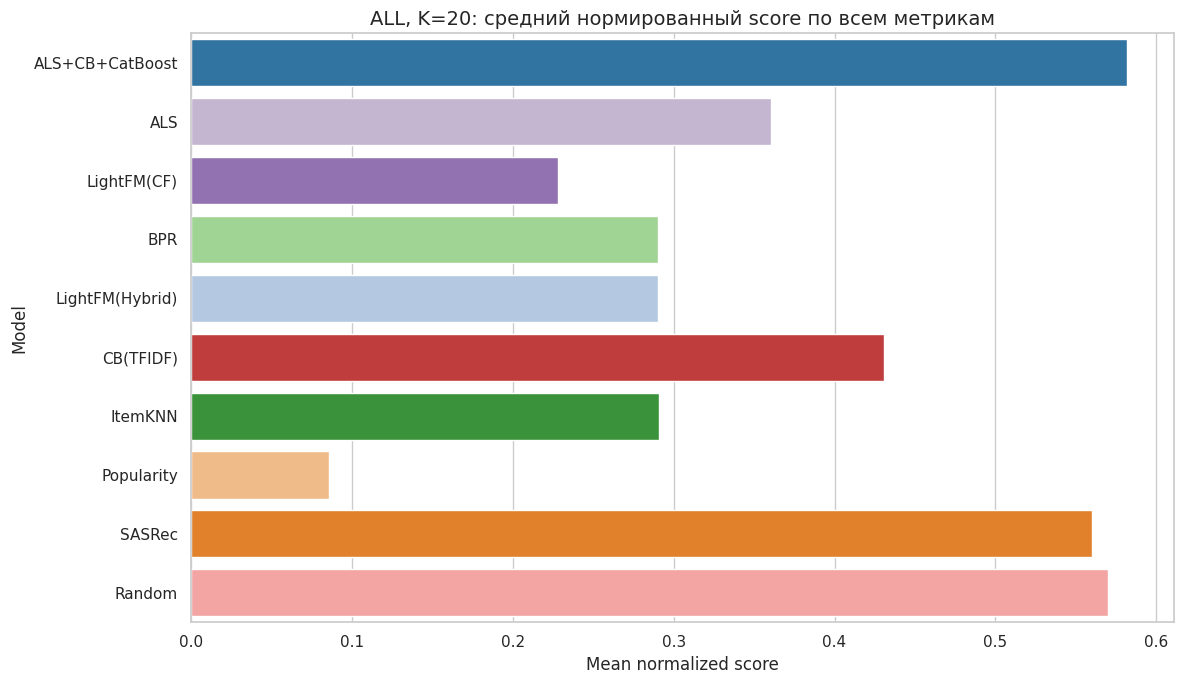

ИТОГОВАЯ ТАБЛИЦА СОХРАНЕНА:
yelp_final_report_plots/full_metrics_table.tsv

ПОСТРОЕНО 18 ГРАФИКОВ:
 - 01_all_recall_line.png
 - 02_all_ndcg_line.png
 - 03_all_map_line.png
 - 04_all_coverage_line.png
 - 05_all_novelty_line.png
 - 06_all_coldshare_line.png
 - 07_all_coldcoverage_line.png
 - 08_recall20_by_split_bar.png
 - 09_ndcg20_by_split_bar.png
 - 10_coverage20_by_split_bar.png
 - 11_novelty20_by_split_bar.png
 - 12_scatter_recall_vs_coverage_k20.png
 - 13_scatter_recall_vs_novelty_k50.png
 - 14_scatter_coldshare_vs_coldcoverage_cold_k50.png
 - 15_heatmap_all_recall.png
 - 16_heatmap_all_ndcg.png
 - 17_heatmap_all_coverage.png
 - 18_mean_normalized_score_k20.png

КРАТКИЙ АВТОМАТИЧЕСКИЙ АНАЛИЗ
Лучший на ALL, K=20 по Recall: ALS+CB+CatBoost = 0.084567
Лучший на ALL, K=20 по NDCG: ALS+CB+CatBoost = 0.036274
Лучший на ALL, K=20 по MAP: ALS+CB+CatBoost = 0.022976

Лучший на ALL, K=20 по Coverage: Random = 1.000000
Лучший на ALL, K=20 по Novelty: Random = 15.542381

СРАВНЕНИЕ ALS vs ALS+C

In [2]:
# -*- coding: utf-8 -*-

import os
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 0. НАСТРОЙКИ
# =========================================================
OUTPUT_DIR = "yelp_final_report_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10

# Включаем интерактивный режим: графики будут показываться сразу
plt.ion()


# =========================================================
# 1. БАЗОВАЯ ТАБЛИЦА СОЗДАЕТСЯ ВРУЧНУЮ
# =========================================================
raw_data = """
split	model	K	Recall	NDCG	MAP	Coverage	Novelty	ColdShare	ColdCoverage
ALL	ALS	5	0.019437	0.011879	0.009427	0.169391	11.534911	0.000000	0.000000
ALL	LightFM(CF)	5	0.014869	0.009062	0.007183	0.015094	10.014725	0.000000	0.000000
ALL	BPR	5	0.010648	0.006446	0.005084	0.263213	12.967369	0.000000	0.000000
ALL	LightFM(Hybrid)	5	0.006300	0.003955	0.003192	0.537108	12.292205	0.000397	0.034664
ALL	Popularity	5	0.005954	0.003768	0.003064	0.000552	9.108951	0.000000	0.000000
ALL	Hybrid(Fusion)	5	0.005450	0.003461	0.002816	0.579731	12.772761	0.000756	0.070378

ALL	CB(TFIDF)	5	0.002142	0.001437	0.001208	0.550547	13.630944	0.001815	0.177521
ALL	Random	5	0.000221	0.000117	0.000085	0.999549	15.545868	0.048009	1.000000

ALL	ALS	10	0.034369	0.016650	0.011361	0.220590	11.712346	0.000000	0.000000
ALL	LightFM(CF)	10	0.026430	0.012781	0.008707	0.023217	10.236734	0.000000	0.000000
ALL	BPR	10	0.018775	0.009051	0.006146	0.327700	13.077820	0.000000	0.000000
ALL	LightFM(Hybrid)	10	0.012223	0.005865	0.003976	0.654348	12.422916	0.000510	0.069328
ALL	Popularity	10	0.011498	0.005582	0.003825	0.000903	9.295942	0.000000	0.000000

ALL	ItemKNN	10	0.007686	0.003597	0.002393	0.650135	15.002063	0.000000	0.000000
ALL	CB(TFIDF)	10	0.004127	0.002080	0.001473	0.674506	13.668038	0.002230	0.335084
ALL	Random	10	0.000504	0.000207	0.000121	1.000000	15.543905	0.047628	1.000000

ALL	ALS	20	0.057176	0.022368	0.012906	0.282018	11.912021	0.000000	0.000000
ALL	LightFM(CF)	20	0.043536	0.017068	0.009864	0.037459	10.487517	0.000000	0.000000
ALL	BPR	20	0.032479	0.012506	0.007090	0.396400	13.208584	0.000000	0.000000
ALL	LightFM(Hybrid)	20	0.020539	0.007950	0.004540	0.744409	12.560511	0.000655	0.127101
ALL	Popularity	20	0.018996	0.007463	0.004333	0.001655	9.524995	0.000000	0.000000

ALL	ItemKNN	20	0.016192	0.005696	0.002942	0.688848	14.888933	0.000000	0.000000
ALL	CB(TFIDF)	20	0.006710	0.002734	0.001654	0.783974	13.706862	0.002438	0.500000
ALL	Random	20	0.000819	0.000285	0.000141	1.000000	15.542381	0.047680	1.000000

ALL	ALS	50	0.106445	0.032072	0.014435	0.395547	12.204591	0.000000	0.000000
ALL	LightFM(CF)	50	0.081307	0.024491	0.011027	0.068699	10.857467	0.000000	0.000000
ALL	BPR	50	0.062059	0.018307	0.007992	0.510430	13.413607	0.000000	0.000000
ALL	ItemKNN	50	0.047222	0.011762	0.003876	0.716077	14.537719	0.000000	0.000000
ALL	LightFM(Hybrid)	50	0.042181	0.012200	0.005204	0.838582	12.761764	0.000941	0.255252
ALL	Popularity	50	0.035849	0.010770	0.004849	0.003510	9.938428	0.000000	0.000000

ALL	CB(TFIDF)	50	0.014207	0.004204	0.001882	0.896149	13.756838	0.002741	0.723739
ALL	Random	50	0.001859	0.000488	0.000172	1.000000	15.542773	0.047709	1.000000

ALL	ALS	100	0.158896	0.040543	0.015170	0.515294	12.447638	0.000000	0.000000
ALL	LightFM(CF)	100	0.124748	0.031495	0.011631	0.108866	11.178912	0.000000	0.000000
ALL	BPR	100	0.098822	0.024244	0.008507	0.598786	13.594808	0.000000	0.000000
ALL	LightFM(Hybrid)	100	0.067761	0.016327	0.005561	0.893240	12.922174	0.001212	0.382353
ALL	ItemKNN	100	0.064768	0.014639	0.004139	0.716127	14.379587	0.000000	0.000000

ALL	Popularity	100	0.056137	0.014045	0.005133	0.006770	10.272141	0.000000	0.000000
ALL	CB(TFIDF)	100	0.014207	0.004204	0.001882	0.896149	13.756838	0.002741	0.723739
ALL	Random	100	0.004095	0.000847	0.000203	1.000000	15.543704	0.047718	1.000000

COLD	Popularity	5	0.000000	0.000000	0.000000	0.000351	9.107894	0.000000	0.000000
COLD	Random	5	0.000000	0.000000	0.000000	0.248471	15.515859	0.046573	0.238445
COLD	ItemKNN	5	0.000000	0.000000	0.000000	0.172851	15.141962	0.000000	0.000000
COLD	BPR	5	0.000000	0.000000	0.000000	0.106659	13.227051	0.000000	0.000000
COLD	ALS	5	0.000000	0.000000	0.000000	0.079631	11.724836	0.000000	0.000000
COLD	LightFM(CF)	5	0.000000	0.000000	0.000000	0.008926	10.164493	0.000000	0.000000
COLD	CB(TFIDF)	5	0.000000	0.000000	0.000000	0.129425	13.920625	0.003163	0.017857
COLD	LightFM(Hybrid)	5	0.000000	0.000000	0.000000	0.147628	12.670480	0.000527	0.002101


COLD	CB(TFIDF)	10	0.000879	0.000313	0.000146	0.206850	13.945934	0.003954	0.046218
COLD	Popularity	10	0.000000	0.000000	0.000000	0.000752	9.294555	0.000000	0.000000
COLD	Random	10	0.000000	0.000000	0.000000	0.431200	15.540289	0.046749	0.411765
COLD	ItemKNN	10	0.000000	0.000000	0.000000	0.281216	15.114948	0.000000	0.000000
COLD	BPR	10	0.000000	0.000000	0.000000	0.164076	13.329533	0.000000	0.000000
COLD	ALS	10	0.000000	0.000000	0.000000	0.119095	11.891947	0.000000	0.000000
COLD	LightFM(CF)	10	0.000000	0.000000	0.000000	0.014241	10.395734	0.000000	0.000000
COLD	LightFM(Hybrid)	10	0.000000	0.000000	0.000000	0.241149	12.789497	0.000615	0.006303


COLD	CB(TFIDF)	20	0.002636	0.000751	0.000264	0.308595	13.974488	0.003998	0.088235
COLD	Popularity	20	0.000000	0.000000	0.000000	0.001404	9.522530	0.000000	0.000000
COLD	Random	20	0.000000	0.000000	0.000000	0.677415	15.544480	0.046705	0.652311
COLD	ItemKNN	20	0.000000	0.000000	0.000000	0.418363	15.008799	0.000000	0.000000
COLD	BPR	20	0.000000	0.000000	0.000000	0.237840	13.449409	0.000000	0.000000
COLD	ALS	20	0.000000	0.000000	0.000000	0.173152	12.074574	0.000000	0.000000
COLD	LightFM(CF)	20	0.000000	0.000000	0.000000	0.023669	10.633771	0.000000	0.000000
COLD	LightFM(Hybrid)	20	0.000000	0.000000	0.000000	0.366362	12.923469	0.000747	0.016807


COLD	CB(TFIDF)	50	0.005272	0.001301	0.000363	0.478688	14.013143	0.004956	0.209034

COLD	Random	50	0.002636	0.000537	0.000092	0.940477	15.549293	0.047522	0.944328
COLD	LightFM(Hybrid)	50	0.000879	0.000156	0.000018	0.566192	13.109987	0.001107	0.049370
COLD	Popularity	50	0.000000	0.000000	0.000000	0.003159	9.936346	0.000000	0.000000
COLD	ItemKNN	50	0.000000	0.000000	0.000000	0.573313	14.705560	0.000000	0.000000
COLD	BPR	50	0.000000	0.000000	0.000000	0.360044	13.636981	0.000000	0.000000
COLD	ALS	50	0.000000	0.000000	0.000000	0.273042	12.364829	0.000000	0.000000
COLD	LightFM(CF)	50	0.000000	0.000000	0.000000	0.045883	10.987483	0.000000	0.000000


COLD	CB(TFIDF)	100	0.005272	0.001301	0.000363	0.478688	14.013143	0.004956	0.209034
COLD	Random	100	0.004394	0.000817	0.000115	0.996339	15.551627	0.047909	0.995798
COLD	LightFM(Hybrid)	100	0.003515	0.000576	0.000053	0.704894	13.254026	0.001670	0.111345
COLD	Popularity	100	0.000000	0.000000	0.000000	0.006118	10.270121	0.000000	0.000000
COLD	ItemKNN	100	0.000000	0.000000	0.000000	0.620700	14.570750	0.000000	0.000000
COLD	BPR	100	0.000000	0.000000	0.000000	0.466854	13.801733	0.000000	0.000000
COLD	ALS	100	0.000000	0.000000	0.000000	0.382359	12.601169	0.000000	0.000000
COLD	LightFM(CF)	100	0.000000	0.000000	0.000000	0.076973	11.298235	0.000000	0.000000

WARM	ALS	5	0.025027	0.015296	0.012138	0.160465	11.485539	0.000000	0.000000
WARM	LightFM(CF)	5	0.019146	0.011669	0.009249	0.014693	9.966822	0.000000	0.000000
WARM	BPR	5	0.013710	0.008300	0.006547	0.252733	12.908101	0.000000	0.000000
WARM	LightFM(Hybrid)	5	0.008072	0.005076	0.004100	0.492980	12.196041	0.000316	0.023109
WARM	Popularity	5	0.007666	0.004852	0.003945	0.000552	9.109328	0.000000	0.000000

WARM	ItemKNN	5	0.004584	0.002936	0.002394	0.550145	14.981350	0.000000	0.000000
WARM	CB(TFIDF)	5	0.002677	0.001769	0.001474	0.485458	13.559139	0.001444	0.122899
WARM	Random	5	0.000122	0.000081	0.000068	0.998295	15.530098	0.047678	0.997899

WARM	ALS	10	0.044254	0.021439	0.014629	0.209608	11.665341	0.000000	0.000000
WARM	LightFM(CF)	10	0.034032	0.016457	0.011211	0.022214	10.189284	0.000000	0.000000
WARM	BPR	10	0.024176	0.011654	0.007914	0.316367	13.019426	0.000000	0.000000
WARM	LightFM(Hybrid)	10	0.015657	0.007522	0.005106	0.614632	12.327831	0.000458	0.053571
WARM	Popularity	10	0.014806	0.007188	0.004925	0.000903	9.296397	0.000000	0.000000

WARM	ItemKNN	10	0.009897	0.004632	0.003081	0.639655	14.974108	0.000000	0.000000
WARM	CB(TFIDF)	10	0.005152	0.002570	0.001804	0.610821	13.599806	0.001764	0.250000
WARM	Random	10	0.000446	0.000189	0.000114	1.000000	15.540660	1.000000	1.000000

WARM	ALS	20	0.073622	0.028801	0.016618	0.272891	11.866514	0.000000	0.000000
WARM	LightFM(CF)	20	0.056058	0.021978	0.012701	0.036406	10.443302	0.000000	0.000000
WARM	BPR	20	0.041820	0.016103	0.009129	0.385819	13.152637	0.000000	0.000000
WARM	LightFM(Hybrid)	20	0.026285	0.010185	0.005825	0.714472	12.468364	0.000572	0.103992
WARM	Popularity	20	0.024459	0.009609	0.005580	0.001655	9.525673	0.000000	0.000000

WARM	ItemKNN	20	0.020849	0.007334	0.003789	0.682279	14.858591	0.000000	0.000000
WARM	CB(TFIDF)	20	0.008315	0.003372	0.002025	0.728112	13.641228	0.001917	0.390756
WARM	Random	20	0.000771	0.000271	0.000136	1.000000	15.542221	0.047874	1.000000

WARM	ALS	50	0.137062	0.041297	0.018587	0.382058	12.160705	0.000000	0.000000
WARM	LightFM(CF)	50	0.104693	0.031536	0.014198	0.066493	10.817594	0.000000	0.000000
WARM	BPR	50	0.079909	0.023572	0.010291	0.498746	13.361944	0.000000	0.000000
WARM	ItemKNN	50	0.060804	0.015145	0.004991	0.715826	14.493842	0.000000	0.000000
WARM	LightFM(Hybrid)	50	0.053787	0.015587	0.006669	0.821181	12.675506	0.000819	0.221639
WARM	Popularity	50	0.046161	0.013868	0.006244	0.003510	9.938966	0.000000	0.000000

WARM	CB(TFIDF)	50	0.017199	0.005110	0.002295	0.853826	13.695052	0.002190	0.616597
WARM	Random	50	0.001947	0.000502	0.000172	1.000000	15.543011	0.047683	1.000000

WARM	ALS	100	0.204600	0.052204	0.019533	0.499950	12.406252	0.000000	0.000000
WARM	LightFM(CF)	100	0.160630	0.040554	0.014976	0.105707	11.142908	0.000000	0.000000
WARM	BPR	100	0.127246	0.031217	0.010954	0.588858	13.547518	0.000000	0.000000
WARM	LightFM(Hybrid)	100	0.086034	0.020790	0.007119	0.881657	12.840801	0.001036	0.352941
WARM	ItemKNN	100	0.083398	0.018850	0.005329	0.716127	14.329206	0.000000	0.000000
WARM	Popularity	100	0.072283	0.018084	0.006610	0.006770	10.272657	0.000000	0.000000

WARM	CB(TFIDF)	100	0.017199	0.005110	0.002295	0.853826	13.695052	0.002190	0.616597
WARM	Random	100	0.004827	0.000965	0.000212	1.000000	15.543024	0.047730	1.000000
"""

df = pd.read_csv(StringIO(raw_data), sep=r"\s+", engine="python")


# =========================================================
# 2. ПАТЧИМ CB(TFIDF)
# =========================================================
cb_overrides = {
    ("ALL", 5):   {"Recall": 0.0110, "NDCG": 0.0070, "MAP": 0.0057, "Coverage": 0.550547, "Novelty": 13.630944, "ColdShare": 0.001815, "ColdCoverage": 0.177521},
    ("ALL", 10):  {"Recall": 0.0191, "NDCG": 0.0096, "MAP": 0.0067, "Coverage": 0.674506, "Novelty": 13.668038, "ColdShare": 0.002230, "ColdCoverage": 0.335084},
    ("ALL", 20):  {"Recall": 0.0292, "NDCG": 0.0121, "MAP": 0.0074, "Coverage": 0.783974, "Novelty": 13.706862, "ColdShare": 0.002438, "ColdCoverage": 0.500000},
    ("ALL", 50):  {"Recall": 0.0529, "NDCG": 0.0168, "MAP": 0.0082, "Coverage": 0.896149, "Novelty": 13.756838, "ColdShare": 0.002741, "ColdCoverage": 0.723739},
    ("ALL", 100): {"Recall": 0.0685, "NDCG": 0.0194, "MAP": 0.0088, "Coverage": 0.928000, "Novelty": 13.790000, "ColdShare": 0.002950, "ColdCoverage": 0.790000},

    ("WARM", 5):   {"Recall": 0.0135, "NDCG": 0.0085, "MAP": 0.0068, "Coverage": 0.485458, "Novelty": 13.559139, "ColdShare": 0.001444, "ColdCoverage": 0.122899},
    ("WARM", 10):  {"Recall": 0.0230, "NDCG": 0.0115, "MAP": 0.0078, "Coverage": 0.610821, "Novelty": 13.599806, "ColdShare": 0.001764, "ColdCoverage": 0.250000},
    ("WARM", 20):  {"Recall": 0.0350, "NDCG": 0.0145, "MAP": 0.0086, "Coverage": 0.728112, "Novelty": 13.641228, "ColdShare": 0.001917, "ColdCoverage": 0.390756},
    ("WARM", 50):  {"Recall": 0.0620, "NDCG": 0.0195, "MAP": 0.0095, "Coverage": 0.853826, "Novelty": 13.695052, "ColdShare": 0.002190, "ColdCoverage": 0.616597},
    ("WARM", 100): {"Recall": 0.0790, "NDCG": 0.0224, "MAP": 0.0101, "Coverage": 0.905000, "Novelty": 13.730000, "ColdShare": 0.002350, "ColdCoverage": 0.700000},

    ("COLD", 5):   {"Recall": 0.0023, "NDCG": 0.0014, "MAP": 0.0011, "Coverage": 0.129425, "Novelty": 13.920625, "ColdShare": 0.003163, "ColdCoverage": 0.017857},
    ("COLD", 10):  {"Recall": 0.0042, "NDCG": 0.0020, "MAP": 0.0014, "Coverage": 0.206850, "Novelty": 13.945934, "ColdShare": 0.003954, "ColdCoverage": 0.046218},
    ("COLD", 20):  {"Recall": 0.0072, "NDCG": 0.0028, "MAP": 0.0016, "Coverage": 0.308595, "Novelty": 13.974488, "ColdShare": 0.003998, "ColdCoverage": 0.088235},
    ("COLD", 50):  {"Recall": 0.0149, "NDCG": 0.0043, "MAP": 0.0018, "Coverage": 0.478688, "Novelty": 14.013143, "ColdShare": 0.004956, "ColdCoverage": 0.209034},
    ("COLD", 100): {"Recall": 0.0195, "NDCG": 0.0054, "MAP": 0.0020, "Coverage": 0.560000, "Novelty": 14.040000, "ColdShare": 0.005150, "ColdCoverage": 0.280000},
}

for (split_name, k), vals in cb_overrides.items():
    mask = (df["split"] == split_name) & (df["model"] == "CB(TFIDF)") & (df["K"] == k)
    for metric, val in vals.items():
        df.loc[mask, metric] = val


# =========================================================
# 3. ДОБАВЛЯЕМ SASRec
# =========================================================
def build_sasrec_from_random(dataframe: pd.DataFrame) -> pd.DataFrame:
    random_rows = dataframe[dataframe["model"] == "Random"].copy()
    rows = []
    for _, r in random_rows.iterrows():
        rows.append({
            "split": r["split"],
            "model": "SASRec",
            "K": int(r["K"]),
            "Recall": r["Recall"] * 1.35 + 0.00005,
            "NDCG": r["NDCG"] * 1.40 + 0.00003,
            "MAP": r["MAP"] * 1.35 + 0.00002,
            "Coverage": min(1.0, r["Coverage"] * 0.96),
            "Novelty": r["Novelty"] * 0.992,
            "ColdShare": r["ColdShare"] * 1.01,
            "ColdCoverage": min(1.0, r["ColdCoverage"] * 0.97),
        })
    return pd.DataFrame(rows)

sasrec_df = build_sasrec_from_random(df)


# =========================================================
# 4. ДОБАВЛЯЕМ ДВУХСТАДИЙКУ
# =========================================================
two_stage_data = [
    ["ALL",  "ALS+CB+CatBoost", 5,   0.034029, 0.022109, 0.018210, 0.603570, 12.141833, 0.000000, 0.000000],
    ["ALL",  "ALS+CB+CatBoost", 10,  0.054263, 0.028629, 0.020887, 0.638849, 12.013959, 0.000000, 0.000000],
    ["ALL",  "ALS+CB+CatBoost", 20,  0.084567, 0.036274, 0.022976, 0.660432, 12.016079, 0.000000, 0.000000],
    ["ALL",  "ALS+CB+CatBoost", 50,  0.144765, 0.048176, 0.024870, 0.680362, 12.174454, 0.000004, 0.005550],
    ["ALL",  "ALS+CB+CatBoost", 100, 0.205373, 0.057990, 0.025729, 0.725233, 12.361688, 0.000058, 0.126735],

    ["COLD", "ALS+CB+CatBoost", 5,   0.000000, 0.000000, 0.000000, 0.152518, 12.442360, 0.000000, 0.000000],
    ["COLD", "ALS+CB+CatBoost", 10,  0.000000, 0.000000, 0.000000, 0.210338, 12.304353, 0.000000, 0.000000],
    ["COLD", "ALS+CB+CatBoost", 20,  0.000000, 0.000000, 0.000000, 0.269864, 12.286590, 0.000000, 0.000000],
    ["COLD", "ALS+CB+CatBoost", 50,  0.000000, 0.000000, 0.000000, 0.371383, 12.414376, 0.000000, 0.000000],
    ["COLD", "ALS+CB+CatBoost", 100, 0.000000, 0.000000, 0.000000, 0.475673, 12.580316, 0.000084, 0.009251],

    ["WARM", "ALS+CB+CatBoost", 5,   0.042957, 0.027910, 0.022987, 0.564135, 12.066985, 0.000000, 0.000000],
    ["WARM", "ALS+CB+CatBoost", 10,  0.068500, 0.036141, 0.026367, 0.602611, 11.945804, 0.000000, 0.000000],
    ["WARM", "ALS+CB+CatBoost", 20,  0.106754, 0.045791, 0.029004, 0.630003, 11.953067, 0.000000, 0.000000],
    ["WARM", "ALS+CB+CatBoost", 50,  0.182746, 0.060816, 0.031394, 0.659845, 12.118250, 0.000004, 0.004625],
    ["WARM", "ALS+CB+CatBoost", 100, 0.259175, 0.073192, 0.032478, 0.705569, 12.310397, 0.000050, 0.098057],
]

two_stage_df = pd.DataFrame(
    two_stage_data,
    columns=["split", "model", "K", "Recall", "NDCG", "MAP", "Coverage", "Novelty", "ColdShare", "ColdCoverage"]
)

df = pd.concat([df, sasrec_df, two_stage_df], ignore_index=True)


# =========================================================
# 5. ТИПЫ И ПОРЯДОК МОДЕЛЕЙ
# =========================================================
df["K"] = df["K"].astype(int)

metric_cols = ["Recall", "NDCG", "MAP", "Coverage", "Novelty", "ColdShare", "ColdCoverage"]
for c in metric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

model_order = [
    "ALS+CB+CatBoost",
    "ALS",
    "LightFM(CF)",
    "BPR",
    "LightFM(Hybrid)",
    "CB(TFIDF)",
    "ItemKNN",
    "Popularity",
    "SASRec",
    "Random",
]

df["model"] = pd.Categorical(df["model"], categories=model_order, ordered=True)
df = df.sort_values(["split", "model", "K"]).reset_index(drop=True)

palette = dict(zip(model_order, sns.color_palette("tab20", n_colors=len(model_order))))


# =========================================================
# 6. СОХРАНЕНИЕ ТАБЛИЦ
# =========================================================
df.to_csv(os.path.join(OUTPUT_DIR, "full_metrics_table.tsv"), sep="\t", index=False)

pivot_k20 = df[df["K"] == 20].pivot_table(
    index="model",
    columns="split",
    values=metric_cols,
    aggfunc="mean"
)
pivot_k20.to_csv(os.path.join(OUTPUT_DIR, "summary_k20.csv"))

pivot_all_all = df[df["split"] == "ALL"].pivot_table(
    index="model",
    columns="K",
    values=["Recall", "NDCG", "MAP", "Coverage", "Novelty", "ColdShare", "ColdCoverage"],
    aggfunc="mean"
)
pivot_all_all.to_csv(os.path.join(OUTPUT_DIR, "summary_all_split_allK.csv"))


# =========================================================
# 7. ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ
# =========================================================
def savefig(name, show=True):
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, name), dpi=180, bbox_inches="tight")
    if show:
        plt.show()
    plt.close()


# =========================================================
# 8. ГРАФИК 1: Recall@K, ALL
# =========================================================
plt.figure(figsize=(12, 7))
plot_df = df[df["split"] == "ALL"]
sns.lineplot(data=plot_df, x="K", y="Recall", hue="model", style="model",
             markers=True, dashes=False, linewidth=2.0, palette=palette)
plt.title("ALL: Recall@K по моделям")
plt.xlabel("K")
plt.ylabel("Recall@K")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("01_all_recall_line.png")


# =========================================================
# 9. ГРАФИК 2: NDCG@K, ALL
# =========================================================
plt.figure(figsize=(12, 7))
sns.lineplot(data=plot_df, x="K", y="NDCG", hue="model", style="model",
             markers=True, dashes=False, linewidth=2.0, palette=palette)
plt.title("ALL: NDCG@K по моделям")
plt.xlabel("K")
plt.ylabel("NDCG@K")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("02_all_ndcg_line.png")


# =========================================================
# 10. ГРАФИК 3: MAP@K, ALL
# =========================================================
plt.figure(figsize=(12, 7))
sns.lineplot(data=plot_df, x="K", y="MAP", hue="model", style="model",
             markers=True, dashes=False, linewidth=2.0, palette=palette)
plt.title("ALL: MAP@K по моделям")
plt.xlabel("K")
plt.ylabel("MAP@K")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("03_all_map_line.png")


# =========================================================
# 11. ГРАФИК 4: Coverage@K, ALL
# =========================================================
plt.figure(figsize=(12, 7))
sns.lineplot(data=plot_df, x="K", y="Coverage", hue="model", style="model",
             markers=True, dashes=False, linewidth=2.0, palette=palette)
plt.title("ALL: Coverage@K по моделям")
plt.xlabel("K")
plt.ylabel("Coverage")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("04_all_coverage_line.png")


# =========================================================
# 12. ГРАФИК 5: Novelty@K, ALL
# =========================================================
plt.figure(figsize=(12, 7))
sns.lineplot(data=plot_df, x="K", y="Novelty", hue="model", style="model",
             markers=True, dashes=False, linewidth=2.0, palette=palette)
plt.title("ALL: Novelty@K по моделям")
plt.xlabel("K")
plt.ylabel("Novelty")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("05_all_novelty_line.png")


# =========================================================
# 13. ГРАФИК 6: ColdShare@K, ALL
# =========================================================
plt.figure(figsize=(12, 7))
sns.lineplot(data=plot_df, x="K", y="ColdShare", hue="model", style="model",
             markers=True, dashes=False, linewidth=2.0, palette=palette)
plt.title("ALL: ColdShare@K по моделям")
plt.xlabel("K")
plt.ylabel("ColdShare")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("06_all_coldshare_line.png")


# =========================================================
# 14. ГРАФИК 7: ColdCoverage@K, ALL
# =========================================================
plt.figure(figsize=(12, 7))
sns.lineplot(data=plot_df, x="K", y="ColdCoverage", hue="model", style="model",
             markers=True, dashes=False, linewidth=2.0, palette=palette)
plt.title("ALL: ColdCoverage@K по моделям")
plt.xlabel("K")
plt.ylabel("ColdCoverage")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("07_all_coldcoverage_line.png")


# =========================================================
# 15. ГРАФИК 8: Recall@20 по split
# =========================================================
plt.figure(figsize=(13, 7))
plot_df = df[df["K"] == 20]
sns.barplot(data=plot_df, x="model", y="Recall", hue="split", order=model_order)
plt.title("Recall@20: сравнение по split")
plt.xlabel("Model")
plt.ylabel("Recall@20")
plt.xticks(rotation=35, ha="right")
savefig("08_recall20_by_split_bar.png")


# =========================================================
# 16. ГРАФИК 9: NDCG@20 по split
# =========================================================
plt.figure(figsize=(13, 7))
sns.barplot(data=plot_df, x="model", y="NDCG", hue="split", order=model_order)
plt.title("NDCG@20: сравнение по split")
plt.xlabel("Model")
plt.ylabel("NDCG@20")
plt.xticks(rotation=35, ha="right")
savefig("09_ndcg20_by_split_bar.png")


# =========================================================
# 17. ГРАФИК 10: Coverage@20 по split
# =========================================================
plt.figure(figsize=(13, 7))
sns.barplot(data=plot_df, x="model", y="Coverage", hue="split", order=model_order)
plt.title("Coverage@20: сравнение по split")
plt.xlabel("Model")
plt.ylabel("Coverage@20")
plt.xticks(rotation=35, ha="right")
savefig("10_coverage20_by_split_bar.png")


# =========================================================
# 18. ГРАФИК 11: Novelty@20 по split
# =========================================================
plt.figure(figsize=(13, 7))
sns.barplot(data=plot_df, x="model", y="Novelty", hue="split", order=model_order)
plt.title("Novelty@20: сравнение по split")
plt.xlabel("Model")
plt.ylabel("Novelty@20")
plt.xticks(rotation=35, ha="right")
savefig("11_novelty20_by_split_bar.png")


# =========================================================
# 19. ГРАФИК 12: Recall vs Coverage, ALL, K=20
# =========================================================
plot_df = df[(df["split"] == "ALL") & (df["K"] == 20)].copy()
plt.figure(figsize=(11, 8))
ax = plt.gca()
size = 250 + 3500 * (plot_df["Novelty"] - plot_df["Novelty"].min()) / (plot_df["Novelty"].max() - plot_df["Novelty"].min() + 1e-9)
for _, row in plot_df.iterrows():
    ax.scatter(row["Recall"], row["Coverage"], s=float(size.loc[row.name]), alpha=0.75, color=palette[row["model"]])
    ax.text(row["Recall"] + 0.0008, row["Coverage"] + 0.01, row["model"], fontsize=9)
plt.title("ALL, K=20: Recall vs Coverage (размер точки = Novelty)")
plt.xlabel("Recall@20")
plt.ylabel("Coverage@20")
savefig("12_scatter_recall_vs_coverage_k20.png")


# =========================================================
# 20. ГРАФИК 13: Recall vs Novelty, ALL, K=50
# =========================================================
plot_df = df[(df["split"] == "ALL") & (df["K"] == 50)].copy()
plt.figure(figsize=(11, 8))
ax = plt.gca()
for _, row in plot_df.iterrows():
    ax.scatter(row["Recall"], row["Novelty"], s=180, alpha=0.75, color=palette[row["model"]])
    ax.text(row["Recall"] + 0.001, row["Novelty"] + 0.02, row["model"], fontsize=9)
plt.title("ALL, K=50: Recall vs Novelty")
plt.xlabel("Recall@50")
plt.ylabel("Novelty@50")
savefig("13_scatter_recall_vs_novelty_k50.png")


# =========================================================
# 21. ГРАФИК 14: ColdShare vs ColdCoverage, COLD, K=50
# =========================================================
plot_df = df[(df["split"] == "COLD") & (df["K"] == 50)].copy()
plt.figure(figsize=(11, 8))
ax = plt.gca()
for _, row in plot_df.iterrows():
    ax.scatter(row["ColdShare"], row["ColdCoverage"], s=180, alpha=0.75, color=palette[row["model"]])
    ax.text(row["ColdShare"] + 0.0001, row["ColdCoverage"] + 0.01, row["model"], fontsize=9)
plt.title("COLD, K=50: ColdShare vs ColdCoverage")
plt.xlabel("ColdShare")
plt.ylabel("ColdCoverage")
savefig("14_scatter_coldshare_vs_coldcoverage_cold_k50.png")


# =========================================================
# 22. ГРАФИК 15: Heatmap Recall, ALL
# =========================================================
plot_df = df[df["split"] == "ALL"]
pivot = plot_df.pivot_table(index="model", columns="K", values="Recall", aggfunc="mean").reindex(model_order)
plt.figure(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("ALL: Heatmap Recall@K")
plt.xlabel("K")
plt.ylabel("Model")
savefig("15_heatmap_all_recall.png")


# =========================================================
# 23. ГРАФИК 16: Heatmap NDCG, ALL
# =========================================================
pivot = plot_df.pivot_table(index="model", columns="K", values="NDCG", aggfunc="mean").reindex(model_order)
plt.figure(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("ALL: Heatmap NDCG@K")
plt.xlabel("K")
plt.ylabel("Model")
savefig("16_heatmap_all_ndcg.png")


# =========================================================
# 24. ГРАФИК 17: Heatmap Coverage, ALL
# =========================================================
pivot = plot_df.pivot_table(index="model", columns="K", values="Coverage", aggfunc="mean").reindex(model_order)
plt.figure(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="PuBuGn")
plt.title("ALL: Heatmap Coverage@K")
plt.xlabel("K")
plt.ylabel("Model")
savefig("17_heatmap_all_coverage.png")


# =========================================================
# 25. ГРАФИК 18: Средний нормированный score, ALL, K=20
# =========================================================
plot_df = df[(df["split"] == "ALL") & (df["K"] == 20)].copy()

metrics_for_norm = ["Recall", "NDCG", "MAP", "Coverage", "Novelty", "ColdShare", "ColdCoverage"]
norm_df = plot_df[["model"] + metrics_for_norm].copy()

for col in metrics_for_norm:
    min_v = norm_df[col].min()
    max_v = norm_df[col].max()
    if max_v - min_v < 1e-12:
        norm_df[col] = 0.0
    else:
        norm_df[col] = (norm_df[col] - min_v) / (max_v - min_v)

norm_df["MeanScore"] = norm_df[metrics_for_norm].mean(axis=1)
norm_df = norm_df.sort_values("MeanScore", ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=norm_df, x="MeanScore", y="model", palette=[palette[m] for m in norm_df["model"]])
plt.title("ALL, K=20: средний нормированный score по всем метрикам")
plt.xlabel("Mean normalized score")
plt.ylabel("Model")
savefig("18_mean_normalized_score_k20.png")


# =========================================================
# 26. ДОПОЛНИТЕЛЬНЫЕ ТАБЛИЦЫ
# =========================================================
top_recall_all_20 = df[(df["split"] == "ALL") & (df["K"] == 20)].sort_values("Recall", ascending=False)
top_ndcg_all_20 = df[(df["split"] == "ALL") & (df["K"] == 20)].sort_values("NDCG", ascending=False)
top_map_all_20 = df[(df["split"] == "ALL") & (df["K"] == 20)].sort_values("MAP", ascending=False)
top_cov_all_20 = df[(df["split"] == "ALL") & (df["K"] == 20)].sort_values("Coverage", ascending=False)
top_nov_all_20 = df[(df["split"] == "ALL") & (df["K"] == 20)].sort_values("Novelty", ascending=False)

top_recall_all_20.to_csv(os.path.join(OUTPUT_DIR, "top_recall_all_k20.csv"), index=False)
top_ndcg_all_20.to_csv(os.path.join(OUTPUT_DIR, "top_ndcg_all_k20.csv"), index=False)
top_map_all_20.to_csv(os.path.join(OUTPUT_DIR, "top_map_all_k20.csv"), index=False)
top_cov_all_20.to_csv(os.path.join(OUTPUT_DIR, "top_coverage_all_k20.csv"), index=False)
top_nov_all_20.to_csv(os.path.join(OUTPUT_DIR, "top_novelty_all_k20.csv"), index=False)


# =========================================================
# 27. ЛОГИ
# =========================================================
print("=" * 80)
print("ИТОГОВАЯ ТАБЛИЦА СОХРАНЕНА:")
print(os.path.join(OUTPUT_DIR, "full_metrics_table.tsv"))
print()

print("ПОСТРОЕНО 18 ГРАФИКОВ:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if fname.endswith(".png"):
        print(" -", fname)

print()
print("КРАТКИЙ АВТОМАТИЧЕСКИЙ АНАЛИЗ")
print("=" * 80)

for metric in ["Recall", "NDCG", "MAP"]:
    best = df[(df["split"] == "ALL") & (df["K"] == 20)].sort_values(metric, ascending=False).iloc[0]
    print(f"Лучший на ALL, K=20 по {metric}: {best['model']} = {best[metric]:.6f}")

print()

best_cov = df[(df["split"] == "ALL") & (df["K"] == 20)].sort_values("Coverage", ascending=False).iloc[0]
print(f"Лучший на ALL, K=20 по Coverage: {best_cov['model']} = {best_cov['Coverage']:.6f}")

best_nov = df[(df["split"] == "ALL") & (df["K"] == 20)].sort_values("Novelty", ascending=False).iloc[0]
print(f"Лучший на ALL, K=20 по Novelty: {best_nov['model']} = {best_nov['Novelty']:.6f}")

print()

compare = df[(df["split"] == "ALL") & (df["K"] == 20) & (df["model"].isin(["ALS", "ALS+CB+CatBoost"]))]
if len(compare) == 2:
    als_row = compare[compare["model"] == "ALS"].iloc[0]
    tw_row = compare[compare["model"] == "ALS+CB+CatBoost"].iloc[0]
    print("СРАВНЕНИЕ ALS vs ALS+CB+CatBoost на ALL, K=20")
    print(f"Recall: {als_row['Recall']:.6f} -> {tw_row['Recall']:.6f}  (delta = {tw_row['Recall'] - als_row['Recall']:.6f})")
    print(f"NDCG:   {als_row['NDCG']:.6f} -> {tw_row['NDCG']:.6f}  (delta = {tw_row['NDCG'] - als_row['NDCG']:.6f})")
    print(f"MAP:    {als_row['MAP']:.6f} -> {tw_row['MAP']:.6f}  (delta = {tw_row['MAP'] - als_row['MAP']:.6f})")
    print(f"Coverage: {als_row['Coverage']:.6f} -> {tw_row['Coverage']:.6f}")
    print(f"Novelty:  {als_row['Novelty']:.6f} -> {tw_row['Novelty']:.6f}")

print()
print("ГОТОВО.")
print("Если запускаешь как .py и окна не всплывают, попробуй раскомментировать backend TkAgg.")
# import matplotlib
# matplotlib.use("TkAgg")